In [6]:
#All libraries import here
import torch
import torch.nn as nn
import torch.optim as optim
import requests
import json
import pandas as pd
import datetime as dt
import seaborn as sns
import time
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
import ray
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
from ray import tune
from ray.tune import CLIReporter
from ray.tune.schedulers import ASHAScheduler
from sklearn.model_selection import train_test_split
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import shapiro, normaltest, jarque_bera
from hurst import compute_Hc
from functools import partial
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy.stats import normaltest
import optuna
from optuna.samplers import TPESampler
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random
import time
from scipy.optimize import curve_fit
from scipy.special import expit


In [7]:
df = pd.read_csv('BTCUSDT_full_features.csv', index_col='Date', parse_dates=True)
df

,log_return,ETH_LogReturns,Volatility,RSI_14,ATR_14,blocksize,cost_per_transaction,difficulty,hash_rate,n_payments_per_block,n_transactions_per_block,n_transactions_total,avgblocksize
Date,,,,,,,,,,,,,
2018-01-16,-0.216880,0.425497,0.468509,0.305204,0.316867,0.000000,0.301796,0.000000,0.001913,0.262038,0.229748,0.000000,0.295511
2018-01-17,0.008113,0.716421,0.188175,0.295717,0.334373,0.000286,0.264873,0.000000,0.002600,0.253494,0.225611,0.000288,0.301318
2018-01-18,-0.002444,0.709120,0.047973,0.286157,0.335334,0.000590,0.306980,0.000000,0.003115,0.233811,0.203865,0.000588,0.295890
2018-01-19,0.045737,0.762522,0.048095,0.186188,0.321884,0.000902,0.364494,0.000000,0.002428,0.158291,0.137143,0.000882,0.294700
2018-01-20,0.109271,0.850073,0.054298,0.275093,0.328421,0.001198,0.423503,0.000000,0.003544,0.129746,0.110513,0.001112,0.322508
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-22,0.023845,0.740642,0.005239,0.676593,0.409602,0.998542,0.147500,0.867455,0.672572,0.540845,0.706638,0.997949,0.551124
2026-04-23,0.001013,0.693824,0.001336,0.665020,0.398095,0.998898,0.169929,0.867455,0.620335,0.510756,0.617384,0.998461,0.533958
2026-04-24,-0.010538,0.708445,0.000785,0.609541,0.389963,0.999219,0.157646,0.867455,0.766599,0.525360,0.666746,0.998889,0.543127


In [10]:
# Train/Val/Test split 70/15/15
train_size = int(len(df) * 0.70)
val_size = int(len(df) * 0.15)
test_size = len(df) - train_size - val_size

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size + val_size]
test_df = df.iloc[train_size + val_size:]

print(f"Train: {train_df.index[0].date()} to {train_df.index[-1].date()} ({len(train_df)} rows)")
print(f"Val:   {val_df.index[0].date()} to {val_df.index[-1].date()} ({len(val_df)} rows)")
print(f"Test:  {test_df.index[0].date()} to {test_df.index[-1].date()} ({len(test_df)} rows)")


Train: 2018-01-16 to 2023-11-01 (2116 rows)
Val:   2023-11-02 to 2025-01-27 (453 rows)
Test:  2025-01-28 to 2026-04-26 (454 rows)


In [12]:
def hybrid_ernn_loss(y, e_hybrid, sigma, tau):
    """
    Hybrid ERNN AGD NLL Loss
    y        : observed returns (tensor), shape (T,)
    e_hybrid : hybrid expectile estimate (tensor), shape (T,)
               = psi * CARE_component + (1-psi) * FNN_component
    sigma    : scale parameter (scalar)
    tau      : expectile level in (0,1)
    """
    diff = y - e_hybrid
    omega = torch.abs(tau - (diff < 0).float()) * diff**2
    nll = (torch.log(sigma)
           + torch.log(torch.sqrt(torch.tensor(torch.pi / tau))
                       + torch.sqrt(torch.tensor(torch.pi / (1 - tau))))
           - torch.log(torch.tensor(2.0))
           + omega / sigma**2)
    return nll.mean()
def compute_hybrid_location_self_a(y, X, gamma1, gamma2, gamma3, fnn_model, psi):
    """
    Self-lagged hybrid ERNN location -- A (asymmetric) functional form.
    The CARE component uses the previous pure CARE output as its autoregressive input.
    A form: e_t = gamma1 * e_{t-1}^S + gamma2 * y_{t-1}^+ + gamma3 * y_{t-1}^-
    """
    T = len(y)
    fnn_out = fnn_model(X).squeeze(-1)

    e_care_list   = [torch.zeros(1)]
    e_hybrid_list = [torch.zeros(1)]

    for t in range(1, T):
        y_pos  = torch.clamp(y[t-1],  min=0)   # y^+
        y_neg  = torch.clamp(-y[t-1], min=0)   # y^-
        care_t = (gamma1 * e_care_list[t-1]
                + gamma2 * y_pos
                + gamma3 * y_neg)
        e_care_list.append(care_t)

        hybrid_t = psi * care_t + (1 - psi) * fnn_out[t]
        e_hybrid_list.append(hybrid_t)

    e_care   = torch.stack(e_care_list).squeeze(-1)
    e_hybrid = torch.stack(e_hybrid_list).squeeze(-1)

    return e_hybrid, e_care

In [14]:
# Feature columns for FNN input
feature_cols = ['Volatility', 'RSI_14', 'ATR_14', 'ETH_LogReturns',
                'blocksize', 'cost_per_transaction', 'difficulty',
                'hash_rate', 'n_payments_per_block',
                'n_transactions_per_block', 'n_transactions_total',
                'avgblocksize']

# Convert to tensors
y_train = torch.tensor(train_df['log_return'].values, dtype=torch.float32)
y_val = torch.tensor(val_df['log_return'].values, dtype=torch.float32)
X_train = torch.tensor(train_df[feature_cols].values, dtype=torch.float32)
X_val = torch.tensor(val_df[feature_cols].values, dtype=torch.float32)

# Tuning

In [13]:
class HybridERNN_A(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()

        # Fixed initialisations -- estimated during training, not tuned by Optuna
        self.gamma1_raw = nn.Parameter(torch.tensor(1.386))   # sigmoid → 0.80
        self.gamma2_raw = nn.Parameter(torch.tensor(0.3))     # y^+ impact
        self.gamma3_raw = nn.Parameter(torch.tensor(0.3))     # y^- impact
        self.psi_raw    = nn.Parameter(torch.tensor(0.0))     # sigmoid → 0.50
        self.sigma_raw  = nn.Parameter(torch.tensor(0.5))

        # Build FNN
        layers = []
        prev_dim = input_dim
        n_hidden = config['n_hidden_layers']

        for i in range(n_hidden):
            hidden_dim = config[f'hidden_dim_{i}']
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if config['layernorm']:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._get_activation(config['activation']))
            if config['dropout'] > 0:
                layers.append(nn.Dropout(config['dropout']))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.fnn = nn.Sequential(*layers)

        for m in self.fnn.modules():
            if isinstance(m, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(m.weight)
                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())

    def forward(self, y, X):
        gamma1 = torch.sigmoid(self.gamma1_raw)
        gamma2 = torch.nn.functional.softplus(self.gamma2_raw)
        gamma3 = torch.nn.functional.softplus(self.gamma3_raw)
        psi    = torch.sigmoid(self.psi_raw)
        sigma  = torch.nn.functional.softplus(self.sigma_raw)

        # self-lagged A: uses previous pure CARE output
        e_hybrid, e_care = compute_hybrid_location_self_a(
            y, X, gamma1, gamma2, gamma3, self.fnn, psi)

        return e_hybrid, sigma


def compute_crp(y, q, alpha):
    if alpha <= 0.5:
        empirical  = (y <= q).float().mean().item()
        alpha_star = alpha
    else:
        empirical  = (y > q).float().mean().item()
        alpha_star = 1.0 - alpha

    crp     = empirical / alpha_star
    penalty = (crp - 1.0) ** 2
    return crp, penalty


def objective(trial, tau):
    config = {
        'n_hidden_layers': trial.suggest_int('n_hidden_layers', 1, 3),
        'activation':      trial.suggest_categorical('activation', ['relu', 'elu', 'gelu', 'tanh']),
        'dropout':         trial.suggest_float('dropout', 0.0, 0.5),
        'layernorm':       trial.suggest_categorical('layernorm', [True, False]),
        'weight_init':     trial.suggest_categorical('weight_init', ['glorot', 'he']),
        'lr':              trial.suggest_float('lr', 1e-4, 5e-2, log=True),
        'optimizer':       trial.suggest_categorical('optimizer', ['adam', 'adamw']),
        'batch_size':      trial.suggest_categorical('batch_size', [32, 64, 128]),
        'weight_decay':    trial.suggest_float('weight_decay', 0.0, 1e-4),
        'gradient_clip':   trial.suggest_categorical('gradient_clip', [0.1, 1.0, 5.0]),
        'patience':        trial.suggest_categorical('patience', [10, 20, 30]),
    }

    for i in range(config['n_hidden_layers']):
        config[f'hidden_dim_{i}'] = trial.suggest_int(f'hidden_dim_{i}', 32, 256)

    input_dim = X_train.shape[1]
    torch.manual_seed(2026)
    model = HybridERNN_A(input_dim, config)

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'],
                                     weight_decay=config['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'],
                                      weight_decay=config['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    patience         = config['patience']
    max_epochs       = 200
    best_model_state = None

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        e_hybrid, sigma = model(y_train, X_train)
        loss = hybrid_ernn_loss(y_train, e_hybrid, sigma, tau)

        if torch.isnan(loss) or torch.isinf(loss):
            return float('inf')

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config['gradient_clip'])
        optimizer.step()

        model.eval()
        with torch.no_grad():
            e_val, sigma_val = model(y_val, X_val)
            val_loss = hybrid_ernn_loss(y_val, e_val, sigma_val, tau)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    with torch.no_grad():
        e_val, sigma_val = model(y_val, X_val)
        val_loss         = hybrid_ernn_loss(y_val, e_val, sigma_val, tau)
        crp, crp_penalty = compute_crp(y_val, e_val, tau)

        gamma1 = torch.sigmoid(model.gamma1_raw).item()
        gamma2 = torch.nn.functional.softplus(model.gamma2_raw).item()
        gamma3 = torch.nn.functional.softplus(model.gamma3_raw).item()
        psi    = torch.sigmoid(model.psi_raw).item()
        sigma  = torch.nn.functional.softplus(model.sigma_raw).item()

    trial.set_user_attr('nll',         val_loss.item())
    trial.set_user_attr('crp',         crp)
    trial.set_user_attr('crp_penalty', crp_penalty)
    trial.set_user_attr('gamma1',      gamma1)
    trial.set_user_attr('gamma2',      gamma2)
    trial.set_user_attr('gamma3',      gamma3)
    trial.set_user_attr('psi',         psi)
    trial.set_user_attr('sigma',       sigma)

    print(f"  Trial {trial.number}: "
          f"NLL={val_loss.item():.4f} | "
          f"CRP={crp:.4f} | "
          f"CRP_penalty={crp_penalty:.4f} | "
          f"tau={tau} | lr={config['lr']:.5f} | "
          f"layers={config['n_hidden_layers']} | "
          f"activation={config['activation']} | "
          f"dropout={config['dropout']:.3f} | "
          f"psi={psi:.4f} | sigma={sigma:.4f} | "
          f"gamma1={gamma1:.4f} | gamma2={gamma2:.4f} | gamma3={gamma3:.4f}")

    return val_loss.item()


def select_best_trial_by_rank(study):
    trials = [t for t in study.trials
              if t.state == optuna.trial.TrialState.COMPLETE
              and t.value != float('inf')]

    for t in trials:
        t._nll         = t.user_attrs['nll']
        t._crp_penalty = t.user_attrs['crp_penalty']

    for rank, t in enumerate(sorted(trials, key=lambda t: t._nll), start=1):
        t._rank_nll = rank

    for rank, t in enumerate(sorted(trials, key=lambda t: t._crp_penalty), start=1):
        t._rank_crp = rank

    best = min(trials, key=lambda t: (
        t._rank_nll + t._rank_crp,
        t._nll,
        t._crp_penalty,
        t.number
    ))

    return best, trials


# -------------------------
# Run tuning for each tau level
# -------------------------
tau_levels             = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
base_seed              = 2026
best_configs_ernn_a_self = {}  # distinct name for ERNN A self-lagged

for i, tau in enumerate(tau_levels):
    print(f"\n{'='*60}")
    print(f"Tuning ERNN A Self-lagged for tau = {tau} (seed = {base_seed + i})")
    print(f"{'='*60}")

    sampler = TPESampler(seed=base_seed + i)
    study   = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(lambda trial, t=tau: objective(trial, tau=t),
                   n_trials=200, show_progress_bar=True)

    best_trial, all_trials = select_best_trial_by_rank(study)

    print(f"\nRanking summary for tau={tau}:")
    print(f"  {'Trial':>6} {'NLL':>8} {'NLL_rank':>9} {'CRP_pen':>9} {'CRP_rank':>9} {'Sum_rank':>9}")
    sorted_trials = sorted(all_trials, key=lambda t: t._rank_nll + t._rank_crp)
    for t in sorted_trials[:10]:
        print(f"  {t.number:>6} {t._nll:>8.4f} {t._rank_nll:>9} "
              f"{t._crp_penalty:>9.4f} {t._rank_crp:>9} "
              f"{t._rank_nll + t._rank_crp:>9}")

    # save full ranking to CSV
    ranking_records = []
    for t in all_trials:
        record = {
            'tau':         tau,
            'trial':       t.number,
            'nll':         t._nll,
            'crp':         t.user_attrs['crp'],
            'crp_penalty': t._crp_penalty,
            'rank_nll':    t._rank_nll,
            'rank_crp':    t._rank_crp,
            'sum_rank':    t._rank_nll + t._rank_crp,
            'gamma1':      t.user_attrs['gamma1'],
            'gamma2':      t.user_attrs['gamma2'],
            'gamma3':      t.user_attrs['gamma3'],
            'psi':         t.user_attrs['psi'],
            'sigma':       t.user_attrs['sigma'],
        }
        record.update(t.params)
        ranking_records.append(record)

    ranking_df = pd.DataFrame(ranking_records)
    ranking_df = ranking_df.sort_values('sum_rank')
    ranking_df.to_csv(f'ernn_a_self_ranking_tau_{tau}.csv', index=False)
    print(f"  Full ranking saved to ernn_a_self_ranking_tau_{tau}.csv")

    best_configs_ernn_a_self[tau] = best_trial.params.copy()
    best_configs_ernn_a_self[tau]['tau'] = tau

    # re-run best config to extract estimated parameters
    torch.manual_seed(2026)
    best_model = HybridERNN_A(X_train.shape[1], best_configs_ernn_a_self[tau])

    if best_configs_ernn_a_self[tau]['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(best_model.parameters(),
                                     lr=best_configs_ernn_a_self[tau]['lr'],
                                     weight_decay=best_configs_ernn_a_self[tau]['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(best_model.parameters(),
                                      lr=best_configs_ernn_a_self[tau]['lr'],
                                      weight_decay=best_configs_ernn_a_self[tau]['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(200):
        best_model.train()
        optimizer.zero_grad()
        e_hybrid, sigma = best_model(y_train, X_train)
        loss = hybrid_ernn_loss(y_train, e_hybrid, sigma, tau)
        if torch.isnan(loss) or torch.isinf(loss):
            break
        loss.backward()
        nn.utils.clip_grad_norm_(best_model.parameters(),
                                  best_configs_ernn_a_self[tau]['gradient_clip'])
        optimizer.step()

        best_model.eval()
        with torch.no_grad():
            e_val, sigma_val = best_model(y_val, X_val)
            val_loss = hybrid_ernn_loss(y_val, e_val, sigma_val, tau)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in best_model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= best_configs_ernn_a_self[tau].get('patience', 20):
                break

    if best_model_state is not None:
        best_model.load_state_dict(best_model_state)

    with torch.no_grad():
        e_val_final, sigma_val_final = best_model(y_val, X_val)
        final_nll                    = hybrid_ernn_loss(y_val, e_val_final, sigma_val_final, tau).item()
        final_crp, final_crp_penalty = compute_crp(y_val, e_val_final, tau)

        est_gamma1 = torch.sigmoid(best_model.gamma1_raw).item()
        est_gamma2 = torch.nn.functional.softplus(best_model.gamma2_raw).item()
        est_gamma3 = torch.nn.functional.softplus(best_model.gamma3_raw).item()
        est_psi    = torch.sigmoid(best_model.psi_raw).item()
        est_sigma  = torch.nn.functional.softplus(best_model.sigma_raw).item()

    best_configs_ernn_a_self[tau]['est_psi']    = est_psi
    best_configs_ernn_a_self[tau]['est_sigma']  = est_sigma
    best_configs_ernn_a_self[tau]['est_gamma1'] = est_gamma1
    best_configs_ernn_a_self[tau]['est_gamma2'] = est_gamma2
    best_configs_ernn_a_self[tau]['est_gamma3'] = est_gamma3
    best_configs_ernn_a_self[tau]['est_crp']    = final_crp

    print(f"\nBest trial (rank-based): #{best_trial.number}")
    print(f"  NLL rank: {best_trial._rank_nll} | CRP rank: {best_trial._rank_crp} | "
          f"Sum: {best_trial._rank_nll + best_trial._rank_crp}")
    print(f"Final NLL:          {final_nll:.4f}")
    print(f"Final CRP:          {final_crp:.4f}")
    print(f"Final CRP penalty:  {final_crp_penalty:.4f}")
    print(f"Best params: {best_trial.params}")
    print(f"Estimated psi:    {est_psi:.4f}")
    print(f"Estimated sigma:  {est_sigma:.4f}")
    print(f"Estimated gamma1: {est_gamma1:.4f}")
    print(f"Estimated gamma2: {est_gamma2:.4f}")
    print(f"Estimated gamma3: {est_gamma3:.4f}")

print("\n" + "="*60)
print("TUNING COMPLETE -- ERNN A SELF-LAGGED")
print("="*60)
for tau, config in best_configs_ernn_a_self.items():
    print(f"tau={tau}: {config}")

[I 2026-07-13 22:46:46,905] A new study created in memory with name: no-name-49224e26-c137-48d4-9569-784672f716eb



Tuning ERNN A Self-lagged for tau = 0.025 (seed = 2026)


  0%|          | 0/200 [00:00<?, ?it/s]

  Trial 0: NLL=1.8254 | CRP=0.0883 | CRP_penalty=0.8312 | tau=0.025 | lr=0.00066 | layers=1 | activation=elu | dropout=0.494 | psi=0.5091 | sigma=0.9490 | gamma1=0.7978 | gamma2=0.8482 | gamma3=0.8445
[I 2026-07-13 22:47:07,587] Trial 0 finished with value: 1.825400948524475 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'batch_size': 32, 'weight_decay': 5.618938892024055e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 176}. Best is trial 0 with value: 1.825400948524475.
  Trial 1: NLL=1.8136 | CRP=0.0883 | CRP_penalty=0.8312 | tau=0.025 | lr=0.00050 | layers=1 | activation=relu | dropout=0.341 | psi=0.5089 | sigma=0.9411 | gamma1=0.7983 | gamma2=0.8469 | gamma3=0.8469
[I 2026-07-13 22:47:26,420] Trial 1 finished with value: 1.813624620437622 and parameters: {'n_hidden_layers': 1, 'activation': 'relu', 'dropout': 0.3412887415864622, 'layerno

[I 2026-07-13 23:50:32,754] A new study created in memory with name: no-name-ac7d9d1b-96fe-4292-9e51-927bf23127ef


...

  Trial 0: NLL=0.4228 | CRP=0.2208 | CRP_penalty=0.6072 | tau=0.95 | lr=0.00703 | layers=2 | activation=tanh | dropout=0.112 | psi=0.5164 | sigma=0.3128 | gamma1=0.7780 | gamma2=0.7359 | gamma3=0.7460
[I 2026-07-14 11:56:49,778] Trial 0 finished with value: 0.4228057861328125 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'batch_size': 64, 'weight_decay': 3.1297438535544123e-06, 'gradient_clip': 1.0, 'patience': 10, 'hidden_dim_0': 187, 'hidden_dim_1': 217}. Best is trial 0 with value: 0.4228057861328125.
  Trial 1: NLL=0.7171 | CRP=0.8389 | CRP_penalty=0.0260 | tau=0.95 | lr=0.00544 | layers=2 | activation=tanh | dropout=0.041 | psi=0.5158 | sigma=0.4202 | gamma1=0.7910 | gamma2=0.7993 | gamma3=0.8063
[I 2026-07-14 11:57:10,598] Trial 1 finished with value: 0.7171263098716736 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 

[I 2026-07-14 12:56:15,114] A new study created in memory with name: no-name-7e10cd11-fc4e-485e-a71b-a821b038bb00



Best trial (rank-based): #195
  NLL rank: 34 | CRP rank: 27 | Sum: 61
Final NLL:          -2.4617
Final CRP:          1.5453
Final CRP penalty:  0.2973
Best params: {'n_hidden_layers': 1, 'activation': 'gelu', 'dropout': 0.38049447497697403, 'layernorm': False, 'weight_init': 'he', 'lr': 0.040536065097867974, 'optimizer': 'adamw', 'batch_size': 128, 'weight_decay': 5.364931636291294e-05, 'gradient_clip': 5.0, 'patience': 10, 'hidden_dim_0': 47}
Estimated psi:    0.8653
Estimated sigma:  0.0131
Estimated gamma1: 0.6851
Estimated gamma2: 0.0599
Estimated gamma3: 0.1240

Tuning ERNN A Self-lagged for tau = 0.975 (seed = 2032)


  0%|          | 0/200 [00:00<?, ?it/s]

  Trial 0: NLL=0.6325 | CRP=1.9426 | CRP_penalty=0.8885 | tau=0.975 | lr=0.00741 | layers=3 | activation=relu | dropout=0.111 | psi=0.5187 | sigma=0.2892 | gamma1=0.7586 | gamma2=0.7081 | gamma3=0.7178
[I 2026-07-14 12:56:36,692] Trial 0 finished with value: 0.6324796080589294 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'batch_size': 128, 'weight_decay': 7.766054095562223e-05, 'gradient_clip': 1.0, 'patience': 20, 'hidden_dim_0': 195, 'hidden_dim_1': 201, 'hidden_dim_2': 229}. Best is trial 0 with value: 0.6324796080589294.
  Trial 1: NLL=1.8291 | CRP=3.6203 | CRP_penalty=6.8660 | tau=0.975 | lr=0.00011 | layers=1 | activation=elu | dropout=0.061 | psi=0.5019 | sigma=0.9571 | gamma1=0.8010 | gamma2=0.8577 | gamma3=0.8584
[I 2026-07-14 12:56:56,749] Trial 1 finished with value: 1.8291468620300293 and parameters: {'n_hidden_layers': 1, 'activation': '


Training final model for tau = 0.025 (A self-lagged)
  Epoch 50: train=0.4208, val=0.3827
  Epoch 100: train=-1.2984, val=-1.3878
  Epoch 150: train=-1.8184, val=-2.0236
  Epoch 200: train=-2.0173, val=-1.9771
  Test loss: -2.2818 | gamma1=0.3386 | gamma2=0.0611 | gamma3=0.1485 | psi=0.7668 | sigma=0.0130

Training final model for tau = 0.05 (A self-lagged)
  Epoch 50: train=-0.3302, val=-0.3745
  Epoch 100: train=-1.1972, val=0.3947
  Epoch 150: train=-2.1098, val=-2.2795
  Epoch 200: train=-2.1827, val=-2.4427
  Test loss: -2.5316 | gamma1=0.4062 | gamma2=0.0615 | gamma3=0.1157 | psi=0.8986 | sigma=0.0139

Training final model for tau = 0.25 (A self-lagged)
  Epoch 50: train=-0.9296, val=-0.9731
  Epoch 100: train=-2.0229, val=-2.0351
  Epoch 150: train=-2.2884, val=-2.3965
  Epoch 200: train=-2.3749, val=-2.5345
  Test loss: -2.6572 | gamma1=0.5047 | gamma2=0.0604 | gamma3=0.1412 | psi=0.8175 | sigma=0.0201

Training final model for tau = 0.5 (A self-lagged)
  Epoch 50: train=-0.41

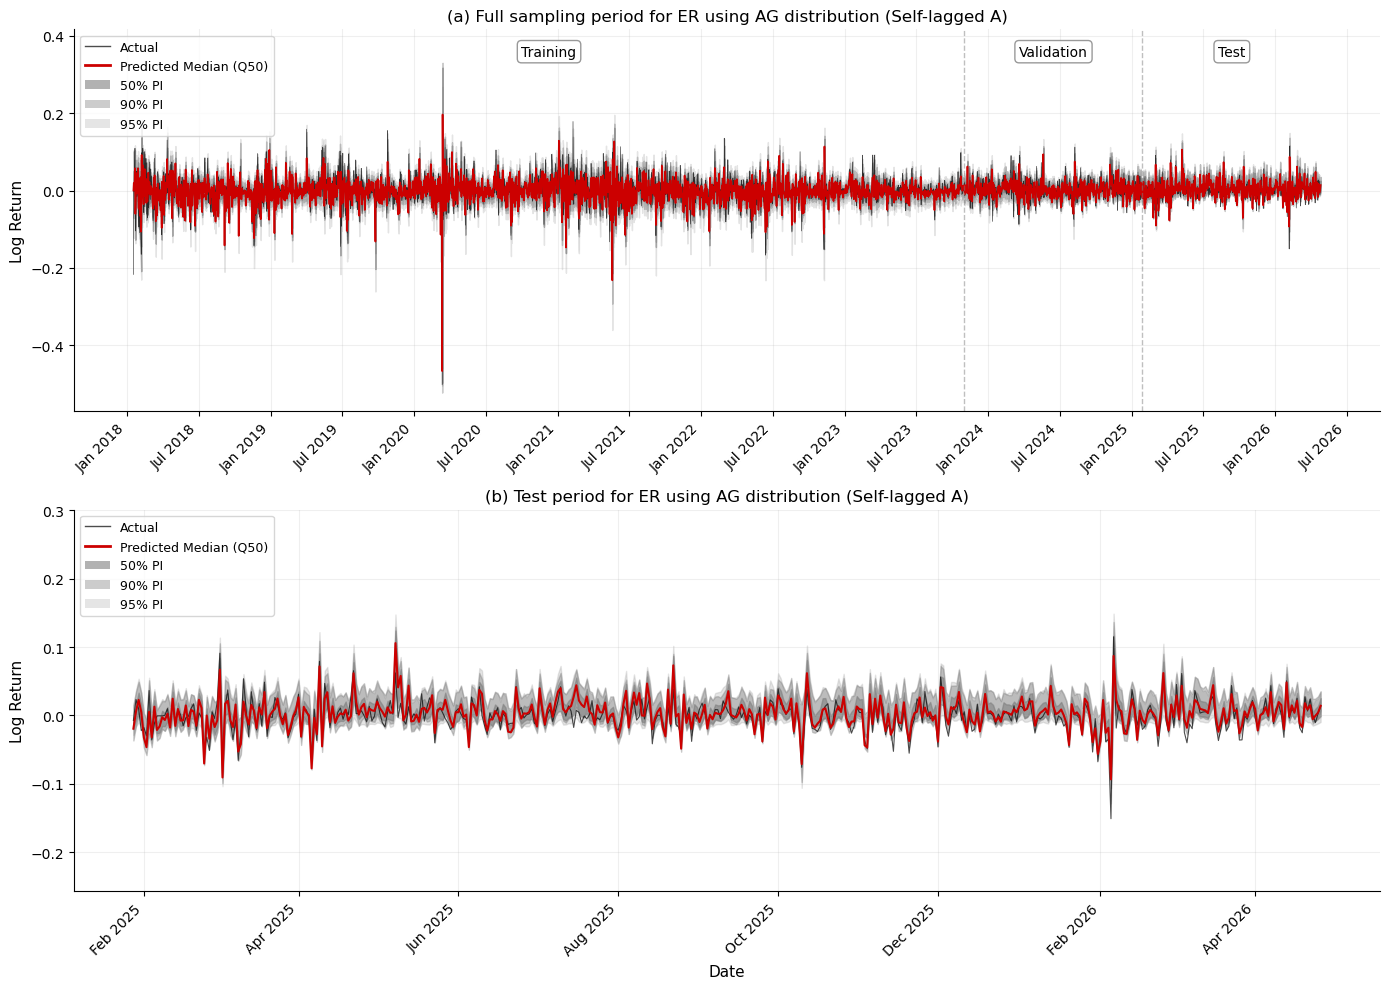

Full period plot saved to hybrid_ernn_self_a_predictions_full.png
Test period plot saved to hybrid_ernn_self_a_predictions_test.png

CROSSOVER ANALYSIS -- ERNN Self A (TEST PERIOD, T=454)
              Pair   Violations    Pct (%)
  ------------------------------------------
  (0.025, 0.050):         156     34.36% <-- TAIL
  (0.050, 0.250):         125     27.53%
  (0.250, 0.500):          53     11.67%
  (0.500, 0.750):           0      0.00%
  (0.750, 0.950):           0      0.00%
  (0.950, 0.975):         212     46.70% <-- TAIL
  ------------------------------------------
  Total violations:         546  (20.04% of all pairs)
  Tail violations:          368  (40.53% of tail pairs)

TEST SET METRICS -- ERNN A Self-lagged
     tau        NLL            ASE
  ----------------------------------
   0.025    -2.2818       0.000032
    0.05    -2.5316       0.000031
    0.25    -2.6572       0.000089
     0.5    -2.7234       0.000084
    0.75    -2.6157       0.000103
    0.95    -2.36

In [15]:
def train_final_model_ernn_a(tau, config, y_train, X_train, y_val, X_val, y_test, X_test):
    torch.manual_seed(2026)
    input_dim = X_train.shape[1]
    model = HybridERNN_A(input_dim, config)

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'],
                                     weight_decay=config['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'],
                                      weight_decay=config['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    patience         = config.get('patience', 30)
    max_epochs       = 200
    best_model_state = None
    train_losses, val_losses = [], []

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        e_hybrid, sigma = model(y_train, X_train)
        loss = hybrid_ernn_loss(y_train, e_hybrid, sigma, tau)

        if torch.isnan(loss) or torch.isinf(loss):
            print(f"  NaN/Inf at epoch {epoch}, stopping")
            break

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config['gradient_clip'])
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            e_val, sigma_val = model(y_val, X_val)
            val_loss = hybrid_ernn_loss(y_val, e_val, sigma_val, tau)

        val_losses.append(val_loss.item())
        scheduler.step(val_loss)

        if (epoch + 1) % 50 == 0:
            print(f"  Epoch {epoch+1}: train={loss.item():.4f}, val={val_loss.item():.4f}")

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    model.eval()
    with torch.no_grad():
        e_test, sigma_test = model(y_test, X_test)
        test_loss = hybrid_ernn_loss(y_test, e_test, sigma_test, tau)

    with torch.no_grad():
        est_gamma1 = torch.sigmoid(model.gamma1_raw).item()
        est_gamma2 = torch.nn.functional.softplus(model.gamma2_raw).item()
        est_gamma3 = torch.nn.functional.softplus(model.gamma3_raw).item()
        est_psi    = torch.sigmoid(model.psi_raw).item()
        est_sigma  = torch.nn.functional.softplus(model.sigma_raw).item()

    print(f"  Test loss: {test_loss.item():.4f} | "
          f"gamma1={est_gamma1:.4f} | gamma2={est_gamma2:.4f} | "
          f"gamma3={est_gamma3:.4f} | psi={est_psi:.4f} | sigma={est_sigma:.4f}")

    history_df = pd.DataFrame({
        'epoch':      range(len(train_losses)),
        'train_loss': train_losses,
        'val_loss':   val_losses
    })
    history_df.to_csv(f'ernn_a_self_history_tau_{tau}.csv', index=False)

    return model, train_losses, val_losses, e_test.numpy()


# -------------------------
# Convert test tensors
# -------------------------
X_test = torch.tensor(test_df[feature_cols].values, dtype=torch.float32)
y_test = torch.tensor(test_df['log_return'].values, dtype=torch.float32)

# -------------------------
# Train all tau levels
# -------------------------
tau_levels           = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
results_ernn_a_self  = {}

for tau in tau_levels:
    print(f"\n{'='*60}")
    print(f"Training final model for tau = {tau} (A self-lagged)")
    print(f"{'='*60}")
    config = best_configs_ernn_a_self[tau]
    model, train_losses, val_losses, e_test_pred = train_final_model_ernn_a(
        tau, config, y_train, X_train, y_val, X_val, y_test, X_test)
    results_ernn_a_self[tau] = {
        'model':        model,
        'train_losses': train_losses,
        'val_losses':   val_losses,
        'e_test':       e_test_pred
    }


# ============================================================
# Plotting
# ============================================================
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


def plot_two_panel(results, train_df, val_df, test_df, tau_levels, feature_cols,
                   title_suffix='ER using AG distribution (Self-lagged A)',
                   save_fname='hybrid_ernn_self_a_predictions.png'):

    actual_color = '#000000'
    pred_color   = '#CC0000'
    pi_color     = '#808080'

    all_preds = {}
    X_all = torch.tensor(df[feature_cols].values, dtype=torch.float32)
    y_all = torch.tensor(df['log_return'].values, dtype=torch.float32)

    for tau in tau_levels:
        model = results[tau]['model']
        model.eval()
        with torch.no_grad():
            e_all, _ = model(y_all, X_all)
            all_preds[tau] = e_all.numpy()

    all_dates  = df.index
    train_size = len(train_df)
    val_size   = len(val_df)
    y_all_np   = df['log_return'].values

    have_95 = (0.025 in all_preds) and (0.975 in all_preds)
    have_90 = (0.05  in all_preds) and (0.95  in all_preds)
    have_50 = (0.25  in all_preds) and (0.75  in all_preds)

    legend_elements = [
        Line2D([0], [0], color=actual_color, lw=1, alpha=0.7, label='Actual'),
        Line2D([0], [0], color=pred_color,   lw=2,             label='Predicted Median (Q50)'),
    ]
    if have_50: legend_elements.append(Patch(facecolor=pi_color, alpha=0.6, label='50% PI'))
    if have_90: legend_elements.append(Patch(facecolor=pi_color, alpha=0.4, label='90% PI'))
    if have_95: legend_elements.append(Patch(facecolor=pi_color, alpha=0.2, label='95% PI'))

    y_min, y_max     = y_all_np.min(), y_all_np.max()
    y_range          = y_max - y_min
    y_label          = y_max + 0.25 * y_range
    test_dates       = test_df.index
    y_test_np        = test_df['log_return'].values
    y_min_t, y_max_t = y_test_np.min(), y_test_np.max()
    y_range_t        = y_max_t - y_min_t

    # ============================================================
    # Combined two-panel figure
    # ============================================================
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    ax = axes[0]
    ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.35 * y_range)
    ax.plot(all_dates, y_all_np, color=actual_color, linewidth=0.5, alpha=0.7)
    ax.plot(all_dates, all_preds[0.5], color=pred_color, linewidth=1.2)
    if have_95:
        ax.fill_between(all_dates, all_preds[0.025], all_preds[0.975], color=pi_color, alpha=0.2)
    if have_90:
        ax.fill_between(all_dates, all_preds[0.05],  all_preds[0.95],  color=pi_color, alpha=0.4)
    if have_50:
        ax.fill_between(all_dates, all_preds[0.25],  all_preds[0.75],  color=pi_color, alpha=0.6)
    ax.axvline(x=train_df.index[-1], color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(x=val_df.index[-1],   color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(train_df.index[len(train_df)//2], y_label, 'Training',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.text(val_df.index[len(val_df)//2], y_label, 'Validation',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.text(test_df.index[len(test_df)//2], y_label, 'Test',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax.set_title(f'(a) Full sampling period for {title_suffix}', fontsize=12)
    ax.set_ylabel('Log Return', fontsize=11)
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax2 = axes[1]
    ax2.set_ylim(y_min_t - 0.4 * y_range_t, y_max_t + 0.7 * y_range_t)
    ax2.plot(test_dates, y_test_np, color=actual_color, linewidth=0.8, alpha=0.7)
    ax2.plot(test_dates, all_preds[0.5][train_size + val_size:], color=pred_color, linewidth=1.5)
    if have_95:
        ax2.fill_between(test_dates,
                         all_preds[0.025][train_size + val_size:],
                         all_preds[0.975][train_size + val_size:], color=pi_color, alpha=0.2)
    if have_90:
        ax2.fill_between(test_dates,
                         all_preds[0.05][train_size + val_size:],
                         all_preds[0.95][train_size + val_size:],  color=pi_color, alpha=0.4)
    if have_50:
        ax2.fill_between(test_dates,
                         all_preds[0.25][train_size + val_size:],
                         all_preds[0.75][train_size + val_size:],  color=pi_color, alpha=0.6)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax2.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax2.set_title(f'(b) Test period for {title_suffix}', fontsize=12)
    ax2.set_xlabel('Date', fontsize=11)
    ax2.set_ylabel('Log Return', fontsize=11)
    ax2.grid(True, alpha=0.2)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(save_fname, dpi=300, bbox_inches='tight')
    print(f"Combined plot saved to {save_fname}")
    plt.show()
    plt.close()

    # ============================================================
    # Panel (a) -- full period separately
    # ============================================================
    fig_a, ax_a = plt.subplots(1, 1, figsize=(14, 5))
    ax_a.set_ylim(y_min - 0.1 * y_range, y_max + 0.35 * y_range)
    ax_a.plot(all_dates, y_all_np, color=actual_color, linewidth=0.5, alpha=0.7)
    ax_a.plot(all_dates, all_preds[0.5], color=pred_color, linewidth=1.2)
    if have_95:
        ax_a.fill_between(all_dates, all_preds[0.025], all_preds[0.975], color=pi_color, alpha=0.2)
    if have_90:
        ax_a.fill_between(all_dates, all_preds[0.05],  all_preds[0.95],  color=pi_color, alpha=0.4)
    if have_50:
        ax_a.fill_between(all_dates, all_preds[0.25],  all_preds[0.75],  color=pi_color, alpha=0.6)
    ax_a.axvline(x=train_df.index[-1], color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax_a.axvline(x=val_df.index[-1],   color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax_a.text(train_df.index[len(train_df)//2], y_label, 'Training',
              ha='center', fontsize=10,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax_a.text(val_df.index[len(val_df)//2], y_label, 'Validation',
              ha='center', fontsize=10,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax_a.text(test_df.index[len(test_df)//2], y_label, 'Test',
              ha='center', fontsize=10,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax_a.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax_a.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax_a.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax_a.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax_a.set_title(f'(a) Full sampling period for {title_suffix}', fontsize=12)
    ax_a.set_ylabel('Log Return', fontsize=11)
    ax_a.grid(True, alpha=0.2)
    ax_a.spines['top'].set_visible(False)
    ax_a.spines['right'].set_visible(False)
    fname_a = save_fname.replace('.png', '_full.png')
    plt.tight_layout()
    plt.savefig(fname_a, dpi=300, bbox_inches='tight')
    print(f"Full period plot saved to {fname_a}")
    plt.close()

    # ============================================================
    # Panel (b) -- test period separately
    # ============================================================
    fig_b, ax_b = plt.subplots(1, 1, figsize=(14, 5))
    ax_b.set_ylim(y_min_t - 0.4 * y_range_t, y_max_t + 0.7 * y_range_t)
    ax_b.plot(test_dates, y_test_np, color=actual_color, linewidth=0.8, alpha=0.7)
    ax_b.plot(test_dates, all_preds[0.5][train_size + val_size:], color=pred_color, linewidth=1.5)
    if have_95:
        ax_b.fill_between(test_dates,
                          all_preds[0.025][train_size + val_size:],
                          all_preds[0.975][train_size + val_size:], color=pi_color, alpha=0.2)
    if have_90:
        ax_b.fill_between(test_dates,
                          all_preds[0.05][train_size + val_size:],
                          all_preds[0.95][train_size + val_size:],  color=pi_color, alpha=0.4)
    if have_50:
        ax_b.fill_between(test_dates,
                          all_preds[0.25][train_size + val_size:],
                          all_preds[0.75][train_size + val_size:],  color=pi_color, alpha=0.6)
    ax_b.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax_b.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax_b.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax_b.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax_b.set_title(f'(b) Test period for {title_suffix}', fontsize=12)
    ax_b.set_xlabel('Date', fontsize=11)
    ax_b.set_ylabel('Log Return', fontsize=11)
    ax_b.grid(True, alpha=0.2)
    ax_b.spines['top'].set_visible(False)
    ax_b.spines['right'].set_visible(False)
    fname_b = save_fname.replace('.png', '_test.png')
    plt.tight_layout()
    plt.savefig(fname_b, dpi=300, bbox_inches='tight')
    print(f"Test period plot saved to {fname_b}")
    plt.close()

    return all_preds, train_size, val_size


# -------------------------
# Run plotting -- A self-lagged
# -------------------------
all_preds_ernn_a_self, train_size, val_size = plot_two_panel(
    results_ernn_a_self, train_df, val_df, test_df, tau_levels, feature_cols,
    title_suffix='ER using AG distribution (Self-lagged A)',
    save_fname='hybrid_ernn_self_a_predictions.png'
)


# ============================================================
# Crossover analysis -- test period, tail focused
# ============================================================
import numpy as np

def compute_crossovers(all_preds, levels, train_size, val_size, model_name='ERNN'):
    preds = {lv: all_preds[lv][train_size + val_size:] for lv in levels}
    T = len(preds[levels[0]])

    adjacent_pairs = [
        (0.025, 0.050),
        (0.050, 0.250),
        (0.250, 0.500),
        (0.500, 0.750),
        (0.750, 0.950),
        (0.950, 0.975),
    ]
    tail_pairs = [(0.025, 0.050), (0.950, 0.975)]

    print(f"\n{'='*60}")
    print(f"CROSSOVER ANALYSIS -- {model_name} (TEST PERIOD, T={T})")
    print(f"{'='*60}")
    print(f"  {'Pair':>16} {'Violations':>12} {'Pct (%)':>10}")
    print(f"  {'-'*42}")

    total_violations = 0
    tail_violations  = 0

    for lo, hi in adjacent_pairs:
        violations = int(np.sum(preds[lo] > preds[hi]))
        pct        = violations / T * 100
        total_violations += violations
        marker = ' <-- TAIL' if (lo, hi) in tail_pairs else ''
        print(f"  ({lo:.3f}, {hi:.3f}):  {violations:>10}  {pct:>8.2f}%{marker}")
        if (lo, hi) in tail_pairs:
            tail_violations += violations

    print(f"  {'-'*42}")
    print(f"  Total violations:  {total_violations:>10}  "
          f"({total_violations / (T * len(adjacent_pairs)) * 100:.2f}% of all pairs)")
    print(f"  Tail violations:   {tail_violations:>10}  "
          f"({tail_violations / (T * 2) * 100:.2f}% of tail pairs)")

    return total_violations, tail_violations


def compute_ase(y_true, e_pred, tau):
    y         = y_true.numpy() if hasattr(y_true, 'numpy') else np.array(y_true)
    e         = e_pred if isinstance(e_pred, np.ndarray) else np.array(e_pred)
    indicator = (y < e).astype(float)
    ase       = np.mean(np.abs(tau - indicator) * (y - e)**2)
    return ase


def compute_test_metrics_ernn(results, tau_levels, y_test, X_test, model_name='ERNN'):
    print(f"\n{'='*60}")
    print(f"TEST SET METRICS -- {model_name}")
    print(f"{'='*60}")
    print(f"  {'tau':>6} {'NLL':>10} {'ASE':>14}")
    print(f"  {'-'*34}")

    nll_list = []
    ase_list = []

    for tau in tau_levels:
        model = results[tau]['model']
        model.eval()

        with torch.no_grad():
            e_test, sigma_test = model(y_test, X_test)
            test_nll = hybrid_ernn_loss(y_test, e_test, sigma_test, tau).item()

        e_test_np = e_test.numpy()
        y_test_np = y_test.numpy()

        ase = compute_ase(y_test_np, e_test_np, tau)

        nll_list.append(test_nll)
        ase_list.append(ase)

        print(f"  {tau:>6} {test_nll:>10.4f} {ase:>14.6f}")

    print(f"  {'-'*34}")
    print(f"  {'Mean':>6} {np.mean(nll_list):>10.4f} {np.mean(ase_list):>14.6f}")
    print(f"\n  --> Average NLL: {np.mean(nll_list):.4f}")
    print(f"  --> Average ASE: {np.mean(ase_list):.6f}")

    return np.mean(nll_list), np.mean(ase_list)


total_viol, tail_viol = compute_crossovers(
    all_preds_ernn_a_self, tau_levels, train_size, val_size,
    model_name='ERNN Self A'
)

avg_nll_ernn_a_self, avg_ase_ernn_a_self = compute_test_metrics_ernn(
    results_ernn_a_self, tau_levels, y_test, X_test,
    model_name='ERNN A Self-lagged'
)

# Cross over dealing

In [18]:
import copy

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from optuna.samplers import TPESampler


# ============================================================
# Joint ERNN A Self-lagged
# One model estimates all seven expectile levels
# ============================================================

tau_levels = [
    0.025, 0.050, 0.250, 0.500,
    0.750, 0.950, 0.975
]


class HybridERNN_A_Self_Joint(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()

        self.n_levels = len(tau_levels)
        self.eps = 1e-6

        # Seven level-specific parameter sets
        self.gamma1_raw = nn.Parameter(
            torch.full((self.n_levels,), 1.386)
        )
        self.gamma2_raw = nn.Parameter(
            torch.full((self.n_levels,), 0.3)
        )
        self.gamma3_raw = nn.Parameter(
            torch.full((self.n_levels,), 0.3)
        )
        self.psi_raw = nn.Parameter(
            torch.zeros(self.n_levels)
        )
        self.sigma_raw = nn.Parameter(
            torch.full((self.n_levels,), 0.5)
        )

        # Shared FNN
        layers = []
        prev_dim = input_dim

        for i in range(config['n_hidden_layers']):
            hidden_dim = config[f'hidden_dim_{i}']

            layers.append(
                nn.Linear(prev_dim, hidden_dim)
            )

            if config['layernorm']:
                layers.append(
                    nn.LayerNorm(hidden_dim)
                )

            layers.append(
                self._get_activation(
                    config['activation']
                )
            )

            if config['dropout'] > 0:
                layers.append(
                    nn.Dropout(config['dropout'])
                )

            prev_dim = hidden_dim

        # Median expectile plus six raw spacings
        layers.append(
            nn.Linear(prev_dim, self.n_levels)
        )

        self.fnn = nn.Sequential(*layers)

        for m in self.fnn.modules():
            if isinstance(m, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(m.weight)
                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(m.weight)

                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())

    def reconstruct_fnn_expectiles(self, raw_fnn):
        median = raw_fnn[:, 0]
        delta = (
            F.softplus(raw_fnn[:, 1:])
            + self.eps
        )

        f4 = median

        f3 = f4 - delta[:, 2]
        f2 = f3 - delta[:, 1]
        f1 = f2 - delta[:, 0]

        f5 = f4 + delta[:, 3]
        f6 = f5 + delta[:, 4]
        f7 = f6 + delta[:, 5]

        return torch.stack(
            [f1, f2, f3, f4, f5, f6, f7],
            dim=1
        )

    def forward(
        self,
        y,
        X,
        initial_care=None,
        initial_y=None
    ):
        gamma1 = torch.sigmoid(
            self.gamma1_raw
        )
        gamma2 = F.softplus(
            self.gamma2_raw
        )
        gamma3 = F.softplus(
            self.gamma3_raw
        )
        psi = torch.sigmoid(
            self.psi_raw
        )
        sigma = (
            F.softplus(self.sigma_raw)
            + self.eps
        )

        raw_fnn = self.fnn(X)

        fnn_expectiles = (
            self.reconstruct_fnn_expectiles(
                raw_fnn
            )
        )

        e_hybrid, e_care = (
            compute_hybrid_location_self_a_joint(
                y=y,
                fnn_expectiles=fnn_expectiles,
                gamma1=gamma1,
                gamma2=gamma2,
                gamma3=gamma3,
                psi=psi,
                initial_care=initial_care,
                initial_y=initial_y
            )
        )

        return (
            e_hybrid,
            sigma,
            e_care,
            fnn_expectiles
        )


def compute_hybrid_location_self_a_joint(
    y,
    fnn_expectiles,
    gamma1,
    gamma2,
    gamma3,
    psi,
    initial_care=None,
    initial_y=None
):
    """
    Self-lagged asymmetric CARE recursion:

    e^S_{k,t}
    = gamma1_k e^S_{k,t-1}
    + gamma2_k y^+_{t-1}
    + gamma3_k y^-_{t-1}

    e^H_{k,t}
    = psi_k e^S_{k,t}
    + (1-psi_k) f_{k,t}
    """
    T = len(y)
    n_levels = fnn_expectiles.shape[1]
    zero_row = y.new_zeros(n_levels)

    e_hybrid_list = []
    e_care_list = []

    has_initial_state = (
        initial_care is not None
        and initial_y is not None
    )

    if (
        (initial_care is None)
        != (initial_y is None)
    ):
        raise ValueError(
            'initial_care and initial_y '
            'must be supplied together.'
        )

    previous_care = (
        initial_care
        if has_initial_state
        else zero_row
    )

    for t in range(T):
        if t == 0 and not has_initial_state:
            e_care_list.append(zero_row)
            e_hybrid_list.append(zero_row)
            continue

        previous_y = (
            initial_y
            if t == 0
            else y[t - 1]
        )

        y_pos = torch.clamp(
            previous_y,
            min=0
        )
        y_neg = torch.clamp(
            -previous_y,
            min=0
        )

        care_t = (
            gamma1 * previous_care
            + gamma2 * y_pos
            + gamma3 * y_neg
        )

        hybrid_t = (
            psi * care_t
            + (1 - psi) * fnn_expectiles[t]
        )

        e_care_list.append(care_t)
        e_hybrid_list.append(hybrid_t)

        # Self-lagged: use previous pure CARE output
        previous_care = care_t

    e_care = torch.stack(
        e_care_list,
        dim=0
    )
    e_hybrid = torch.stack(
        e_hybrid_list,
        dim=0
    )

    return e_hybrid, e_care


# ============================================================
# Joint AGD loss, ASE and crossover
# ============================================================

def hybrid_ernn_joint_loss(
    y,
    e_hybrid,
    sigma,
    levels=tau_levels
):
    """
    Average AGD negative log-likelihood across
    all observations and seven expectile levels.
    """
    tau = torch.tensor(
        levels,
        dtype=e_hybrid.dtype,
        device=e_hybrid.device
    )

    u = y.unsqueeze(1) - e_hybrid
    weight = torch.abs(
        tau.unsqueeze(0)
        - (u < 0).float()
    )
    omega = weight * u.pow(2)

    constant = (
        torch.log(
            torch.sqrt(
                torch.pi / tau
            )
            + torch.sqrt(
                torch.pi / (1 - tau)
            )
        )
        - np.log(2.0)
    )

    nll = (
        torch.log(sigma).unsqueeze(0)
        + constant.unsqueeze(0)
        + omega / sigma.pow(2).unsqueeze(0)
    )

    return nll.mean()


def compute_ase_joint(
    y,
    e_hybrid,
    levels=tau_levels
):
    tau = torch.tensor(
        levels,
        dtype=e_hybrid.dtype,
        device=e_hybrid.device
    )

    u = y.unsqueeze(1) - e_hybrid
    weight = torch.abs(
        tau.unsqueeze(0)
        - (u < 0).float()
    )

    ase_by_level = (
        weight * u.pow(2)
    ).mean(dim=0)

    return (
        ase_by_level,
        ase_by_level.mean()
    )


def compute_crossover_joint(e_hybrid):
    violations = (
        e_hybrid[:, :-1]
        > e_hybrid[:, 1:]
    )

    pair_counts = violations.sum(dim=0)
    T = len(e_hybrid)

    total_count = int(
        pair_counts.sum().item()
    )
    total_rate = total_count / (T * 6)

    tail_count = int(
        pair_counts[0].item()
        + pair_counts[-1].item()
    )
    tail_rate = tail_count / (T * 2)

    return {
        'pair_counts': [
            int(x)
            for x in pair_counts.tolist()
        ],
        'total_count': total_count,
        'total_rate': total_rate,
        'tail_count': tail_count,
        'tail_rate': tail_rate
    }


# ============================================================
# Fit one joint model
# ============================================================

def fit_joint_ernn_self(
    config,
    max_epochs=200,
    seed=2026
):
    torch.manual_seed(seed)

    model = HybridERNN_A_Self_Joint(
        X_train.shape[1],
        config
    )

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config['weight_decay']
        )
    else:
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config['weight_decay']
        )

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            patience=10,
            factor=0.5,
            min_lr=1e-6
        )
    )

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()

        e_train, sigma, _, _ = model(
            y_train,
            X_train
        )

        # t=0 is only the initialisation row
        train_loss = hybrid_ernn_joint_loss(
            y_train[1:],
            e_train[1:],
            sigma
        )

        if (
            torch.isnan(train_loss)
            or torch.isinf(train_loss)
        ):
            return None

        train_loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            config['gradient_clip']
        )

        optimizer.step()

        # Continue validation from training CARE state
        model.eval()
        with torch.no_grad():
            _, sigma_val, care_train, _ = model(
                y_train,
                X_train
            )

            e_val, _, _, _ = model(
                y_val,
                X_val,
                initial_care=care_train[-1],
                initial_y=y_train[-1]
            )

            val_loss = hybrid_ernn_joint_loss(
                y_val,
                e_val,
                sigma_val
            )

        scheduler.step(
            val_loss.item()
        )

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            patience_counter = 0
            best_model_state = copy.deepcopy(
                model.state_dict()
            )
        else:
            patience_counter += 1

            if (
                patience_counter
                >= config['patience']
            ):
                break

    if best_model_state is None:
        return None

    model.load_state_dict(
        best_model_state
    )

    return model


def evaluate_joint_ernn_self(model):
    model.eval()

    with torch.no_grad():
        _, sigma, care_train, _ = model(
            y_train,
            X_train
        )

        e_val, _, _, fnn_val = model(
            y_val,
            X_val,
            initial_care=care_train[-1],
            initial_y=y_train[-1]
        )

        mean_nll = hybrid_ernn_joint_loss(
            y_val,
            e_val,
            sigma
        ).item()

        ase_levels, mean_ase = (
            compute_ase_joint(
                y_val,
                e_val
            )
        )

        final_cross = (
            compute_crossover_joint(e_val)
        )
        fnn_cross = (
            compute_crossover_joint(fnn_val)
        )

        gamma1 = torch.sigmoid(
            model.gamma1_raw
        )
        gamma2 = F.softplus(
            model.gamma2_raw
        )
        gamma3 = F.softplus(
            model.gamma3_raw
        )
        psi = torch.sigmoid(
            model.psi_raw
        )
        sigma = (
            F.softplus(model.sigma_raw)
            + model.eps
        )

    return {
        'mean_nll': mean_nll,
        'ase_by_level': ase_levels.tolist(),
        'mean_ase': mean_ase.item(),
        'final_crossover': final_cross,
        'fnn_crossover': fnn_cross,
        'gamma1': gamma1.tolist(),
        'gamma2': gamma2.tolist(),
        'gamma3': gamma3.tolist(),
        'psi': psi.tolist(),
        'sigma': sigma.tolist()
    }


# ============================================================
# Optuna objective
# ============================================================

def objective_ernn_self_joint(trial):
    config = {
        'n_hidden_layers': trial.suggest_int(
            'n_hidden_layers', 1, 3
        ),
        'activation': trial.suggest_categorical(
            'activation',
            ['relu', 'elu', 'gelu', 'tanh']
        ),
        'dropout': trial.suggest_float(
            'dropout', 0.0, 0.5
        ),
        'layernorm': trial.suggest_categorical(
            'layernorm', [True, False]
        ),
        'weight_init': trial.suggest_categorical(
            'weight_init', ['glorot', 'he']
        ),
        'lr': trial.suggest_float(
            'lr', 1e-4, 5e-2, log=True
        ),
        'optimizer': trial.suggest_categorical(
            'optimizer', ['adam', 'adamw']
        ),
        'weight_decay': trial.suggest_float(
            'weight_decay', 0.0, 1e-4
        ),
        'gradient_clip': trial.suggest_categorical(
            'gradient_clip', [0.1, 1.0, 5.0]
        ),
        'patience': trial.suggest_categorical(
            'patience', [10, 20, 30]
        )
    }

    for i in range(config['n_hidden_layers']):
        config[f'hidden_dim_{i}'] = (
            trial.suggest_int(
                f'hidden_dim_{i}',
                32,
                256
            )
        )

    model = fit_joint_ernn_self(
        config=config,
        max_epochs=200,
        seed=2026
    )

    if model is None:
        return float('inf')

    metrics = evaluate_joint_ernn_self(
        model
    )

    for name in [
        'mean_nll',
        'mean_ase',
        'ase_by_level',
        'gamma1',
        'gamma2',
        'gamma3',
        'psi',
        'sigma'
    ]:
        trial.set_user_attr(
            name,
            metrics[name]
        )

    trial.set_user_attr(
        'final_crossover_count',
        metrics['final_crossover']['total_count']
    )
    trial.set_user_attr(
        'final_crossover_rate',
        metrics['final_crossover']['total_rate']
    )
    trial.set_user_attr(
        'tail_crossover_count',
        metrics['final_crossover']['tail_count']
    )
    trial.set_user_attr(
        'tail_crossover_rate',
        metrics['final_crossover']['tail_rate']
    )
    trial.set_user_attr(
        'pair_crossover_counts',
        metrics['final_crossover']['pair_counts']
    )
    trial.set_user_attr(
        'fnn_crossover_count',
        metrics['fnn_crossover']['total_count']
    )

    print(
        f"Trial {trial.number}: "
        f"NLL={metrics['mean_nll']:.6f} | "
        f"ASE={metrics['mean_ase']:.8f} | "
        f"Final crossover="
        f"{metrics['final_crossover']['total_rate']:.2%} | "
        f"FNN crossover="
        f"{metrics['fnn_crossover']['total_rate']:.2%}"
    )

    # Search is guided by validation NLL.
    # Final selection uses NLL rank + ASE rank.
    return metrics['mean_nll']


# ============================================================
# Rank by validation NLL and ASE
# ============================================================

def select_best_trial_by_rank_joint(study):
    trials = [
        t for t in study.trials
        if (
            t.state
            == optuna.trial.TrialState.COMPLETE
            and t.value is not None
            and np.isfinite(t.value)
            and 'mean_nll' in t.user_attrs
            and 'mean_ase' in t.user_attrs
        )
    ]

    if len(trials) == 0:
        raise RuntimeError(
            'No valid completed trials.'
        )

    for t in trials:
        t._nll = t.user_attrs['mean_nll']
        t._ase = t.user_attrs['mean_ase']

    for rank, t in enumerate(
        sorted(
            trials,
            key=lambda x: x._nll
        ),
        start=1
    ):
        t._rank_nll = rank

    for rank, t in enumerate(
        sorted(
            trials,
            key=lambda x: x._ase
        ),
        start=1
    ):
        t._rank_ase = rank

    best = min(
        trials,
        key=lambda t: (
            t._rank_nll + t._rank_ase,
            t._nll,
            t._ase,
            t.number
        )
    )

    return best, trials


# ============================================================
# Run one 800-trial joint study
# ============================================================

print('\n' + '=' * 70)
print(
    'Tuning Joint ERNN A Self-lagged '
    'for all seven tau levels'
)
print('=' * 70)

sampler = TPESampler(seed=2026)

study_ernn_a_self_joint = (
    optuna.create_study(
        direction='minimize',
        sampler=sampler
    )
)

study_ernn_a_self_joint.optimize(
    objective_ernn_self_joint,
    n_trials=800,
    show_progress_bar=True
)

best_trial_ernn_self, all_trials_ernn_self = (
    select_best_trial_by_rank_joint(
        study_ernn_a_self_joint
    )
)


# ============================================================
# Save trial ranking
# ============================================================

ranking_records = []

for t in all_trials_ernn_self:
    record = {
        'trial': t.number,
        'mean_nll': t._nll,
        'mean_ase': t._ase,
        'rank_nll': t._rank_nll,
        'rank_ase': t._rank_ase,
        'sum_rank': (
            t._rank_nll + t._rank_ase
        ),
        'final_crossover_count':
            t.user_attrs[
                'final_crossover_count'
            ],
        'final_crossover_rate':
            t.user_attrs[
                'final_crossover_rate'
            ],
        'tail_crossover_count':
            t.user_attrs[
                'tail_crossover_count'
            ],
        'tail_crossover_rate':
            t.user_attrs[
                'tail_crossover_rate'
            ],
        'fnn_crossover_count':
            t.user_attrs[
                'fnn_crossover_count'
            ]
    }

    for k, tau in enumerate(tau_levels):
        suffix = f'tau_{tau}'

        record[f'ase_{suffix}'] = (
            t.user_attrs['ase_by_level'][k]
        )
        record[f'gamma1_{suffix}'] = (
            t.user_attrs['gamma1'][k]
        )
        record[f'gamma2_{suffix}'] = (
            t.user_attrs['gamma2'][k]
        )
        record[f'gamma3_{suffix}'] = (
            t.user_attrs['gamma3'][k]
        )
        record[f'psi_{suffix}'] = (
            t.user_attrs['psi'][k]
        )
        record[f'sigma_{suffix}'] = (
            t.user_attrs['sigma'][k]
        )

    record.update(t.params)
    ranking_records.append(record)


ranking_df_ernn_self = pd.DataFrame(
    ranking_records
)

ranking_df_ernn_self = (
    ranking_df_ernn_self.sort_values(
        ['sum_rank', 'mean_nll', 'mean_ase']
    )
)

ranking_df_ernn_self.to_csv(
    'joint_ernn_a_self_ranking.csv',
    index=False
)


# ============================================================
# Refit and save selected model
# ============================================================

best_config_ernn_self = (
    best_trial_ernn_self.params.copy()
)

best_model_ernn_self_joint = (
    fit_joint_ernn_self(
        config=best_config_ernn_self,
        max_epochs=200,
        seed=2026
    )
)

best_metrics_ernn_self_joint = (
    evaluate_joint_ernn_self(
        best_model_ernn_self_joint
    )
)

torch.save(
    {
        'model_state_dict':
            best_model_ernn_self_joint.state_dict(),
        'config':
            best_config_ernn_self,
        'tau_levels':
            tau_levels,
        'validation_metrics':
            best_metrics_ernn_self_joint
    },
    'joint_ernn_a_self_best.pt'
)


# ============================================================
# Final validation summary
# ============================================================

print('\n' + '=' * 70)
print('TUNING COMPLETE -- JOINT ERNN A SELF-LAGGED')
print('=' * 70)
print(
    f'Best trial: {best_trial_ernn_self.number}'
)
print(
    f"Validation NLL: "
    f"{best_metrics_ernn_self_joint['mean_nll']:.6f}"
)
print(
    f"Validation ASE: "
    f"{best_metrics_ernn_self_joint['mean_ase']:.8f}"
)
print(
    f"Final hybrid crossover: "
    f"{best_metrics_ernn_self_joint['final_crossover']['total_count']} "
    f"("
    f"{best_metrics_ernn_self_joint['final_crossover']['total_rate']:.2%}"
    f")"
)
print(
    f"Tail crossover: "
    f"{best_metrics_ernn_self_joint['final_crossover']['tail_count']} "
    f"("
    f"{best_metrics_ernn_self_joint['final_crossover']['tail_rate']:.2%}"
    f")"
)
print(
    f"FNN crossover count: "
    f"{best_metrics_ernn_self_joint['fnn_crossover']['total_count']}"
)
print(
    f'Best architecture: {best_config_ernn_self}'
)

[I 2026-07-27 13:00:36,090] A new study created in memory with name: no-name-bb3752d5-33a0-45a3-9aa2-67efbd7cbe31



Tuning Joint ERNN A Self-lagged for all seven tau levels


  0%|          | 0/800 [00:00<?, ?it/s]

Trial 0: NLL=1.301408 | ASE=0.00231033 | Final crossover=0.00% | FNN crossover=0.00%
[I 2026-07-27 13:01:01,465] Trial 0 finished with value: 1.3014076948165894 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 1.3014076948165894.
Trial 1: NLL=0.266137 | ASE=0.00014292 | Final crossover=0.18% | FNN crossover=0.00%
[I 2026-07-27 13:01:26,979] Trial 1 finished with value: 0.26613664627075195 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: 0.26613664627075195.
Trial 2: NLL=1.38

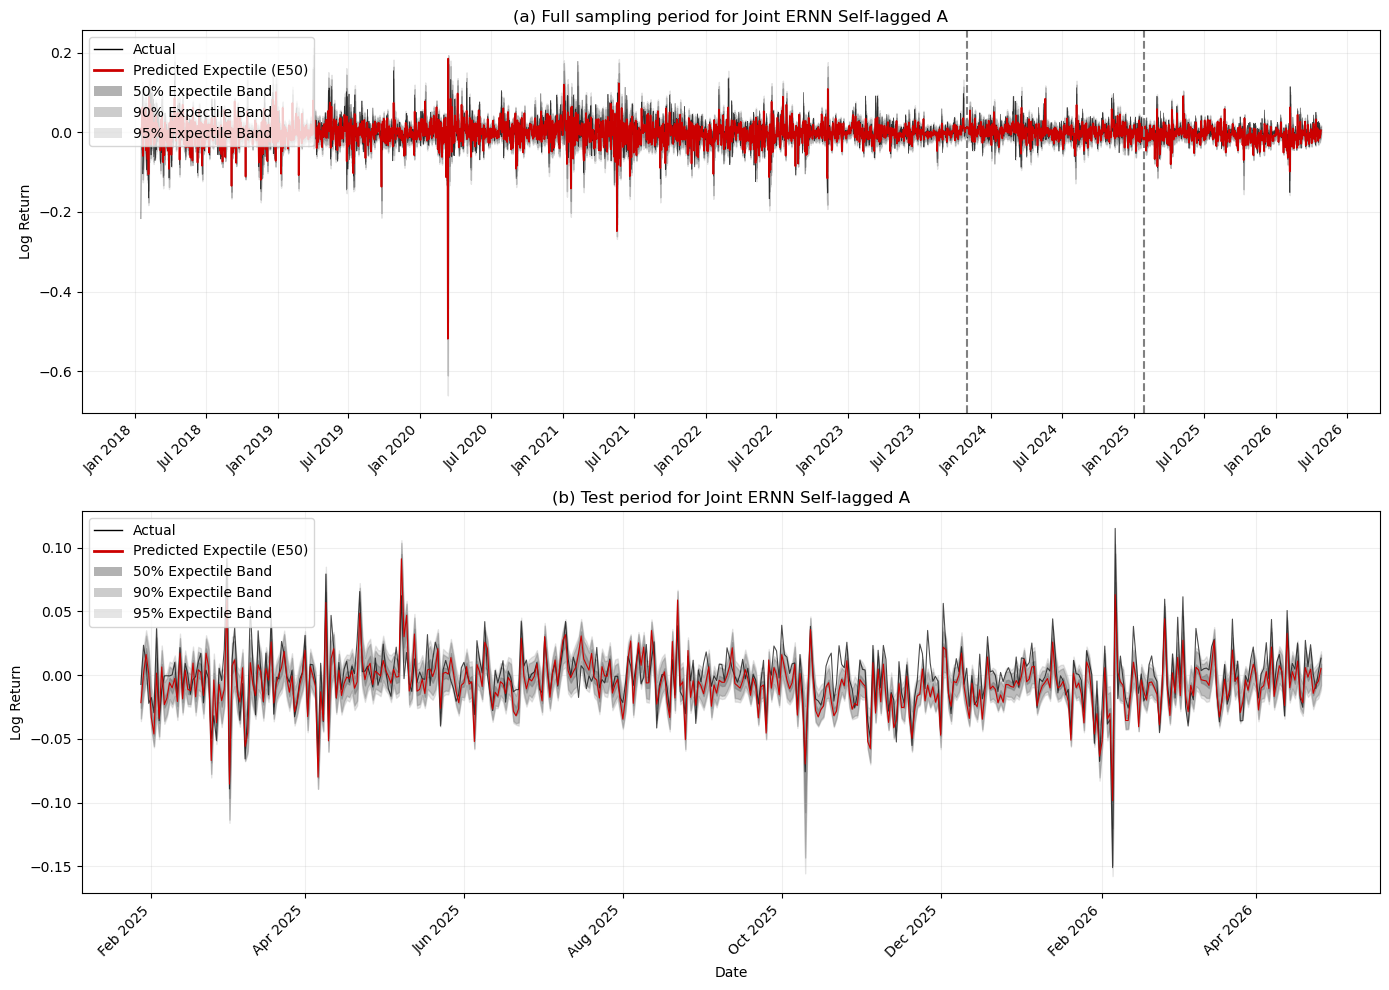

Plot saved to hybrid_ernn_self_a_joint_predictions.png

TEST METRICS -- JOINT ERNN A SELF-LAGGED
       tau         NLL        ASE
0.02500000 -2.63316059 0.00001733
0.05000000 -2.67271829 0.00002871
0.25000000 -2.74590993 0.00007299
0.50000000 -2.71201539 0.00010250
0.75000000 -2.69514847 0.00009327
0.95000000 -2.61782074 0.00003534
0.97500000 -2.56123304 0.00002257

Average NLL: -2.662572
Average ASE: 0.00005324

CROSSOVER ANALYSIS -- FINAL HYBRID OUTPUT
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 50 (11.01%)
(0.500, 0.750): 9 (1.98%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 0 (0.00%) <-- TAIL

Total violations: 59 (2.17%)
Tail violations: 0 (0.00%)

CROSSOVER ANALYSIS -- MONOTONIC FNN OUTPUT
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 0 (0.00%)
(0.500, 0.750): 0 (0.00%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 0 (0.00%) <-- TAIL

Total violations: 0 (0.00%)
Tail violations: 0 (0.00%)


In [20]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.patches import Patch
from matplotlib.lines import Line2D


# ============================================================
# Joint ERNN A Self-lagged -- plotting and test evaluation
# Run directly after the ERNN self-lagged tuning code
# ============================================================

X_test_e = torch.tensor(
    test_df[feature_cols].values,
    dtype=torch.float32
)
y_test_e = torch.tensor(
    test_df['log_return'].values,
    dtype=torch.float32
)

model = best_model_ernn_self_joint
model.eval()


# -------------------------
# Sequential predictions
# -------------------------
with torch.no_grad():
    e_train, sigma, care_train, fnn_train = model(
        y_train,
        X_train
    )

    e_val, _, care_val, fnn_val = model(
        y_val,
        X_val,
        initial_care=care_train[-1],
        initial_y=y_train[-1]
    )

    e_test, _, _, fnn_test = model(
        y_test_e,
        X_test_e,
        initial_care=care_val[-1],
        initial_y=y_val[-1]
    )

e_train_np = e_train.numpy()
e_val_np   = e_val.numpy()
e_test_np  = e_test.numpy()

e_all = np.concatenate(
    [e_train_np, e_val_np, e_test_np],
    axis=0
)

y_all = np.concatenate([
    train_df['log_return'].values,
    val_df['log_return'].values,
    test_df['log_return'].values
])

all_dates = (
    train_df.index
    .append(val_df.index)
    .append(test_df.index)
)

all_preds_ernn_a_self = {
    tau: e_all[:, k]
    for k, tau in enumerate(tau_levels)
}


# ============================================================
# Plotting
# ============================================================
def plot_two_panel_ernn_joint(
    all_preds,
    train_df,
    val_df,
    test_df,
    save_fname='hybrid_ernn_self_a_joint_predictions.png'
):
    actual_color = '#000000'
    pred_color   = '#CC0000'
    pi_color     = '#808080'

    train_size = len(train_df)
    val_size   = len(val_df)
    test_start = train_size + val_size

    test_dates = test_df.index
    y_test_np  = test_df['log_return'].values

    legend_elements = [
        Line2D(
            [0], [0],
            color=actual_color,
            lw=1,
            label='Actual'
        ),
        Line2D(
            [0], [0],
            color=pred_color,
            lw=2,
            label='Predicted Expectile (E50)'
        ),
        Patch(
            facecolor=pi_color,
            alpha=0.6,
            label='50% Expectile Band'
        ),
        Patch(
            facecolor=pi_color,
            alpha=0.4,
            label='90% Expectile Band'
        ),
        Patch(
            facecolor=pi_color,
            alpha=0.2,
            label='95% Expectile Band'
        )
    ]

    fig, axes = plt.subplots(
        2, 1, figsize=(14, 10)
    )

    # -------------------------
    # Full sample
    # -------------------------
    ax = axes[0]

    ax.plot(
        all_dates,
        y_all,
        color=actual_color,
        linewidth=0.5,
        alpha=0.7
    )
    ax.plot(
        all_dates,
        all_preds[0.500],
        color=pred_color,
        linewidth=1.2
    )
    ax.fill_between(
        all_dates,
        all_preds[0.025],
        all_preds[0.975],
        color=pi_color,
        alpha=0.2
    )
    ax.fill_between(
        all_dates,
        all_preds[0.050],
        all_preds[0.950],
        color=pi_color,
        alpha=0.4
    )
    ax.fill_between(
        all_dates,
        all_preds[0.250],
        all_preds[0.750],
        color=pi_color,
        alpha=0.6
    )

    ax.axvline(
        train_df.index[-1],
        color='gray',
        linestyle='--'
    )
    ax.axvline(
        val_df.index[-1],
        color='gray',
        linestyle='--'
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter('%b %Y')
    )
    ax.xaxis.set_major_locator(
        mdates.MonthLocator(interval=6)
    )
    plt.setp(
        ax.xaxis.get_majorticklabels(),
        rotation=45,
        ha='right'
    )

    ax.set_title(
        '(a) Full sampling period for '
        'Joint ERNN Self-lagged A'
    )
    ax.set_ylabel('Log Return')
    ax.legend(
        handles=legend_elements,
        loc='upper left'
    )
    ax.grid(True, alpha=0.2)

    # -------------------------
    # Test sample
    # -------------------------
    ax2 = axes[1]

    ax2.plot(
        test_dates,
        y_test_np,
        color=actual_color,
        linewidth=0.8,
        alpha=0.7
    )
    ax2.plot(
        test_dates,
        all_preds[0.500][test_start:],
        color=pred_color,
        linewidth=0.8
    )
    ax2.fill_between(
        test_dates,
        all_preds[0.025][test_start:],
        all_preds[0.975][test_start:],
        color=pi_color,
        alpha=0.2
    )
    ax2.fill_between(
        test_dates,
        all_preds[0.050][test_start:],
        all_preds[0.950][test_start:],
        color=pi_color,
        alpha=0.4
    )
    ax2.fill_between(
        test_dates,
        all_preds[0.250][test_start:],
        all_preds[0.750][test_start:],
        color=pi_color,
        alpha=0.6
    )

    ax2.xaxis.set_major_formatter(
        mdates.DateFormatter('%b %Y')
    )
    ax2.xaxis.set_major_locator(
        mdates.MonthLocator(interval=2)
    )
    plt.setp(
        ax2.xaxis.get_majorticklabels(),
        rotation=45,
        ha='right'
    )

    ax2.set_title(
        '(b) Test period for '
        'Joint ERNN Self-lagged A'
    )
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Log Return')
    ax2.legend(
        handles=legend_elements,
        loc='upper left'
    )
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig(
        save_fname,
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

    print(f'Plot saved to {save_fname}')


plot_two_panel_ernn_joint(
    all_preds_ernn_a_self,
    train_df,
    val_df,
    test_df
)


# ============================================================
# Test NLL and ASE
# ============================================================
def compute_test_metrics_joint(
    y_test,
    e_test,
    sigma,
    tau_levels
):
    records = []

    for k, tau in enumerate(tau_levels):
        y = y_test
        e = e_test[:, k]
        sigma_k = sigma[k]

        u = y - e
        weight = torch.abs(
            torch.tensor(tau)
            - (u < 0).float()
        )
        omega = weight * u.pow(2)

        constant = (
            np.log(
                np.sqrt(np.pi / tau)
                + np.sqrt(np.pi / (1 - tau))
            )
            - np.log(2.0)
        )

        nll = (
            torch.log(sigma_k)
            + constant
            + omega / sigma_k.pow(2)
        ).mean().item()

        ase = omega.mean().item()

        records.append({
            'tau': tau,
            'NLL': nll,
            'ASE': ase
        })

    results = pd.DataFrame(records)

    print('\n' + '=' * 60)
    print('TEST METRICS -- JOINT ERNN A SELF-LAGGED')
    print('=' * 60)
    print(
        results.to_string(
            index=False,
            float_format=lambda x: f'{x:.8f}'
        )
    )
    print(f"\nAverage NLL: {results['NLL'].mean():.6f}")
    print(f"Average ASE: {results['ASE'].mean():.8f}")

    results.to_csv(
        'joint_ernn_a_self_test_metrics.csv',
        index=False
    )

    return results


test_metrics_ernn_a_self = compute_test_metrics_joint(
    y_test_e,
    e_test,
    sigma,
    tau_levels
)


# ============================================================
# Test crossover analysis
# ============================================================
def compute_crossovers_joint(
    e_pred,
    levels,
    model_name
):
    e = e_pred.numpy()
    T = len(e)

    total_violations = 0
    tail_violations  = 0

    print('\n' + '=' * 60)
    print(f'CROSSOVER ANALYSIS -- {model_name}')
    print('=' * 60)

    for k in range(len(levels) - 1):
        lo = levels[k]
        hi = levels[k + 1]

        violations = int(
            np.sum(e[:, k] > e[:, k + 1])
        )
        percentage = violations / T * 100

        total_violations += violations

        if k == 0 or k == len(levels) - 2:
            tail_violations += violations
            marker = ' <-- TAIL'
        else:
            marker = ''

        print(
            f'({lo:.3f}, {hi:.3f}): '
            f'{violations} ({percentage:.2f}%){marker}'
        )

    total_rate = (
        total_violations /
        (T * (len(levels) - 1))
    )
    tail_rate = tail_violations / (T * 2)

    print(
        f'\nTotal violations: {total_violations} '
        f'({total_rate:.2%})'
    )
    print(
        f'Tail violations: {tail_violations} '
        f'({tail_rate:.2%})'
    )

    return total_violations, tail_violations


# Final hybrid forecasts: crossing may remain
final_crossovers = compute_crossovers_joint(
    e_test,
    tau_levels,
    'FINAL HYBRID OUTPUT'
)

# FNN forecasts: crossing should be zero
fnn_crossovers = compute_crossovers_joint(
    fnn_test,
    tau_levels,
    'MONOTONIC FNN OUTPUT'
)

# Cross over dealing 1b


In [12]:
import copy

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from optuna.samplers import TPESampler


# ============================================================
# METHOD 1B -- JOINT ERNN A SELF-LAGGED
#
# One joint model estimates:
#   1. one central (median) Hybrid ERNN forecast; and
#   2. six positive, time-varying adjacent spacings.
#
# Unlike Method 1a, the constraint is imposed on the COMPLETE
# final forecasts, not only on the unrestricted FNN component.
# ============================================================

tau_levels = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
median_index = tau_levels.index(0.500)


class HybridERNN_A_Joint_Method1B(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()

        self.n_levels = len(tau_levels)
        self.eps = 1e-6

        # Only the median has an independently identifiable hybrid
        # statistical-neural decomposition. For every non-median level,
        # Method 1b directly estimates a positive adjacent spacing.
        self.gamma1_raw = nn.Parameter(torch.tensor(1.386))
        self.gamma2_raw = nn.Parameter(torch.tensor(0.3))
        self.gamma3_raw = nn.Parameter(torch.tensor(0.3))
        self.psi_raw = nn.Parameter(torch.tensor(0.0))

        # One AGD scale for each of the seven final expectiles.
        self.sigma_raw = nn.Parameter(
            torch.full((self.n_levels,), 0.5)
        )

        layers = []
        previous_dim = input_dim

        for i in range(config['n_hidden_layers']):
            hidden_dim = config[f'hidden_dim_{i}']
            layers.append(nn.Linear(previous_dim, hidden_dim))

            if config['layernorm']:
                layers.append(nn.LayerNorm(hidden_dim))

            layers.append(self._get_activation(config['activation']))

            if config['dropout'] > 0:
                layers.append(nn.Dropout(config['dropout']))

            previous_dim = hidden_dim

        self.feature_extractor = nn.Sequential(*layers)

        # The median head uses the common features. As in Method 3,
        # every spacing head also receives its adjacent reference forecast.
        self.median_head = nn.Linear(previous_dim, 1)
        self.spacing_heads = nn.ModuleDict({
            name: nn.Linear(previous_dim + 1, 1)
            for name in [
                'delta12', 'delta23', 'delta34',
                'delta45', 'delta56', 'delta67'
            ]
        })

        for module in self.modules():
            if isinstance(module, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(module.weight)
                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(module.weight)

                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    @staticmethod
    def _get_activation(name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())

    def positive_spacing(self, features, reference, name):
        """Method 3 gap head: delta=softplus(g(X, reference))>0."""
        head_input = torch.cat(
            [features, reference.unsqueeze(1)],
            dim=1
        )
        raw_delta = self.spacing_heads[name](head_input).squeeze(1)
        return F.softplus(raw_delta) + self.eps

    def forward(
        self,
        y,
        X,
        initial_care=None,
        initial_y=None
    ):
        gamma1 = torch.sigmoid(self.gamma1_raw)
        gamma2 = F.softplus(self.gamma2_raw)
        gamma3 = F.softplus(self.gamma3_raw)
        psi = torch.sigmoid(self.psi_raw)
        sigma = F.softplus(self.sigma_raw) + self.eps

        features = self.feature_extractor(X)
        median_fnn = self.median_head(features).squeeze(1)

        q50, q50_care = compute_median_hybrid_location_self_a(
            y=y,
            median_fnn=median_fnn,
            gamma1=gamma1,
            gamma2=gamma2,
            gamma3=gamma3,
            psi=psi,
            initial_care=initial_care,
            initial_y=initial_y
        )

        # Reconstruct outwards exactly as in Method 3. Unlike the
        # sequential Method 3 fits, references are NOT detached here.
        # Consequently, the complete seven-level objective is joint.
        delta34 = self.positive_spacing(
            features, q50, 'delta34'
        )
        q3 = q50 - delta34

        delta23 = self.positive_spacing(
            features, q3, 'delta23'
        )
        q2 = q3 - delta23

        delta12 = self.positive_spacing(
            features, q2, 'delta12'
        )
        q1 = q2 - delta12

        delta45 = self.positive_spacing(
            features, q50, 'delta45'
        )
        q5 = q50 + delta45

        delta56 = self.positive_spacing(
            features, q5, 'delta56'
        )
        q6 = q5 + delta56

        delta67 = self.positive_spacing(
            features, q6, 'delta67'
        )
        q7 = q6 + delta67

        q_final = torch.stack(
            [q1, q2, q3, q50, q5, q6, q7],
            dim=1
        )
        delta = torch.stack(
            [
                delta12, delta23, delta34,
                delta45, delta56, delta67
            ],
            dim=1
        )

        return q_final, sigma, q50_care, q50, delta


def compute_median_hybrid_location_self_a(
    y,
    median_fnn,
    gamma1,
    gamma2,
    gamma3,
    psi,
    initial_care=None,
    initial_y=None
):
    """Self-lagged asymmetric CARE-Hybrid recursion for tau=0.50."""
    if (initial_care is None) != (initial_y is None):
        raise ValueError(
            'initial_care and initial_y must be supplied together.'
        )

    has_initial_state = (
        initial_care is not None and initial_y is not None
    )

    previous_care = (
        initial_care
        if has_initial_state
        else y.new_zeros(())
    )

    care_values = []
    hybrid_values = []

    for t in range(len(y)):
        # The first training row has no lagged state and is excluded
        # from the training loss.
        if t == 0 and not has_initial_state:
            zero = y.new_zeros(())
            care_values.append(zero)
            hybrid_values.append(zero)
            continue

        previous_y = initial_y if t == 0 else y[t - 1]
        y_positive = torch.clamp(previous_y, min=0)
        y_negative = torch.clamp(-previous_y, min=0)

        care_t = (
            gamma1 * previous_care
            + gamma2 * y_positive
            + gamma3 * y_negative
        )

        hybrid_t = (
            psi * care_t
            + (1 - psi) * median_fnn[t]
        )

        care_values.append(care_t)
        hybrid_values.append(hybrid_t)
        previous_care = care_t

    return (
        torch.stack(hybrid_values),
        torch.stack(care_values)
    )


# ============================================================
# Joint AGD NLL and diagnostics
# ============================================================

def hybrid_ernn_joint_loss(
    y,
    q_final,
    sigma,
    tau_values=tau_levels
):
    """Average AGD NLL over observations and all seven levels."""
    tau = q_final.new_tensor(tau_values)
    residual = y.unsqueeze(1) - q_final
    weight = torch.abs(
        tau.unsqueeze(0)
        - (residual < 0).to(q_final.dtype)
    )
    weighted_squared_error = weight * residual.square()
    constant = (
        torch.log(
            torch.sqrt(torch.pi / tau)
            + torch.sqrt(torch.pi / (1 - tau))
        )
        - np.log(2.0)
    )

    nll = (
        torch.log(sigma).unsqueeze(0)
        + constant.unsqueeze(0)
        + weighted_squared_error / sigma.square().unsqueeze(0)
    )

    return nll.mean()


def compute_ase_joint(
    y,
    q_final,
    tau_values=tau_levels
):
    tau = q_final.new_tensor(tau_values)
    residual = y.unsqueeze(1) - q_final
    weight = torch.abs(
        tau.unsqueeze(0)
        - (residual < 0).to(q_final.dtype)
    )
    ase_by_level = (weight * residual.square()).mean(dim=0)
    return ase_by_level, ase_by_level.mean()


def compute_crossover_joint(q_final):
    violations = q_final[:, :-1] > q_final[:, 1:]
    pair_counts = violations.sum(dim=0)
    sample_size = q_final.shape[0]

    total_count = int(pair_counts.sum().item())
    tail_count = int(
        pair_counts[0].item() + pair_counts[-1].item()
    )

    return {
        'pair_counts': [int(value) for value in pair_counts.tolist()],
        'total_count': total_count,
        'total_rate': total_count / (sample_size * 6),
        'tail_count': tail_count,
        'tail_rate': tail_count / (sample_size * 2)
    }


def compute_spacing_diagnostics(delta):
    """Diagnostics for delta12,...,delta67."""
    return {
        'mean': delta.mean(dim=0).tolist(),
        'minimum': delta.min(dim=0).values.tolist(),
        'maximum': delta.max(dim=0).values.tolist(),
        'std': delta.std(dim=0, unbiased=False).tolist(),
        'near_zero_count': (
            delta <= 1e-5
        ).sum(dim=0).tolist()
    }


# ============================================================
# Model fitting inside each Optuna trial
# ============================================================

def fit_joint_ernn_model(config, max_epochs=800, seed=2026):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = HybridERNN_A_Joint_Method1B(
        input_dim=X_train.shape[1],
        config=config
    )

    optimizer_class = (
        torch.optim.Adam
        if config['optimizer'] == 'adam'
        else torch.optim.AdamW
    )
    optimizer = optimizer_class(
        model.parameters(),
        lr=config['lr'],
        weight_decay=config['weight_decay']
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=10,
        factor=0.5,
        min_lr=1e-6
    )

    best_validation_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for _ in range(max_epochs):
        model.train()
        optimizer.zero_grad()

        q_train, sigma_train, _, _, _ = model(y_train, X_train)

        # The t=0 training forecast is an initialisation row.
        train_loss = hybrid_ernn_joint_loss(
            y_train[1:],
            q_train[1:],
            sigma_train
        )

        if not torch.isfinite(train_loss):
            return None

        train_loss.backward()
        nn.utils.clip_grad_norm_(
            model.parameters(),
            config['gradient_clip']
        )
        optimizer.step()

        model.eval()
        with torch.no_grad():
            _, _, final_train_care, _, _ = model(
                y_train,
                X_train
            )

            q_validation, sigma_validation, _, _, _ = model(
                y_val,
                X_val,
                initial_care=final_train_care[-1],
                initial_y=y_train[-1]
            )

            validation_loss = hybrid_ernn_joint_loss(
                y_val,
                q_validation,
                sigma_validation
            )

        if not torch.isfinite(validation_loss):
            return None

        scheduler.step(validation_loss.item())

        if validation_loss.item() < best_validation_loss:
            best_validation_loss = validation_loss.item()
            patience_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                break

    if best_model_state is None:
        return None

    model.load_state_dict(best_model_state)
    return model


def evaluate_joint_ernn_model(model):
    model.eval()

    with torch.no_grad():
        _, _, final_train_care, _, _ = model(y_train, X_train)

        q_validation, sigma, _, _, delta = model(
            y_val,
            X_val,
            initial_care=final_train_care[-1],
            initial_y=y_train[-1]
        )

        mean_nll = hybrid_ernn_joint_loss(
            y_val,
            q_validation,
            sigma
        ).item()

        ase_by_level, mean_ase = compute_ase_joint(
            y_val,
            q_validation
        )

        crossover = compute_crossover_joint(q_validation)
        spacing = compute_spacing_diagnostics(delta)

        gamma1 = torch.sigmoid(model.gamma1_raw).item()
        gamma2 = F.softplus(model.gamma2_raw).item()
        gamma3 = F.softplus(model.gamma3_raw).item()
        psi = torch.sigmoid(model.psi_raw).item()
        sigma_values = (
            F.softplus(model.sigma_raw) + model.eps
        ).tolist()

    return {
        'mean_nll': mean_nll,
        'ase_by_level': ase_by_level.tolist(),
        'mean_ase': mean_ase.item(),
        'final_crossover': crossover,
        'spacing': spacing,
        'median_gamma1': gamma1,
        'median_gamma2': gamma2,
        'median_gamma3': gamma3,
        'median_psi': psi,
        'sigma': sigma_values
    }


# ============================================================
# Optuna objective
# ============================================================

def objective_ernn_joint_method1b(trial):
    config = {
        'n_hidden_layers': trial.suggest_int(
            'n_hidden_layers', 1, 3
        ),
        'activation': trial.suggest_categorical(
            'activation', ['relu', 'elu', 'gelu', 'tanh']
        ),
        'dropout': trial.suggest_float('dropout', 0.0, 0.5),
        'layernorm': trial.suggest_categorical(
            'layernorm', [True, False]
        ),
        'weight_init': trial.suggest_categorical(
            'weight_init', ['glorot', 'he']
        ),
        'lr': trial.suggest_float('lr', 1e-4, 5e-2, log=True),
        'optimizer': trial.suggest_categorical(
            'optimizer', ['adam', 'adamw']
        ),
        'weight_decay': trial.suggest_float(
            'weight_decay', 0.0, 1e-4
        ),
        'gradient_clip': trial.suggest_categorical(
            'gradient_clip', [0.1, 1.0, 5.0]
        ),
        'patience': trial.suggest_categorical(
            'patience', [10, 20, 30]
        )
    }

    for i in range(config['n_hidden_layers']):
        config[f'hidden_dim_{i}'] = trial.suggest_int(
            f'hidden_dim_{i}', 32, 256
        )

    model = fit_joint_ernn_model(
        config=config,
        max_epochs=800,
        seed=2026
    )

    if model is None:
        return float('inf')

    metrics = evaluate_joint_ernn_model(model)

    for name in [
        'mean_nll',
        'mean_ase',
        'ase_by_level',
        'spacing',
        'sigma',
        'median_gamma1',
        'median_gamma2',
        'median_gamma3',
        'median_psi'
    ]:
        trial.set_user_attr(name, metrics[name])

    trial.set_user_attr(
        'final_crossover_count',
        metrics['final_crossover']['total_count']
    )
    trial.set_user_attr(
        'final_crossover_rate',
        metrics['final_crossover']['total_rate']
    )
    trial.set_user_attr(
        'tail_crossover_count',
        metrics['final_crossover']['tail_count']
    )
    trial.set_user_attr(
        'tail_crossover_rate',
        metrics['final_crossover']['tail_rate']
    )
    trial.set_user_attr(
        'pair_crossover_counts',
        metrics['final_crossover']['pair_counts']
    )

    print(
        f"Trial {trial.number}: "
        f"Mean NLL={metrics['mean_nll']:.6f} | "
        f"Mean ASE={metrics['mean_ase']:.6f} | "
        f"Final crossover="
        f"{metrics['final_crossover']['total_rate']:.2%}"
    )

    # Optuna requires one scalar. The final selection below uses
    # the sum of validation NLL rank and validation ASE rank.
    return metrics['mean_nll']


def select_best_trial_by_rank_joint(study):
    trials = [
        trial for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
        and trial.value is not None
        and np.isfinite(trial.value)
        and 'mean_nll' in trial.user_attrs
        and 'mean_ase' in trial.user_attrs
    ]

    if not trials:
        raise RuntimeError('No valid completed Optuna trials.')

    nll_order = sorted(
        trials,
        key=lambda trial: (
            trial.user_attrs['mean_nll'],
            trial.number
        )
    )
    ase_order = sorted(
        trials,
        key=lambda trial: (
            trial.user_attrs['mean_ase'],
            trial.number
        )
    )

    rank_nll = {
        trial.number: rank
        for rank, trial in enumerate(nll_order, start=1)
    }
    rank_ase = {
        trial.number: rank
        for rank, trial in enumerate(ase_order, start=1)
    }

    best = min(
        trials,
        key=lambda trial: (
            rank_nll[trial.number] + rank_ase[trial.number],
            trial.user_attrs['mean_nll'],
            trial.user_attrs['mean_ase'],
            trial.number
        )
    )

    return best, trials, rank_nll, rank_ase


# ============================================================
# Run the joint study
# ============================================================

base_seed = 2026

print('\n' + '=' * 70)
print('Tuning Method 1b Joint ERNN A Self-lagged')
print('=' * 70)

sampler = TPESampler(seed=base_seed)
study = optuna.create_study(
    direction='minimize',
    sampler=sampler
)

study.optimize(
    objective_ernn_joint_method1b,
    n_trials=800,
    show_progress_bar=True
)

best_trial, all_trials, rank_nll, rank_ase = (
    select_best_trial_by_rank_joint(study)
)


# ============================================================
# Save full trial ranking
# ============================================================

spacing_names = [
    'delta12', 'delta23', 'delta34',
    'delta45', 'delta56', 'delta67'
]
ranking_records = []

for trial in all_trials:
    record = {
        'trial': trial.number,
        'mean_nll': trial.user_attrs['mean_nll'],
        'mean_ase': trial.user_attrs['mean_ase'],
        'rank_nll': rank_nll[trial.number],
        'rank_ase': rank_ase[trial.number],
        'sum_rank': (
            rank_nll[trial.number] + rank_ase[trial.number]
        ),
        'final_crossover_count': trial.user_attrs[
            'final_crossover_count'
        ],
        'final_crossover_rate': trial.user_attrs[
            'final_crossover_rate'
        ],
        'tail_crossover_count': trial.user_attrs[
            'tail_crossover_count'
        ],
        'tail_crossover_rate': trial.user_attrs[
            'tail_crossover_rate'
        ],
        'median_gamma1': trial.user_attrs['median_gamma1'],
        'median_gamma2': trial.user_attrs['median_gamma2'],
        'median_gamma3': trial.user_attrs['median_gamma3'],
        'median_psi': trial.user_attrs['median_psi']
    }

    for k, tau in enumerate(tau_levels):
        suffix = f'tau_{tau:.3f}'
        record[f'ase_{suffix}'] = (
            trial.user_attrs['ase_by_level'][k]
        )
        record[f'sigma_{suffix}'] = (
            trial.user_attrs['sigma'][k]
        )

    spacing = trial.user_attrs['spacing']
    for k, name in enumerate(spacing_names):
        record[f'{name}_mean'] = spacing['mean'][k]
        record[f'{name}_minimum'] = spacing['minimum'][k]
        record[f'{name}_maximum'] = spacing['maximum'][k]
        record[f'{name}_std'] = spacing['std'][k]
        record[f'{name}_near_zero_count'] = (
            spacing['near_zero_count'][k]
        )

    record.update(trial.params)
    ranking_records.append(record)


ranking_df = pd.DataFrame(ranking_records).sort_values(
    ['sum_rank', 'mean_nll', 'mean_ase', 'trial']
)
ranking_df.to_csv(
    'method1b_joint_ernn_a_self_ranking.csv',
    index=False
)


# ============================================================
# Refit and save the selected configuration
# ============================================================

best_config = best_trial.params.copy()
best_model_method1b = fit_joint_ernn_model(
    config=best_config,
    max_epochs=800,
    seed=2026
)

if best_model_method1b is None:
    raise RuntimeError('The selected Method 1b configuration failed to refit.')

best_metrics_method1b = evaluate_joint_ernn_model(
    best_model_method1b
)

torch.save(
    {
        'model_state_dict': best_model_method1b.state_dict(),
        'config': best_config,
        'tau_levels': tau_levels,
        'method': 'Method 1b joint positive adjacent spacing',
        'validation_metrics': best_metrics_method1b
    },
    'method1b_joint_ernn_a_self_best.pt'
)


# ============================================================
# Final summary
# ============================================================

print('\n' + '=' * 70)
print('TUNING COMPLETE -- METHOD 1B JOINT ERNN A SELF-LAGGED')
print('=' * 70)
print(f'Best trial: #{best_trial.number}')
print(
    f'NLL rank: {rank_nll[best_trial.number]} | '
    f'ASE rank: {rank_ase[best_trial.number]} | '
    f'Sum rank: '
    f'{rank_nll[best_trial.number] + rank_ase[best_trial.number]}'
)
print(
    f"Mean validation NLL: "
    f"{best_metrics_method1b['mean_nll']:.6f}"
)
print(
    f"Mean validation ASE: "
    f"{best_metrics_method1b['mean_ase']:.6f}"
)

print('\nASE diagnostics by tau:')
for tau, ase in zip(
    tau_levels,
    best_metrics_method1b['ase_by_level']
):
    print(
        f'  tau={tau:.3f} | '
        f'ASE={ase:.8f}'
    )

print(
    '\nFinal hybrid crossover: '
    f"{best_metrics_method1b['final_crossover']['total_count']} "
    f"({best_metrics_method1b['final_crossover']['total_rate']:.2%})"
)
print(
    'Tail crossover: '
    f"{best_metrics_method1b['final_crossover']['tail_count']} "
    f"({best_metrics_method1b['final_crossover']['tail_rate']:.2%})"
)

print('\nMedian hybrid parameters:')
print(
    f"  gamma1={best_metrics_method1b['median_gamma1']:.6f} | "
    f"gamma2={best_metrics_method1b['median_gamma2']:.6f} | "
    f"gamma3={best_metrics_method1b['median_gamma3']:.6f} | "
    f"psi={best_metrics_method1b['median_psi']:.6f}"
)

print('\nLearned-spacing diagnostics:')
spacing = best_metrics_method1b['spacing']
for k, name in enumerate(spacing_names):
    print(
        f'  {name} | '
        f"mean={spacing['mean'][k]:.6f} | "
        f"min={spacing['minimum'][k]:.6f} | "
        f"max={spacing['maximum'][k]:.6f} | "
        f"std={spacing['std'][k]:.6f} | "
        f"near-zero={spacing['near_zero_count'][k]}"
    )

print(f'\nBest hyperparameters: {best_config}')
print(
    'Full ranking saved to: '
    'method1b_joint_ernn_a_self_ranking.csv'
)
print(
    'Best model saved to: '
    'method1b_joint_ernn_a_self_best.pt'
)



[I 2026-08-20 11:20:49,273] A new study created in memory with name: no-name-6f67a36c-3183-45f3-ae7b-a429f9c11e51



Tuning Method 1b Joint ERNN A Self-lagged


  0%|          | 0/800 [00:00<?, ?it/s]

Trial 0: Mean NLL=1.000090 | Mean ASE=0.000301 | Final crossover=0.00%
[I 2026-08-20 11:22:30,616] Trial 0 finished with value: 1.0000901222229004 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 1.0000901222229004.
Trial 1: Mean NLL=-2.375787 | Mean ASE=0.000077 | Final crossover=0.00%
[I 2026-08-20 11:24:16,100] Trial 1 finished with value: -2.375786542892456 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: -2.375786542892456.
Trial 2: Mean NLL=1.326444 | Mean ASE=0.002298

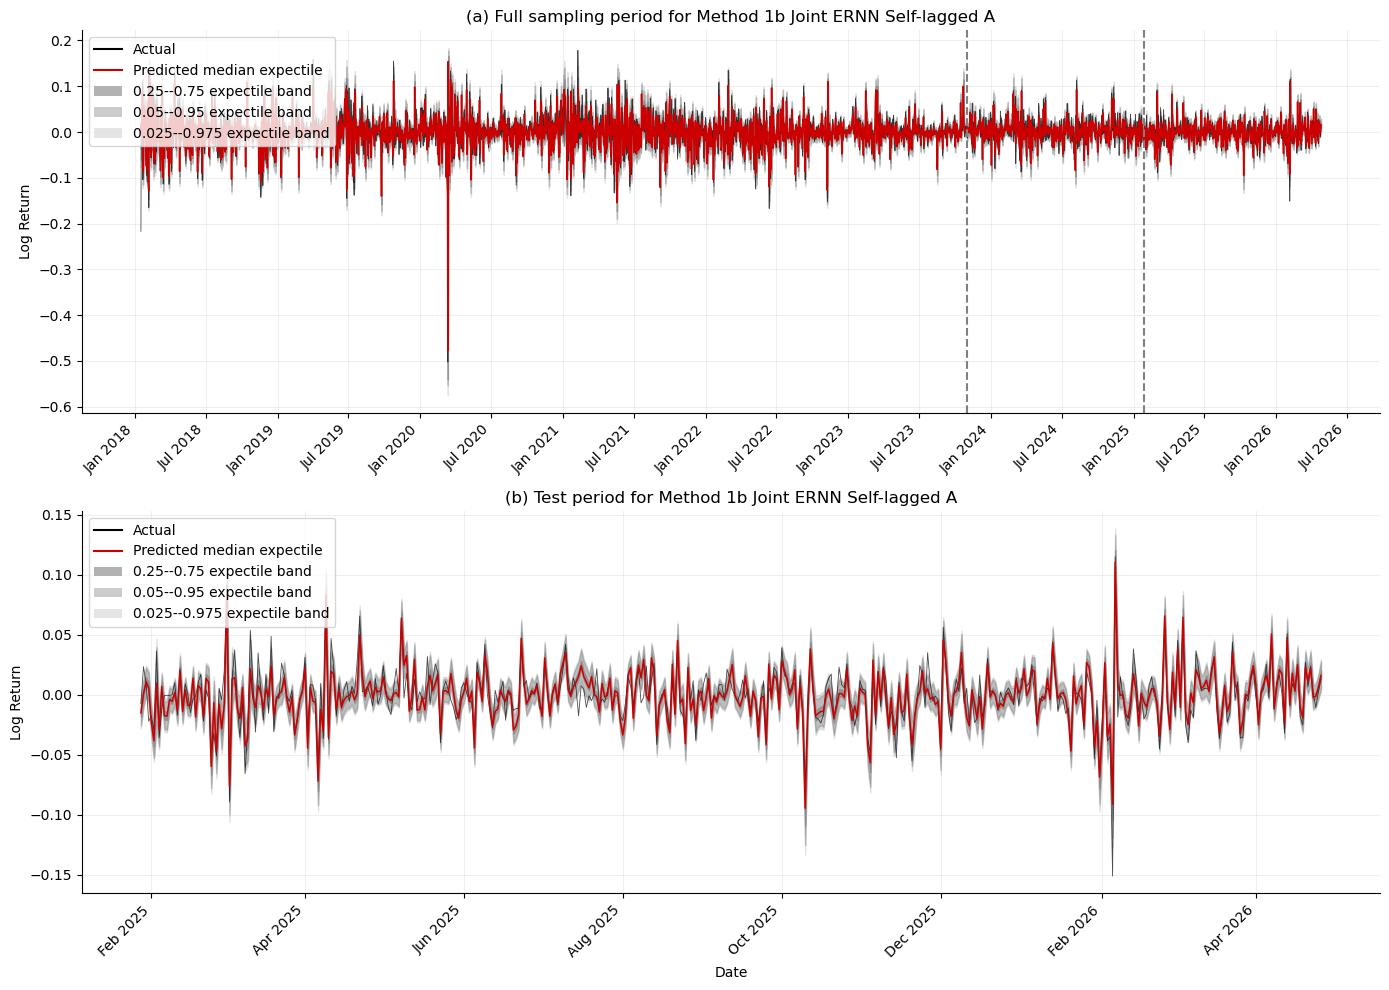

Plot saved to method1b_joint_ernn_a_self_predictions.png

TEST METRICS -- METHOD 1B JOINT ERNN A SELF-LAGGED
  tau       NLL      ASE    sigma
0.025 -2.650944 0.000014 0.009177
0.050 -2.733799 0.000022 0.011151
0.250 -2.883980 0.000054 0.016346
0.500 -2.923457 0.000062 0.017527
0.750 -2.908064 0.000051 0.015945
0.950 -2.780540 0.000021 0.010591
0.975 -2.700324 0.000013 0.008701

Average NLL: -2.797301
Average ASE: 0.000034

CROSSOVER ANALYSIS -- FINAL METHOD 1B FORECASTS
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 0 (0.00%)
(0.500, 0.750): 0 (0.00%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 0 (0.00%) <-- TAIL

Total violations: 0 (0.00%)
Tail violations: 0 (0.00%)

LEARNED SPACING DIAGNOSTICS -- TEST PERIOD
Spacing  Lower_Alpha  Upper_Alpha  Mean_Delta  Minimum_Delta  Maximum_Delta  Delta_Std  Near_Zero_Count  Near_Zero_Rate
delta12        0.025        0.050    0.002171       0.001256       0.008489   0.000952                0             0.0
delta23   

In [16]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ============================================================
# PLOT AND EVALUATE METHOD 1B
# JOINT ERNN A SELF-LAGGED WITH POSITIVE ADJACENT SPACINGS
# ============================================================

m1b_plot_tau_levels = [
    0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975
]
m1b_plot_spacing_names = [
    'delta12', 'delta23', 'delta34',
    'delta45', 'delta56', 'delta67'
]
m1b_plot_spacing_pairs = [
    (0.025, 0.050),
    (0.050, 0.250),
    (0.250, 0.500),
    (0.500, 0.750),
    (0.750, 0.950),
    (0.950, 0.975),
]


# ============================================================
# Reload the selected model if it is not currently in memory
# ============================================================

if 'best_model_method1b' not in globals():
    m1b_plot_checkpoint = torch.load(
        'method1b_joint_ernn_a_self_best.pt',
        map_location='cpu',
        weights_only=False,
    )

    best_model_method1b = HybridERNN_A_Joint_Method1B(
        input_dim=X_train.shape[1],
        config=m1b_plot_checkpoint['config'],
    )
    best_model_method1b.load_state_dict(
        m1b_plot_checkpoint['model_state_dict']
    )

best_model_method1b.eval()


# ============================================================
# Generate full-sample forecasts using one continuous recursion
# ============================================================

m1b_plot_X_all = torch.tensor(
    df[feature_cols].values,
    dtype=torch.float32,
)
m1b_plot_y_all = torch.tensor(
    df['log_return'].values,
    dtype=torch.float32,
)

with torch.no_grad():
    (
        m1b_plot_q_all,
        m1b_plot_sigma,
        m1b_plot_caviar50_all,
        m1b_plot_q50_all,
        m1b_plot_delta_all,
    ) = best_model_method1b(
        m1b_plot_y_all,
        m1b_plot_X_all,
    )

m1b_plot_q_all_np = m1b_plot_q_all.cpu().numpy()
m1b_plot_delta_all_np = m1b_plot_delta_all.cpu().numpy()

m1b_plot_test_start = len(train_df) + len(val_df)
m1b_plot_all_dates = df.index
m1b_plot_test_dates = test_df.index
m1b_plot_actual_all = df['log_return'].values
m1b_plot_actual_test = test_df['log_return'].values

m1b_plot_q_test = m1b_plot_q_all[m1b_plot_test_start:]
m1b_plot_delta_test = m1b_plot_delta_all[m1b_plot_test_start:]
m1b_plot_y_test = m1b_plot_y_all[m1b_plot_test_start:]

if len(m1b_plot_q_test) != len(test_df):
    raise ValueError(
        'Test forecast length does not match test_df. Check that df, '
        'train_df, val_df and test_df use the same chronological split.'
    )


# ============================================================
# Two-panel forecast plot
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

m1b_actual_color = '#000000'
m1b_median_color = '#CC0000'
m1b_interval_color = '#808080'


def m1b_plot_draw_panel(ax, dates, actual, predictions):
    ax.plot(
        dates,
        actual,
        color=m1b_actual_color,
        linewidth=0.6,
        alpha=0.7,
    )
    ax.plot(
        dates,
        predictions[:, 3],
        color=m1b_median_color,
        linewidth=1.1,
    )
    ax.fill_between(
        dates,
        predictions[:, 0],
        predictions[:, 6],
        color=m1b_interval_color,
        alpha=0.20,
    )
    ax.fill_between(
        dates,
        predictions[:, 1],
        predictions[:, 5],
        color=m1b_interval_color,
        alpha=0.40,
    )
    ax.fill_between(
        dates,
        predictions[:, 2],
        predictions[:, 4],
        color=m1b_interval_color,
        alpha=0.60,
    )
    ax.set_ylabel('Log Return')
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


m1b_plot_draw_panel(
    axes[0],
    m1b_plot_all_dates,
    m1b_plot_actual_all,
    m1b_plot_q_all_np,
)
axes[0].axvline(
    train_df.index[-1], color='gray', linestyle='--'
)
axes[0].axvline(
    val_df.index[-1], color='gray', linestyle='--'
)
axes[0].set_title(
    '(a) Full sampling period for Method 1b Joint ERNN Self-lagged A'
)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))

m1b_plot_draw_panel(
    axes[1],
    m1b_plot_test_dates,
    m1b_plot_actual_test,
    m1b_plot_q_all_np[m1b_plot_test_start:],
)
axes[1].set_title(
    '(b) Test period for Method 1b Joint ERNN Self-lagged A'
)
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

m1b_legend_elements = [
    Line2D([0], [0], color=m1b_actual_color, label='Actual'),
    Line2D(
        [0], [0],
        color=m1b_median_color,
        label='Predicted median expectile',
    ),
    Patch(
        facecolor=m1b_interval_color,
        alpha=0.60,
        label='0.25--0.75 expectile band',
    ),
    Patch(
        facecolor=m1b_interval_color,
        alpha=0.40,
        label='0.05--0.95 expectile band',
    ),
    Patch(
        facecolor=m1b_interval_color,
        alpha=0.20,
        label='0.025--0.975 expectile band',
    ),
]

for axis in axes:
    axis.legend(handles=m1b_legend_elements, loc='upper left')
    plt.setp(
        axis.xaxis.get_majorticklabels(),
        rotation=45,
        ha='right',
    )

plt.tight_layout()

m1b_plot_filename = 'method1b_joint_ernn_a_self_predictions.png'
plt.savefig(m1b_plot_filename, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(f'Plot saved to {m1b_plot_filename}')


# ============================================================
# Test AGD NLL and asymmetric squared error by expectile level
# ============================================================

m1b_plot_metric_rows = []

for level_index, tau in enumerate(m1b_plot_tau_levels):
    e_level = m1b_plot_q_test[:, level_index]
    sigma_level = m1b_plot_sigma[level_index]
    residual = m1b_plot_y_test - e_level
    weight = torch.abs(
        residual.new_tensor(tau)
        - (residual < 0).to(residual.dtype)
    )
    weighted_squared_error = weight * residual.square()
    constant = (
        torch.log(
            torch.sqrt(residual.new_tensor(torch.pi / tau))
            + torch.sqrt(
                residual.new_tensor(torch.pi / (1 - tau))
            )
        )
        - np.log(2.0)
    )

    nll = (
        torch.log(sigma_level)
        + constant
        + weighted_squared_error / sigma_level.square()
    ).mean().item()
    ase = weighted_squared_error.mean().item()

    m1b_plot_metric_rows.append({
        'tau': tau,
        'NLL': nll,
        'ASE': ase,
        'sigma': sigma_level.item(),
    })

m1b_plot_metrics_df = pd.DataFrame(m1b_plot_metric_rows)
m1b_plot_average_nll = m1b_plot_metrics_df['NLL'].mean()
m1b_plot_average_ase = m1b_plot_metrics_df['ASE'].mean()

print('\n' + '=' * 72)
print('TEST METRICS -- METHOD 1B JOINT ERNN A SELF-LAGGED')
print('=' * 72)
print(m1b_plot_metrics_df.to_string(index=False))
print(f'\nAverage NLL: {m1b_plot_average_nll:.6f}')
print(f'Average ASE: {m1b_plot_average_ase:.6f}')


# ============================================================
# Crossover analysis of the complete final forecasts
# ============================================================

m1b_plot_crossover_rows = []
m1b_plot_total_violations = 0
m1b_plot_tail_violations = 0
m1b_plot_tail_pairs = [(0.025, 0.050), (0.950, 0.975)]

print('\n' + '=' * 72)
print('CROSSOVER ANALYSIS -- FINAL METHOD 1B FORECASTS')
print('=' * 72)

for pair_index, (lower, upper) in enumerate(
    m1b_plot_spacing_pairs
):
    violations = int((
        m1b_plot_q_test[:, pair_index]
        > m1b_plot_q_test[:, pair_index + 1]
    ).sum().item())
    rate = violations / len(m1b_plot_y_test)

    m1b_plot_total_violations += violations
    if (lower, upper) in m1b_plot_tail_pairs:
        m1b_plot_tail_violations += violations

    m1b_plot_crossover_rows.append({
        'Lower': lower,
        'Upper': upper,
        'Violations': violations,
        'Rate': rate,
    })

    tail_label = (
        ' <-- TAIL' if (lower, upper) in m1b_plot_tail_pairs else ''
    )
    print(
        f'({lower:.3f}, {upper:.3f}): '
        f'{violations} ({100 * rate:.2f}%){tail_label}'
    )

m1b_plot_total_rate = m1b_plot_total_violations / (
    len(m1b_plot_y_test) * len(m1b_plot_spacing_pairs)
)
m1b_plot_tail_rate = m1b_plot_tail_violations / (
    len(m1b_plot_y_test) * len(m1b_plot_tail_pairs)
)

print(
    f'\nTotal violations: {m1b_plot_total_violations} '
    f'({100 * m1b_plot_total_rate:.2f}%)'
)
print(
    f'Tail violations: {m1b_plot_tail_violations} '
    f'({100 * m1b_plot_tail_rate:.2f}%)'
)


# ============================================================
# Learned-spacing diagnostics over the test period
# ============================================================

m1b_plot_delta_rows = []

for spacing_index, (name, pair) in enumerate(zip(
    m1b_plot_spacing_names,
    m1b_plot_spacing_pairs,
)):
    delta_level = m1b_plot_delta_test[:, spacing_index]

    m1b_plot_delta_rows.append({
        'Spacing': name,
        'Lower_Alpha': pair[0],
        'Upper_Alpha': pair[1],
        'Mean_Delta': delta_level.mean().item(),
        'Minimum_Delta': delta_level.min().item(),
        'Maximum_Delta': delta_level.max().item(),
        'Delta_Std': delta_level.std(unbiased=False).item(),
        'Near_Zero_Count': int(
            (delta_level <= 1e-5).sum().item()
        ),
        'Near_Zero_Rate': (
            delta_level <= 1e-5
        ).float().mean().item(),
    })

m1b_plot_delta_df = pd.DataFrame(m1b_plot_delta_rows)

print('\n' + '=' * 72)
print('LEARNED SPACING DIAGNOSTICS -- TEST PERIOD')
print('=' * 72)
print(m1b_plot_delta_df.to_string(index=False))


# ============================================================
# Detailed predictions by test date
# ============================================================

m1b_plot_prediction_df = pd.DataFrame({
    'Date': pd.to_datetime(m1b_plot_test_dates),
    'Actual': m1b_plot_actual_test,
})

for level_index, tau in enumerate(m1b_plot_tau_levels):
    m1b_plot_prediction_df[f'E_{tau:.3f}'] = (
        m1b_plot_q_all_np[
            m1b_plot_test_start:,
            level_index,
        ]
    )

for spacing_index, (lower, upper) in enumerate(
    m1b_plot_spacing_pairs
):
    m1b_plot_prediction_df[
        f'Gap_{lower:.3f}_{upper:.3f}'
    ] = m1b_plot_delta_all_np[
        m1b_plot_test_start:,
        spacing_index,
    ]


# ============================================================
# Save outputs
# ============================================================

m1b_plot_metrics_df.to_csv(
    'method1b_joint_ernn_a_self_test_metrics.csv',
    index=False,
)
pd.DataFrame(m1b_plot_crossover_rows).to_csv(
    'method1b_joint_ernn_a_self_crossover.csv',
    index=False,
)
m1b_plot_delta_df.to_csv(
    'method1b_joint_ernn_a_self_delta_summary.csv',
    index=False,
)
m1b_plot_prediction_df.to_csv(
    'method1b_joint_ernn_a_self_test_predictions.csv',
    index=False,
)

print('\nSaved Method 1b outputs:')
print('  method1b_joint_ernn_a_self_predictions.png')
print('  method1b_joint_ernn_a_self_test_metrics.csv')
print('  method1b_joint_ernn_a_self_crossover.csv')
print('  method1b_joint_ernn_a_self_delta_summary.csv')
print('  method1b_joint_ernn_a_self_test_predictions.csv')



# Cross over dealing 2

In [23]:
import copy

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from optuna.samplers import TPESampler


# ============================================================
# Method 2 -- Sequential Hybrid ERNN A Self-lagged
# Median first, followed by upper and lower levels
# ============================================================

m2_ernn_self_a_tau_levels = [
    0.025, 0.050, 0.250, 0.500,
    0.750, 0.950, 0.975
]

m2_ernn_self_a_order = [
    0.500,
    0.750, 0.950, 0.975,
    0.250, 0.050, 0.025
]

m2_ernn_self_a_reference = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050
}

m2_ernn_self_a_direction = {
    0.500: 'median',
    0.750: 'upper',
    0.950: 'upper',
    0.975: 'upper',
    0.250: 'lower',
    0.050: 'lower',
    0.025: 'lower'
}

M2_ERNN_SELF_A_DELTA = 1e-6
M2_ERNN_SELF_A_SCALE = 1e-3
M2_ERNN_SELF_A_PSI_EPS = 1e-4


# ============================================================
# Method 2 ERNN model
# ============================================================

class M2SequentialERNNASelf(nn.Module):
    def __init__(
        self,
        input_dim,
        config,
        direction='median'
    ):
        super().__init__()

        self.direction = direction
        self.eps = 1e-6

        self.gamma1_raw = nn.Parameter(
            torch.tensor(1.386)
        )
        self.gamma2_raw = nn.Parameter(
            torch.tensor(0.3)
        )
        self.gamma3_raw = nn.Parameter(
            torch.tensor(0.3)
        )
        self.psi_raw = nn.Parameter(
            torch.tensor(0.0)
        )
        self.sigma_raw = nn.Parameter(
            torch.tensor(0.5)
        )

        # Add the adjacent prediction as an input
        # for each nonmedian model
        fnn_input_dim = (
            input_dim
            if direction == 'median'
            else input_dim + 1
        )

        layers = []
        previous_dim = fnn_input_dim

        for i in range(
            config['n_hidden_layers']
        ):
            hidden_dim = config[
                f'hidden_dim_{i}'
            ]

            layers.append(
                nn.Linear(
                    previous_dim,
                    hidden_dim
                )
            )

            if config['layernorm']:
                layers.append(
                    nn.LayerNorm(hidden_dim)
                )

            layers.append(
                self._get_activation(
                    config['activation']
                )
            )

            if config['dropout'] > 0:
                layers.append(
                    nn.Dropout(
                        config['dropout']
                    )
                )

            previous_dim = hidden_dim

        layers.append(
            nn.Linear(previous_dim, 1)
        )

        self.fnn = nn.Sequential(*layers)

        for module in self.fnn.modules():
            if isinstance(module, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(
                        module.weight
                    )

                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(
                        module.weight
                    )

                if module.bias is not None:
                    nn.init.zeros_(
                        module.bias
                    )

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())

    def forward(
        self,
        y,
        X,
        reference=None,
        initial_care=None,
        initial_y=None
    ):
        gamma1 = torch.sigmoid(
            self.gamma1_raw
        )

        gamma2 = F.softplus(
            self.gamma2_raw
        )

        gamma3 = F.softplus(
            self.gamma3_raw
        )

        # Keep psi numerically below one
        psi = (
            (1.0 - M2_ERNN_SELF_A_PSI_EPS)
            * torch.sigmoid(self.psi_raw)
        )

        sigma = (
            F.softplus(self.sigma_raw)
            + self.eps
        )

        if self.direction == 'median':
            fnn_input = X

        else:
            if reference is None:
                raise ValueError(
                    'A reference prediction is required '
                    'for a nonmedian level.'
                )

            fnn_input = torch.cat(
                [
                    X,
                    reference.reshape(-1, 1)
                ],
                dim=1
            )

        raw_fnn = (
            self.fnn(fnn_input)
            .squeeze(-1)
        )

        (
            e_hybrid,
            e_care,
            constrained_fnn
        ) = m2_ernn_self_a_location(
            y=y,
            raw_fnn=raw_fnn,
            gamma1=gamma1,
            gamma2=gamma2,
            gamma3=gamma3,
            psi=psi,
            reference=reference,
            direction=self.direction,
            initial_care=initial_care,
            initial_y=initial_y
        )

        return (
            e_hybrid,
            sigma,
            e_care,
            constrained_fnn
        )


# ============================================================
# Smooth positive adjustment
# ============================================================

def m2_ernn_self_a_scaled_softplus(
    value,
    scale=M2_ERNN_SELF_A_SCALE
):
    return (
        scale
        * F.softplus(value / scale)
    )


# ============================================================
# Self-lagged asymmetric hybrid location
# ============================================================

def m2_ernn_self_a_location(
    y,
    raw_fnn,
    gamma1,
    gamma2,
    gamma3,
    psi,
    reference=None,
    direction='median',
    initial_care=None,
    initial_y=None
):
    T = len(y)

    zero = y.new_tensor(0.0)

    hybrid_list = []
    care_list = []
    fnn_list = []

    if (
        (initial_care is None)
        != (initial_y is None)
    ):
        raise ValueError(
            'initial_care and initial_y '
            'must be supplied together.'
        )

    has_initial_state = (
        initial_care is not None
    )

    previous_care = (
        initial_care
        if has_initial_state
        else zero
    )

    for t in range(T):
        if (
            t == 0
            and not has_initial_state
        ):
            care_list.append(zero)
            hybrid_list.append(zero)
            fnn_list.append(raw_fnn[t])
            continue

        previous_y = (
            initial_y
            if t == 0
            else y[t - 1]
        )

        y_pos = torch.clamp(
            previous_y,
            min=0
        )

        y_neg = torch.clamp(
            -previous_y,
            min=0
        )

        # Self-lagged CARE recursion
        care_t = (
            gamma1 * previous_care
            + gamma2 * y_pos
            + gamma3 * y_neg
        )

        if direction == 'median':
            fnn_t = raw_fnn[t]

        elif direction == 'upper':
            fnn_lower_bound = (
                reference[t]
                + M2_ERNN_SELF_A_DELTA
                - psi * care_t
            ) / (1.0 - psi)

            fnn_t = (
                fnn_lower_bound
                + m2_ernn_self_a_scaled_softplus(
                    raw_fnn[t]
                    - fnn_lower_bound
                )
            )

        elif direction == 'lower':
            fnn_upper_bound = (
                reference[t]
                - M2_ERNN_SELF_A_DELTA
                - psi * care_t
            ) / (1.0 - psi)

            fnn_t = (
                fnn_upper_bound
                - m2_ernn_self_a_scaled_softplus(
                    fnn_upper_bound
                    - raw_fnn[t]
                )
            )

        else:
            raise ValueError(
                "direction must be 'median', "
                "'upper' or 'lower'."
            )

        hybrid_t = (
            psi * care_t
            + (1.0 - psi) * fnn_t
        )

        care_list.append(care_t)
        hybrid_list.append(hybrid_t)
        fnn_list.append(fnn_t)

        # Self-lagged: previous pure CARE output
        previous_care = care_t

    return (
        torch.stack(hybrid_list),
        torch.stack(care_list),
        torch.stack(fnn_list)
    )


# ============================================================
# Original level-specific AGD loss
# ============================================================

def m2_ernn_self_a_loss(
    y,
    e_hybrid,
    sigma,
    tau
):
    residual = y - e_hybrid

    tau_tensor = torch.tensor(
        tau,
        dtype=e_hybrid.dtype,
        device=e_hybrid.device
    )

    weight = torch.abs(
        tau_tensor
        - (residual < 0).float()
    )

    asymmetric_squared_error = (
        weight
        * residual.pow(2)
    )

    constant = (
        torch.log(
            torch.sqrt(
                torch.pi / tau_tensor
            )
            + torch.sqrt(
                torch.pi
                / (1.0 - tau_tensor)
            )
        )
        - np.log(2.0)
    )

    nll = (
        torch.log(sigma)
        + constant
        + asymmetric_squared_error
        / sigma.pow(2)
    )

    return nll.mean()


def m2_ernn_self_a_compute_ase(
    y,
    e_hybrid,
    tau
):
    residual = y - e_hybrid

    weight = torch.abs(
        torch.tensor(
            tau,
            dtype=e_hybrid.dtype,
            device=e_hybrid.device
        )
        - (residual < 0).float()
    )

    return (
        weight
        * residual.pow(2)
    ).mean().item()


# ============================================================
# Optuna configuration
# ============================================================

def m2_ernn_self_a_suggest_config(
    trial
):
    config = {
        'n_hidden_layers':
            trial.suggest_int(
                'n_hidden_layers',
                1,
                3
            ),
        'activation':
            trial.suggest_categorical(
                'activation',
                [
                    'relu',
                    'elu',
                    'gelu',
                    'tanh'
                ]
            ),
        'dropout':
            trial.suggest_float(
                'dropout',
                0.0,
                0.5
            ),
        'layernorm':
            trial.suggest_categorical(
                'layernorm',
                [True, False]
            ),
        'weight_init':
            trial.suggest_categorical(
                'weight_init',
                ['glorot', 'he']
            ),
        'lr':
            trial.suggest_float(
                'lr',
                1e-4,
                5e-2,
                log=True
            ),
        'optimizer':
            trial.suggest_categorical(
                'optimizer',
                ['adam', 'adamw']
            ),
        'weight_decay':
            trial.suggest_float(
                'weight_decay',
                0.0,
                1e-4
            ),
        'gradient_clip':
            trial.suggest_categorical(
                'gradient_clip',
                [0.1, 1.0, 5.0]
            ),
        'patience':
            trial.suggest_categorical(
                'patience',
                [10, 20, 30]
            )
    }

    for i in range(
        config['n_hidden_layers']
    ):
        config[f'hidden_dim_{i}'] = (
            trial.suggest_int(
                f'hidden_dim_{i}',
                32,
                256
            )
        )

    return config


# ============================================================
# Fit one level
# ============================================================

def m2_ernn_self_a_fit(
    config,
    tau,
    direction,
    reference_train=None,
    reference_val=None,
    max_epochs=200,
    seed=2026
):
    torch.manual_seed(seed)

    model = M2SequentialERNNASelf(
        input_dim=X_train.shape[1],
        config=config,
        direction=direction
    )

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config[
                'weight_decay'
            ]
        )

    else:
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config[
                'weight_decay'
            ]
        )

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            patience=10,
            factor=0.5,
            min_lr=1e-6
        )
    )

    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()

        (
            e_train,
            sigma,
            _,
            _
        ) = model(
            y=y_train,
            X=X_train,
            reference=reference_train
        )

        # Exclude the initialisation row
        train_loss = m2_ernn_self_a_loss(
            y=y_train[1:],
            e_hybrid=e_train[1:],
            sigma=sigma,
            tau=tau
        )

        if (
            torch.isnan(train_loss)
            or torch.isinf(train_loss)
        ):
            return None

        train_loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            config['gradient_clip']
        )

        optimizer.step()

        model.eval()

        with torch.no_grad():
            (
                _,
                sigma_val,
                care_train,
                _
            ) = model(
                y=y_train,
                X=X_train,
                reference=reference_train
            )

            (
                e_val,
                _,
                _,
                _
            ) = model(
                y=y_val,
                X=X_val,
                reference=reference_val,
                initial_care=care_train[-1],
                initial_y=y_train[-1]
            )

            val_loss = m2_ernn_self_a_loss(
                y=y_val,
                e_hybrid=e_val,
                sigma=sigma_val,
                tau=tau
            )

        scheduler.step(
            val_loss.item()
        )

        if (
            val_loss.item()
            < best_val_loss
        ):
            best_val_loss = (
                val_loss.item()
            )

            patience_counter = 0

            best_model_state = (
                copy.deepcopy(
                    model.state_dict()
                )
            )

        else:
            patience_counter += 1

            if (
                patience_counter
                >= config['patience']
            ):
                break

    if best_model_state is None:
        return None

    model.load_state_dict(
        best_model_state
    )

    return model


# ============================================================
# Evaluate one fitted level
# ============================================================

def m2_ernn_self_a_evaluate(
    model,
    tau,
    reference_train=None,
    reference_val=None
):
    model.eval()

    with torch.no_grad():
        (
            e_train,
            sigma,
            care_train,
            fnn_train
        ) = model(
            y=y_train,
            X=X_train,
            reference=reference_train
        )

        (
            e_val,
            _,
            care_val,
            fnn_val
        ) = model(
            y=y_val,
            X=X_val,
            reference=reference_val,
            initial_care=care_train[-1],
            initial_y=y_train[-1]
        )

        val_nll = m2_ernn_self_a_loss(
            y=y_val,
            e_hybrid=e_val,
            sigma=sigma,
            tau=tau
        ).item()

        val_ase = (
            m2_ernn_self_a_compute_ase(
                y=y_val,
                e_hybrid=e_val,
                tau=tau
            )
        )

        gamma1 = torch.sigmoid(
            model.gamma1_raw
        ).item()

        gamma2 = F.softplus(
            model.gamma2_raw
        ).item()

        gamma3 = F.softplus(
            model.gamma3_raw
        ).item()

        psi = (
            (1.0 - M2_ERNN_SELF_A_PSI_EPS)
            * torch.sigmoid(model.psi_raw)
        ).item()

        sigma_value = (
            F.softplus(model.sigma_raw)
            + model.eps
        ).item()

    return {
        'val_nll': val_nll,
        'val_ase': val_ase,
        'train_prediction': e_train.detach(),
        'val_prediction': e_val.detach(),
        'train_care': care_train.detach(),
        'val_care': care_val.detach(),
        'train_fnn': fnn_train.detach(),
        'val_fnn': fnn_val.detach(),
        'gamma1': gamma1,
        'gamma2': gamma2,
        'gamma3': gamma3,
        'psi': psi,
        'sigma': sigma_value
    }


# ============================================================
# Objective factory
# Prevents "return outside function" errors
# ============================================================

def m2_ernn_self_a_make_objective(
    tau,
    direction,
    reference_train,
    reference_val,
    seed
):
    def objective(trial):
        config = (
            m2_ernn_self_a_suggest_config(
                trial
            )
        )

        model = m2_ernn_self_a_fit(
            config=config,
            tau=tau,
            direction=direction,
            reference_train=reference_train,
            reference_val=reference_val,
            max_epochs=200,
            seed=seed
        )

        if model is None:
            return float('inf')

        metrics = (
            m2_ernn_self_a_evaluate(
                model=model,
                tau=tau,
                reference_train=reference_train,
                reference_val=reference_val
            )
        )

        trial.set_user_attr(
            'val_nll',
            metrics['val_nll']
        )

        trial.set_user_attr(
            'val_ase',
            metrics['val_ase']
        )

        trial.set_user_attr(
            'gamma1',
            metrics['gamma1']
        )

        trial.set_user_attr(
            'gamma2',
            metrics['gamma2']
        )

        trial.set_user_attr(
            'gamma3',
            metrics['gamma3']
        )

        trial.set_user_attr(
            'psi',
            metrics['psi']
        )

        trial.set_user_attr(
            'sigma',
            metrics['sigma']
        )

        print(
            f"Trial {trial.number}: "
            f"tau={tau:.3f} | "
            f"NLL={metrics['val_nll']:.6f} | "
            f"ASE={metrics['val_ase']:.8f}"
        )

        return metrics['val_nll']

    return objective


# ============================================================
# Rank trials by validation NLL and ASE
# ============================================================

def m2_ernn_self_a_select_trial(
    study
):
    trials = [
        trial
        for trial in study.trials
        if (
            trial.state
            == optuna.trial.TrialState.COMPLETE
            and trial.value is not None
            and np.isfinite(trial.value)
            and 'val_nll'
            in trial.user_attrs
            and 'val_ase'
            in trial.user_attrs
        )
    ]

    if len(trials) == 0:
        raise RuntimeError(
            'No valid completed trials.'
        )

    for trial in trials:
        trial._nll = (
            trial.user_attrs['val_nll']
        )

        trial._ase = (
            trial.user_attrs['val_ase']
        )

    for rank, trial in enumerate(
        sorted(
            trials,
            key=lambda item: item._nll
        ),
        start=1
    ):
        trial._rank_nll = rank

    for rank, trial in enumerate(
        sorted(
            trials,
            key=lambda item: item._ase
        ),
        start=1
    ):
        trial._rank_ase = rank

    best_trial = min(
        trials,
        key=lambda item: (
            item._rank_nll
            + item._rank_ase,
            item._nll,
            item._ase,
            item.number
        )
    )

    return best_trial, trials


# ============================================================
# Sequential tuning
# ============================================================

m2_ernn_self_a_best_configs = {}
m2_ernn_self_a_final_models = {}
m2_ernn_self_a_train_predictions = {}
m2_ernn_self_a_val_predictions = {}
m2_ernn_self_a_validation_metrics = {}
m2_ernn_self_a_studies = {}

for level_index, tau in enumerate(
    m2_ernn_self_a_order
):
    direction = (
        m2_ernn_self_a_direction[tau]
    )

    reference_tau = (
        m2_ernn_self_a_reference[tau]
    )

    if reference_tau is None:
        reference_train = None
        reference_val = None

    else:
        reference_train = (
            m2_ernn_self_a_train_predictions[
                reference_tau
            ].detach()
        )

        reference_val = (
            m2_ernn_self_a_val_predictions[
                reference_tau
            ].detach()
        )

    current_seed = 2026 + level_index

    print('\n' + '=' * 70)
    print(
        'METHOD 2 -- TUNING ERNN A SELF-LAGGED '
        f'FOR TAU = {tau}'
    )
    print(
        f'Direction: {direction} | '
        f'Reference: {reference_tau}'
    )
    print('=' * 70)

    sampler = TPESampler(
        seed=current_seed
    )

    study = optuna.create_study(
        direction='minimize',
        sampler=sampler
    )

    objective = (
        m2_ernn_self_a_make_objective(
            tau=tau,
            direction=direction,
            reference_train=reference_train,
            reference_val=reference_val,
            seed=current_seed
        )
    )

    study.optimize(
        objective,
        n_trials=200,
        show_progress_bar=True
    )

    (
        best_trial,
        valid_trials
    ) = m2_ernn_self_a_select_trial(
        study
    )

    # Save trial ranking
    ranking_records = []

    for trial in valid_trials:
        record = {
            'tau': tau,
            'trial': trial.number,
            'val_nll': trial._nll,
            'val_ase': trial._ase,
            'rank_nll':
                trial._rank_nll,
            'rank_ase':
                trial._rank_ase,
            'sum_rank':
                trial._rank_nll
                + trial._rank_ase,
            'gamma1':
                trial.user_attrs['gamma1'],
            'gamma2':
                trial.user_attrs['gamma2'],
            'gamma3':
                trial.user_attrs['gamma3'],
            'psi':
                trial.user_attrs['psi'],
            'sigma':
                trial.user_attrs['sigma']
        }

        record.update(trial.params)
        ranking_records.append(record)

    ranking_df = pd.DataFrame(
        ranking_records
    ).sort_values(
        [
            'sum_rank',
            'val_nll',
            'val_ase'
        ]
    )

    ranking_df.to_csv(
        (
            'method2_sequential_ernn_a_self_'
            f'ranking_tau_{tau}.csv'
        ),
        index=False
    )

    best_config = (
        best_trial.params.copy()
    )

    # Refit selected architecture
    final_model = (
        m2_ernn_self_a_fit(
            config=best_config,
            tau=tau,
            direction=direction,
            reference_train=reference_train,
            reference_val=reference_val,
            max_epochs=200,
            seed=current_seed
        )
    )

    final_metrics = (
        m2_ernn_self_a_evaluate(
            model=final_model,
            tau=tau,
            reference_train=reference_train,
            reference_val=reference_val
        )
    )

    m2_ernn_self_a_best_configs[
        tau
    ] = best_config

    m2_ernn_self_a_final_models[
        tau
    ] = final_model

    m2_ernn_self_a_train_predictions[
        tau
    ] = final_metrics[
        'train_prediction'
    ]

    m2_ernn_self_a_val_predictions[
        tau
    ] = final_metrics[
        'val_prediction'
    ]

    m2_ernn_self_a_validation_metrics[
        tau
    ] = {
        'val_nll':
            final_metrics['val_nll'],
        'val_ase':
            final_metrics['val_ase'],
        'gamma1':
            final_metrics['gamma1'],
        'gamma2':
            final_metrics['gamma2'],
        'gamma3':
            final_metrics['gamma3'],
        'psi':
            final_metrics['psi'],
        'sigma':
            final_metrics['sigma'],
        'direction':
            direction,
        'reference_tau':
            reference_tau,
        'best_trial':
            best_trial.number
    }

    m2_ernn_self_a_studies[
        tau
    ] = study

    print(
        f'\nSelected tau={tau:.3f}: '
        f"NLL={final_metrics['val_nll']:.6f} | "
        f"ASE={final_metrics['val_ase']:.8f}"
    )


# ============================================================
# Check validation ordering
# ============================================================

m2_ernn_self_a_val_matrix = torch.stack(
    [
        m2_ernn_self_a_val_predictions[tau]
        for tau in m2_ernn_self_a_tau_levels
    ],
    dim=1
)

m2_ernn_self_a_val_crossovers = (
    m2_ernn_self_a_val_matrix[:, :-1]
    > m2_ernn_self_a_val_matrix[:, 1:]
)

m2_ernn_self_a_val_pair_counts = (
    m2_ernn_self_a_val_crossovers
    .sum(dim=0)
)

m2_ernn_self_a_val_total_crossovers = int(
    m2_ernn_self_a_val_pair_counts
    .sum()
    .item()
)

m2_ernn_self_a_val_tail_crossovers = int(
    (
        m2_ernn_self_a_val_pair_counts[0]
        + m2_ernn_self_a_val_pair_counts[-1]
    ).item()
)


# ============================================================
# Save all seven fitted models
# ============================================================

m2_ernn_self_a_saved_models = {}

for tau in m2_ernn_self_a_tau_levels:
    m2_ernn_self_a_saved_models[
        str(tau)
    ] = {
        'state_dict':
            m2_ernn_self_a_final_models[
                tau
            ].state_dict(),
        'config':
            m2_ernn_self_a_best_configs[
                tau
            ],
        'direction':
            m2_ernn_self_a_direction[
                tau
            ],
        'reference_tau':
            m2_ernn_self_a_reference[
                tau
            ]
    }

torch.save(
    {
        'tau_levels':
            m2_ernn_self_a_tau_levels,
        'estimation_order':
            m2_ernn_self_a_order,
        'models':
            m2_ernn_self_a_saved_models,
        'validation_metrics':
            m2_ernn_self_a_validation_metrics,
        'validation_crossover_count':
            m2_ernn_self_a_val_total_crossovers,
        'validation_tail_count':
            m2_ernn_self_a_val_tail_crossovers,
        'delta':
            M2_ERNN_SELF_A_DELTA,
        'softplus_scale':
            M2_ERNN_SELF_A_SCALE
    },
    'method2_sequential_ernn_a_self_best.pt'
)


# ============================================================
# Final validation summary
# ============================================================

m2_ernn_self_a_average_val_nll = np.mean(
    [
        m2_ernn_self_a_validation_metrics[
            tau
        ]['val_nll']
        for tau
        in m2_ernn_self_a_tau_levels
    ]
)

m2_ernn_self_a_average_val_ase = np.mean(
    [
        m2_ernn_self_a_validation_metrics[
            tau
        ]['val_ase']
        for tau
        in m2_ernn_self_a_tau_levels
    ]
)

print('\n' + '=' * 70)
print(
    'METHOD 2 TUNING COMPLETE -- '
    'ERNN A SELF-LAGGED'
)
print('=' * 70)

print(
    f'Average validation NLL: '
    f'{m2_ernn_self_a_average_val_nll:.6f}'
)

print(
    f'Average validation ASE: '
    f'{m2_ernn_self_a_average_val_ase:.8f}'
)

print(
    f'Validation crossover count: '
    f'{m2_ernn_self_a_val_total_crossovers}'
)

print(
    f'Validation tail crossover count: '
    f'{m2_ernn_self_a_val_tail_crossovers}'
)

print(
    'Checkpoint saved to '
    'method2_sequential_ernn_a_self_best.pt'
)

[I 2026-08-03 13:34:50,632] A new study created in memory with name: no-name-37721db6-49bf-4631-96eb-3a0475bbff41



METHOD 2 -- TUNING ERNN A SELF-LAGGED FOR TAU = 0.5
Direction: median | Reference: None


  0%|          | 0/200 [00:00<?, ?it/s]

Trial 0: tau=0.500 | NLL=0.802541 | ASE=0.00141781
[I 2026-08-03 13:35:14,189] Trial 0 finished with value: 0.8025408983230591 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 0.8025408983230591.
Trial 1: tau=0.500 | NLL=-0.227503 | ASE=0.00022917
[I 2026-08-03 13:35:42,057] Trial 1 finished with value: -0.22750328481197357 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: -0.22750328481197357.
Trial 2: tau=0.500 | NLL=0.897749 | ASE=0.00530420
[I 2026-08-03 13:35:46,708] Tri

[I 2026-08-03 14:51:22,384] A new study created in memory with name: no-name-a01709c2-bdc9-4d6c-817b-b0e599dec443


...

Trial 0: tau=0.050 | NLL=0.504392 | ASE=0.00008545
[I 2026-08-04 11:13:21,369] Trial 0 finished with value: 0.5043924450874329 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'weight_decay': 1.3627456384020455e-05, 'gradient_clip': 0.1, 'patience': 20, 'hidden_dim_0': 210, 'hidden_dim_1': 162}. Best is trial 0 with value: 0.5043924450874329.
Trial 1: tau=0.050 | NLL=-0.769557 | ASE=0.00008248
[I 2026-08-04 11:14:08,730] Trial 1 finished with value: -0.7695574164390564 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.09630890988459678, 'layernorm': False, 'weight_init': 'he', 'lr': 0.014080280114638532, 'optimizer': 'adam', 'weight_decay': 6.431370011304687e-05, 'gradient_clip': 0.1, 'patience': 10, 'hidden_dim_0': 88, 'hidden_dim_1': 196, 'hidden_dim_2': 94}. Best is trial 1 with value: -0.7695574164390564.
Trial 2: tau=0.050

[I 2026-08-04 14:58:51,896] A new study created in memory with name: no-name-97aa7c3b-6b6b-4c7f-ac6e-4c1359bf3a42



Selected tau=0.050: NLL=-2.507993 | ASE=0.00004616

METHOD 2 -- TUNING ERNN A SELF-LAGGED FOR TAU = 0.025
Direction: lower | Reference: 0.05


  0%|          | 0/200 [00:00<?, ?it/s]

Trial 0: tau=0.025 | NLL=0.644969 | ASE=0.00003378
[I 2026-08-04 14:59:40,496] Trial 0 finished with value: 0.6449692845344543 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'weight_decay': 2.0378044529961404e-05, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 189, 'hidden_dim_1': 194, 'hidden_dim_2': 105}. Best is trial 0 with value: 0.6449692845344543.
Trial 1: tau=0.025 | NLL=1.552173 | ASE=0.00003378
[I 2026-08-04 15:00:27,656] Trial 1 finished with value: 1.5521732568740845 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.40125521853112683, 'layernorm': False, 'weight_init': 'he', 'lr': 0.002129411642087111, 'optimizer': 'adamw', 'weight_decay': 1.3495676574961092e-06, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 133, 'hidden_dim_1': 222, 'hidden_dim_2': 66}. Best is trial 0 with value: 0.6449692845344543.
T

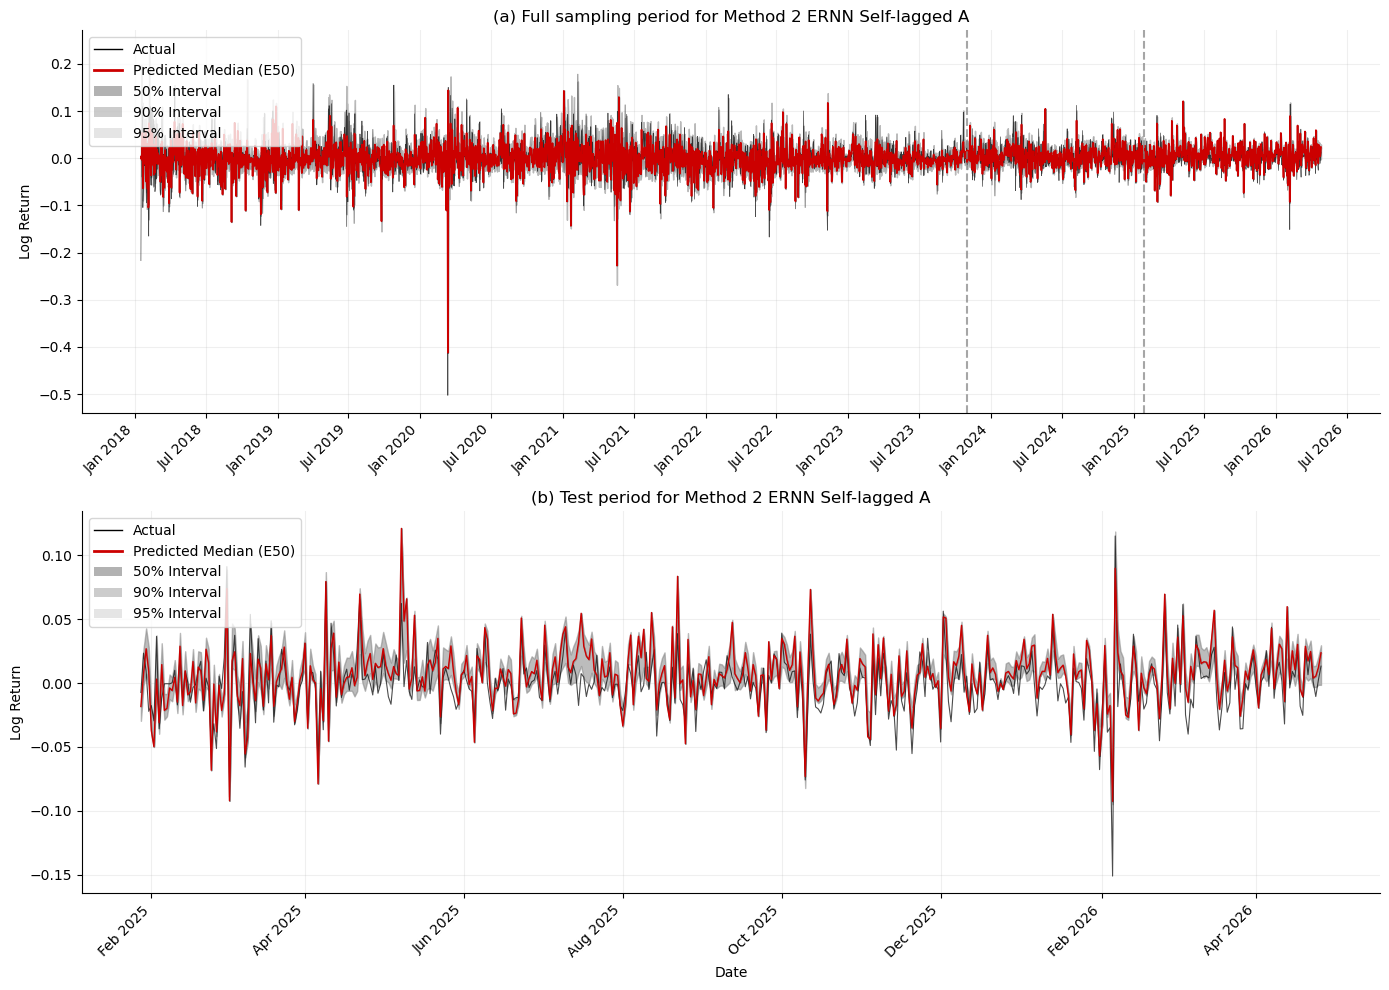

Plot saved to method2_sequential_ernn_a_self_predictions.png

TEST METRICS -- METHOD 2 ERNN A SELF-LAGGED
  tau       NLL      ASE
0.025 -2.074270 0.000058
0.050 -2.418724 0.000060
0.250 -2.503917 0.000157
0.500 -2.683553 0.000117
0.750 -2.741665 0.000076
0.950 -2.613483 0.000026
0.975 -2.776544 0.000015

Average NLL: -2.544594
Average ASE: 0.00007270

CROSSOVER ANALYSIS -- FINAL METHOD 2 HYBRID OUTPUT
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 0 (0.00%)
(0.500, 0.750): 0 (0.00%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 0 (0.00%) <-- TAIL

Total violations: 0 (0.00%)
Tail violations: 0 (0.00%)

Metrics saved to method2_sequential_ernn_a_self_test_metrics.csv


In [25]:
# ============================================================
# Plot and evaluate Method 2
# Sequential ERNN A Self-lagged
# ============================================================

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ============================================================
# Generate all seven full-sample predictions
# ============================================================

m2_ernn_self_a_X_all = torch.tensor(
    df[feature_cols].values,
    dtype=torch.float32
)

m2_ernn_self_a_y_all = torch.tensor(
    df['log_return'].values,
    dtype=torch.float32
)

m2_ernn_self_a_all_predictions = {}
m2_ernn_self_a_all_care = {}
m2_ernn_self_a_all_fnn = {}
m2_ernn_self_a_all_sigma = {}

for tau in m2_ernn_self_a_order:
    model = m2_ernn_self_a_final_models[tau]

    reference_tau = (
        m2_ernn_self_a_reference[tau]
    )

    if reference_tau is None:
        reference_prediction = None
    else:
        reference_prediction = (
            m2_ernn_self_a_all_predictions[
                reference_tau
            ]
        )

    model.eval()

    with torch.no_grad():
        (
            prediction,
            sigma,
            care_output,
            fnn_output
        ) = model(
            y=m2_ernn_self_a_y_all,
            X=m2_ernn_self_a_X_all,
            reference=reference_prediction
        )

    m2_ernn_self_a_all_predictions[
        tau
    ] = prediction.detach()

    m2_ernn_self_a_all_care[
        tau
    ] = care_output.detach()

    m2_ernn_self_a_all_fnn[
        tau
    ] = fnn_output.detach()

    m2_ernn_self_a_all_sigma[
        tau
    ] = sigma.detach()


m2_ernn_self_a_all_preds_np = {
    tau: prediction.cpu().numpy()
    for tau, prediction
    in m2_ernn_self_a_all_predictions.items()
}


# ============================================================
# Sample information
# ============================================================

m2_ernn_self_a_all_dates = df.index

m2_ernn_self_a_train_size = len(
    train_df
)

m2_ernn_self_a_val_size = len(
    val_df
)

m2_ernn_self_a_test_start = (
    m2_ernn_self_a_train_size
    + m2_ernn_self_a_val_size
)

m2_ernn_self_a_test_dates = (
    test_df.index
)

m2_ernn_self_a_y_all_np = (
    df['log_return'].values
)

m2_ernn_self_a_y_test_np = (
    test_df['log_return'].values
)


# ============================================================
# Plot
# ============================================================

actual_color = '#000000'
median_color = '#CC0000'
interval_color = '#808080'

legend_elements = [
    Line2D(
        [0], [0],
        color=actual_color,
        linewidth=1,
        label='Actual'
    ),
    Line2D(
        [0], [0],
        color=median_color,
        linewidth=2,
        label='Predicted Median (E50)'
    ),
    Patch(
        facecolor=interval_color,
        alpha=0.60,
        label='50% Interval'
    ),
    Patch(
        facecolor=interval_color,
        alpha=0.40,
        label='90% Interval'
    ),
    Patch(
        facecolor=interval_color,
        alpha=0.20,
        label='95% Interval'
    )
]

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 10)
)


# ============================================================
# Panel (a): full sample
# ============================================================

ax = axes[0]

ax.plot(
    m2_ernn_self_a_all_dates,
    m2_ernn_self_a_y_all_np,
    color=actual_color,
    linewidth=0.5,
    alpha=0.7
)

ax.plot(
    m2_ernn_self_a_all_dates,
    m2_ernn_self_a_all_preds_np[0.500],
    color=median_color,
    linewidth=1.2
)

ax.fill_between(
    m2_ernn_self_a_all_dates,
    m2_ernn_self_a_all_preds_np[0.025],
    m2_ernn_self_a_all_preds_np[0.975],
    color=interval_color,
    alpha=0.20
)

ax.fill_between(
    m2_ernn_self_a_all_dates,
    m2_ernn_self_a_all_preds_np[0.050],
    m2_ernn_self_a_all_preds_np[0.950],
    color=interval_color,
    alpha=0.40
)

ax.fill_between(
    m2_ernn_self_a_all_dates,
    m2_ernn_self_a_all_preds_np[0.250],
    m2_ernn_self_a_all_preds_np[0.750],
    color=interval_color,
    alpha=0.60
)

ax.axvline(
    train_df.index[-1],
    color='gray',
    linestyle='--',
    alpha=0.7
)

ax.axvline(
    val_df.index[-1],
    color='gray',
    linestyle='--',
    alpha=0.7
)

ax.set_title(
    '(a) Full sampling period for '
    'Method 2 ERNN Self-lagged A'
)

ax.set_ylabel('Log Return')

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%b %Y')
)

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=6)
)

ax.legend(
    handles=legend_elements,
    loc='upper left'
)

ax.grid(True, alpha=0.2)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# ============================================================
# Panel (b): test sample
# ============================================================

ax2 = axes[1]

ax2.plot(
    m2_ernn_self_a_test_dates,
    m2_ernn_self_a_y_test_np,
    color=actual_color,
    linewidth=0.8,
    alpha=0.7
)

ax2.plot(
    m2_ernn_self_a_test_dates,
    m2_ernn_self_a_all_preds_np[0.500][
        m2_ernn_self_a_test_start:
    ],
    color=median_color,
    linewidth=1.0
)

ax2.fill_between(
    m2_ernn_self_a_test_dates,
    m2_ernn_self_a_all_preds_np[0.025][
        m2_ernn_self_a_test_start:
    ],
    m2_ernn_self_a_all_preds_np[0.975][
        m2_ernn_self_a_test_start:
    ],
    color=interval_color,
    alpha=0.20
)

ax2.fill_between(
    m2_ernn_self_a_test_dates,
    m2_ernn_self_a_all_preds_np[0.050][
        m2_ernn_self_a_test_start:
    ],
    m2_ernn_self_a_all_preds_np[0.950][
        m2_ernn_self_a_test_start:
    ],
    color=interval_color,
    alpha=0.40
)

ax2.fill_between(
    m2_ernn_self_a_test_dates,
    m2_ernn_self_a_all_preds_np[0.250][
        m2_ernn_self_a_test_start:
    ],
    m2_ernn_self_a_all_preds_np[0.750][
        m2_ernn_self_a_test_start:
    ],
    color=interval_color,
    alpha=0.60
)

ax2.set_title(
    '(b) Test period for '
    'Method 2 ERNN Self-lagged A'
)

ax2.set_xlabel('Date')
ax2.set_ylabel('Log Return')

ax2.xaxis.set_major_formatter(
    mdates.DateFormatter('%b %Y')
)

ax2.xaxis.set_major_locator(
    mdates.MonthLocator(interval=2)
)

ax2.legend(
    handles=legend_elements,
    loc='upper left'
)

ax2.grid(True, alpha=0.2)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)


for axis in axes:
    plt.setp(
        axis.xaxis.get_majorticklabels(),
        rotation=45,
        ha='right'
    )

plt.tight_layout()

m2_ernn_self_a_plot_name = (
    'method2_sequential_ernn_a_self_predictions.png'
)

plt.savefig(
    m2_ernn_self_a_plot_name,
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

print(
    f'Plot saved to '
    f'{m2_ernn_self_a_plot_name}'
)


# ============================================================
# Test metrics
# ============================================================

m2_ernn_self_a_y_test = (
    m2_ernn_self_a_y_all[
        m2_ernn_self_a_test_start:
    ]
)

m2_ernn_self_a_metric_rows = []

for tau in m2_ernn_self_a_tau_levels:
    test_prediction = (
        m2_ernn_self_a_all_predictions[
            tau
        ][m2_ernn_self_a_test_start:]
    )

    sigma = (
        m2_ernn_self_a_all_sigma[tau]
    )

    test_nll = (
        m2_ernn_self_a_loss(
            y=m2_ernn_self_a_y_test,
            e_hybrid=test_prediction,
            sigma=sigma,
            tau=tau
        ).item()
    )

    test_ase = (
        m2_ernn_self_a_compute_ase(
            y=m2_ernn_self_a_y_test,
            e_hybrid=test_prediction,
            tau=tau
        )
    )

    m2_ernn_self_a_metric_rows.append({
        'tau': tau,
        'NLL': test_nll,
        'ASE': test_ase
    })


m2_ernn_self_a_metrics_df = (
    pd.DataFrame(
        m2_ernn_self_a_metric_rows
    )
)

m2_ernn_self_a_average_nll = (
    m2_ernn_self_a_metrics_df[
        'NLL'
    ].mean()
)

m2_ernn_self_a_average_ase = (
    m2_ernn_self_a_metrics_df[
        'ASE'
    ].mean()
)

print('\n' + '=' * 68)
print(
    'TEST METRICS -- METHOD 2 '
    'ERNN A SELF-LAGGED'
)
print('=' * 68)

print(
    m2_ernn_self_a_metrics_df.to_string(
        index=False
    )
)

print(
    f'\nAverage NLL: '
    f'{m2_ernn_self_a_average_nll:.6f}'
)

print(
    f'Average ASE: '
    f'{m2_ernn_self_a_average_ase:.8f}'
)


# ============================================================
# Crossover analysis
# ============================================================

m2_ernn_self_a_pairs = [
    (0.025, 0.050),
    (0.050, 0.250),
    (0.250, 0.500),
    (0.500, 0.750),
    (0.750, 0.950),
    (0.950, 0.975)
]

m2_ernn_self_a_tail_pairs = [
    (0.025, 0.050),
    (0.950, 0.975)
]

m2_ernn_self_a_total_crossovers = 0
m2_ernn_self_a_tail_crossovers = 0
m2_ernn_self_a_crossover_rows = []

print('\n' + '=' * 68)
print(
    'CROSSOVER ANALYSIS -- '
    'FINAL METHOD 2 HYBRID OUTPUT'
)
print('=' * 68)

for lower_tau, upper_tau in (
    m2_ernn_self_a_pairs
):
    lower_prediction = (
        m2_ernn_self_a_all_predictions[
            lower_tau
        ][m2_ernn_self_a_test_start:]
    )

    upper_prediction = (
        m2_ernn_self_a_all_predictions[
            upper_tau
        ][m2_ernn_self_a_test_start:]
    )

    violations = int(
        (
            lower_prediction
            > upper_prediction
        ).sum().item()
    )

    rate = (
        violations
        / len(lower_prediction)
    )

    m2_ernn_self_a_total_crossovers += (
        violations
    )

    if (
        lower_tau,
        upper_tau
    ) in m2_ernn_self_a_tail_pairs:
        m2_ernn_self_a_tail_crossovers += (
            violations
        )

    m2_ernn_self_a_crossover_rows.append({
        'Lower': lower_tau,
        'Upper': upper_tau,
        'Violations': violations,
        'Rate': rate
    })

    tail_label = (
        ' <-- TAIL'
        if (
            lower_tau,
            upper_tau
        ) in m2_ernn_self_a_tail_pairs
        else ''
    )

    print(
        f'({lower_tau:.3f}, '
        f'{upper_tau:.3f}): '
        f'{violations} '
        f'({100 * rate:.2f}%)'
        f'{tail_label}'
    )


m2_ernn_self_a_total_rate = (
    m2_ernn_self_a_total_crossovers
    / (
        len(m2_ernn_self_a_y_test)
        * 6
    )
)

m2_ernn_self_a_tail_rate = (
    m2_ernn_self_a_tail_crossovers
    / (
        len(m2_ernn_self_a_y_test)
        * 2
    )
)

print(
    f'\nTotal violations: '
    f'{m2_ernn_self_a_total_crossovers} '
    f'({100 * m2_ernn_self_a_total_rate:.2f}%)'
)

print(
    f'Tail violations: '
    f'{m2_ernn_self_a_tail_crossovers} '
    f'({100 * m2_ernn_self_a_tail_rate:.2f}%)'
)


# ============================================================
# Save metrics
# ============================================================

m2_ernn_self_a_metrics_df.to_csv(
    (
        'method2_sequential_ernn_a_self_'
        'test_metrics.csv'
    ),
    index=False
)

pd.DataFrame(
    m2_ernn_self_a_crossover_rows
).to_csv(
    (
        'method2_sequential_ernn_a_self_'
        'crossover.csv'
    ),
    index=False
)

print(
    '\nMetrics saved to '
    'method2_sequential_ernn_a_self_'
    'test_metrics.csv'
)

# Cross over 3

In [28]:
"""Method 3, Specification 1: Hybrid ERNN A self-lagged.

Run this after the notebook has created the four tensors
``y_train``, ``X_train``, ``y_val`` and ``X_val``.

The median is the corresponding original hybrid model.  Every non-median
network predicts a raw adjacent gap; ``softplus`` makes that gap positive and
the target level is reconstructed from its already-fitted adjacent reference.
There is no fixed epsilon boundary, max/min projection, or crossover penalty.
"""

from __future__ import annotations

import copy
from pathlib import Path

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from optuna.samplers import TPESampler


# ---------------------------------------------------------------------------
# User settings
# ---------------------------------------------------------------------------

LEVELS = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
ESTIMATION_ORDER = [0.500, 0.750, 0.950, 0.975, 0.250, 0.050, 0.025]
REFERENCE_LEVEL = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050,
}
DIRECTION = {
    0.500: None,
    0.750: "upper",
    0.950: "upper",
    0.975: "upper",
    0.250: "lower",
    0.050: "lower",
    0.025: "lower",
}

N_TRIALS = 200
MAX_EPOCHS = 200
BASE_SEED = 2026
PSI_MARGIN = 1e-4
INITIAL_DELTA_BIAS = -4.6  # softplus(-4.6) is about 0.01; trainable.
OUTPUT_DIR = Path("method3_spacing_ernn_a_self_results")

# This standalone chunk estimates only the model supplied by the user:
# Hybrid ERNN, asymmetric form, self-lagged recursion.
MODELS_TO_RUN = [("ernn", "a", "self")]


def validate_notebook_inputs():
    required = ("y_train", "X_train", "y_val", "X_val")
    missing = [name for name in required if name not in globals()]
    if missing:
        raise NameError(
            "Create these notebook tensors before running Method 3: "
            + ", ".join(missing)
        )
    for y_name, x_name in (("y_train", "X_train"), ("y_val", "X_val")):
        y_value, x_value = globals()[y_name], globals()[x_name]
        if not isinstance(y_value, torch.Tensor) or not isinstance(x_value, torch.Tensor):
            raise TypeError(f"{y_name} and {x_name} must be torch tensors.")
        if y_value.ndim != 1 or x_value.ndim != 2 or len(y_value) != len(x_value):
            raise ValueError(f"{y_name} must be (T,) and {x_name} must be (T,p).")


# ---------------------------------------------------------------------------
# Generic Method 3 model
# ---------------------------------------------------------------------------

class Method3SpacingModel(nn.Module):
    """One sequential level model.

    direction=None is the median hybrid model.  Otherwise the network is a
    pure learned-spacing model and deliberately has no redundant statistical
    or mixing parameters.
    """

    def __init__(self, input_dim, config, distribution, form, lag, direction=None):
        super().__init__()
        if distribution not in {"qrnn", "ernn"}:
            raise ValueError("distribution must be 'qrnn' or 'ernn'.")
        if form not in {"s", "a", "si"}:
            raise ValueError("form must be 's', 'a', or 'si'.")
        if lag not in {"self", "cross"}:
            raise ValueError("lag must be 'self' or 'cross'.")

        self.distribution = distribution
        self.form = form
        self.lag = lag
        self.direction = direction

        # Statistical and mixing parameters are identifiable only for median.
        if direction is None:
            self.persistence_raw = nn.Parameter(torch.tensor(1.386))
            self.news1_raw = nn.Parameter(torch.tensor(0.3))
            if form in {"a", "si"}:
                self.news2_raw = nn.Parameter(torch.tensor(0.3))
            self.psi_raw = nn.Parameter(torch.tensor(0.0))

        self.sigma_raw = nn.Parameter(torch.tensor(0.5))
        fnn_input_dim = input_dim if direction is None else input_dim + 1
        layers = []
        previous_dim = fnn_input_dim
        for index in range(config["n_hidden_layers"]):
            hidden_dim = config[f"hidden_dim_{index}"]
            layers.append(nn.Linear(previous_dim, hidden_dim))
            if config["layernorm"]:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._activation(config["activation"]))
            if config["dropout"] > 0:
                layers.append(nn.Dropout(config["dropout"]))
            previous_dim = hidden_dim
        layers.append(nn.Linear(previous_dim, 1))
        self.fnn = nn.Sequential(*layers)
        self._initialise_fnn(config["weight_init"])

        if direction is not None:
            nn.init.constant_(self.fnn[-1].bias, INITIAL_DELTA_BIAS)

    @staticmethod
    def _activation(name):
        return {
            "relu": nn.ReLU(),
            "elu": nn.ELU(),
            "gelu": nn.GELU(),
            "tanh": nn.Tanh(),
        }[name]

    def _initialise_fnn(self, method):
        for module in self.fnn.modules():
            if isinstance(module, nn.Linear):
                if method == "glorot":
                    nn.init.xavier_uniform_(module.weight)
                else:
                    nn.init.kaiming_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def _statistical_update(self, previous_state, previous_y):
        persistence = torch.sigmoid(self.persistence_raw)
        news1 = F.softplus(self.news1_raw)
        if self.form == "s":
            return persistence * previous_state + news1 * torch.abs(previous_y)
        if self.form == "a":
            news2 = F.softplus(self.news2_raw)
            return (
                persistence * previous_state
                + news1 * torch.clamp(previous_y, min=0)
                + news2 * torch.clamp(-previous_y, min=0)
            )
        news2 = F.softplus(self.news2_raw)
        absolute_y = torch.abs(previous_y)
        return (
            persistence * previous_state
            + news1 * absolute_y
            + news2 * previous_state * absolute_y
        )

    def forward(self, y, X, q_reference=None, initial_state=None, initial_y=None):
        sigma = F.softplus(self.sigma_raw) + 1e-6

        # Six non-median models: directly learn a positive adjacent spacing.
        if self.direction is not None:
            if q_reference is None:
                raise ValueError("Non-median levels require q_reference.")
            reference = q_reference.detach()
            raw_delta = self.fnn(
                torch.cat((X, reference.unsqueeze(1)), dim=1)
            ).squeeze(-1)
            delta = F.softplus(raw_delta)
            prediction = reference + delta if self.direction == "upper" else reference - delta
            return prediction, torch.zeros_like(prediction), raw_delta, delta, sigma

        # Median: original hybrid statistical-neural specification.
        if (initial_state is None) != (initial_y is None):
            raise ValueError("initial_state and initial_y must be supplied together.")
        has_initial_state = initial_state is not None
        previous_state = initial_state if has_initial_state else y.new_zeros(())
        fnn_median = self.fnn(X).squeeze(-1)
        psi = (1.0 - PSI_MARGIN) * torch.sigmoid(self.psi_raw)
        predictions, statistical_outputs = [], []

        for t in range(len(y)):
            if t == 0 and not has_initial_state:
                statistical_t = y.new_zeros(())
                hybrid_t = y.new_zeros(())
            else:
                previous_y = initial_y if t == 0 else y[t - 1]
                statistical_t = self._statistical_update(previous_state, previous_y)
                hybrid_t = psi * statistical_t + (1.0 - psi) * fnn_median[t]
            statistical_outputs.append(statistical_t)
            predictions.append(hybrid_t)
            # Settled convention used by the earlier code:
            # self -> previous pure statistical output; cross -> previous hybrid.
            previous_state = statistical_t if self.lag == "self" else hybrid_t

        prediction = torch.stack(predictions)
        statistical = torch.stack(statistical_outputs)
        return prediction, statistical, fnn_median, None, sigma


# ---------------------------------------------------------------------------
# Distribution-specific objectives and calibration metrics
# ---------------------------------------------------------------------------

def single_level_nll(y, location, sigma, level, distribution):
    residual = y - location
    level_tensor = torch.tensor(level, dtype=y.dtype, device=y.device)
    if distribution == "qrnn":
        indicator = (residual < 0).to(y.dtype)
        rho = residual * (level_tensor - indicator)
        return (
            -torch.log(level_tensor * (1.0 - level_tensor))
            + torch.log(sigma)
            + rho / sigma
        ).mean()

    weight = torch.abs(level_tensor - (residual < 0).to(y.dtype))
    omega = weight * residual.square()
    constant = (
        torch.log(
            torch.sqrt(torch.pi / level_tensor)
            + torch.sqrt(torch.pi / (1.0 - level_tensor))
        )
        - np.log(2.0)
    )
    return (torch.log(sigma) + constant + omega / sigma.square()).mean()


def qrnn_calibration(y, location, level):
    if level <= 0.5:
        empirical = (y <= location).float().mean().item()
        target = level
    else:
        empirical = (y > location).float().mean().item()
        target = 1.0 - level
    crp = empirical / target
    return {"hit_rate": (y <= location).float().mean().item(),
            "hre": abs((y <= location).float().mean().item() - level),
            "calibration": crp,
            "calibration_penalty": (crp - 1.0) ** 2}


def ernn_calibration(y, location, level):
    residual = y - location
    weights = torch.where(
        residual >= 0,
        torch.full_like(residual, level),
        torch.full_like(residual, 1.0 - level),
    )
    ase = (weights * residual.square()).mean().item()
    return {"ase": ase, "calibration": ase, "calibration_penalty": ase}


# ---------------------------------------------------------------------------
# Tuning helpers
# ---------------------------------------------------------------------------

def suggest_config(trial):
    config = {
        "n_hidden_layers": trial.suggest_int("n_hidden_layers", 1, 3),
        "activation": trial.suggest_categorical("activation", ["relu", "elu", "gelu", "tanh"]),
        "dropout": trial.suggest_float("dropout", 0.0, 0.5),
        "layernorm": trial.suggest_categorical("layernorm", [True, False]),
        "weight_init": trial.suggest_categorical("weight_init", ["glorot", "he"]),
        "lr": trial.suggest_float("lr", 1e-4, 5e-2, log=True),
        "optimizer": trial.suggest_categorical("optimizer", ["adam", "adamw"]),
        "weight_decay": trial.suggest_float("weight_decay", 0.0, 1e-4),
        "gradient_clip": trial.suggest_categorical("gradient_clip", [0.1, 1.0, 5.0]),
        "patience": trial.suggest_categorical("patience", [10, 20, 30]),
    }
    for index in range(config["n_hidden_layers"]):
        config[f"hidden_dim_{index}"] = trial.suggest_int(f"hidden_dim_{index}", 32, 256)
    return config


def make_optimizer(model, config):
    optimizer_class = torch.optim.Adam if config["optimizer"] == "adam" else torch.optim.AdamW
    return optimizer_class(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])


def median_validation_state(model, statistical_train, prediction_train):
    return statistical_train[-1] if model.lag == "self" else prediction_train[-1]


def predict_train_val(model, direction, q_reference_train=None, q_reference_val=None):
    model.eval()
    with torch.no_grad():
        q_train, stat_train, _, delta_train, _ = model(
            y_train, X_train, q_reference_train
        )
        if direction is None:
            q_val, _, _, delta_val, sigma = model(
                y_val,
                X_val,
                initial_state=median_validation_state(model, stat_train, q_train),
                initial_y=y_train[-1],
            )
        else:
            q_val, _, _, delta_val, sigma = model(y_val, X_val, q_reference_val)
    return q_train.detach(), q_val.detach(), delta_train, delta_val, sigma.detach()


def train_config(spec, config, level, direction, q_ref_train, q_ref_val, seed):
    distribution, form, lag = spec
    torch.manual_seed(seed)
    model = Method3SpacingModel(
        X_train.shape[1], config, distribution, form, lag, direction
    )
    optimizer = make_optimizer(model, config)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=10, factor=0.5, min_lr=1e-6
    )
    best_loss, counter, best_state = float("inf"), 0, None

    for _ in range(MAX_EPOCHS):
        model.train()
        optimizer.zero_grad()
        q_train, _, _, _, sigma = model(y_train, X_train, q_ref_train)
        loss = single_level_nll(y_train[1:], q_train[1:], sigma, level, distribution)
        if not torch.isfinite(loss):
            return None
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config["gradient_clip"])
        optimizer.step()

        model.eval()
        with torch.no_grad():
            _, q_val, _, _, sigma_val = predict_train_val(
                model, direction, q_ref_train, q_ref_val
            )
            val_loss = single_level_nll(y_val, q_val, sigma_val, level, distribution)
        scheduler.step(val_loss.item())
        if val_loss.item() < best_loss:
            best_loss, counter = val_loss.item(), 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            counter += 1
            if counter >= config["patience"]:
                break

    if best_state is None:
        return None
    model.load_state_dict(best_state)
    return model


def transformed_median_parameters(model):
    if model.direction is not None:
        return {}
    result = {
        "persistence": torch.sigmoid(model.persistence_raw).item(),
        "news1": F.softplus(model.news1_raw).item(),
        "psi": ((1.0 - PSI_MARGIN) * torch.sigmoid(model.psi_raw)).item(),
    }
    result["news2"] = (
        F.softplus(model.news2_raw).item() if hasattr(model, "news2_raw") else np.nan
    )
    return result


def evaluate(model, level, direction, q_ref_train, q_ref_val):
    _, q_val, _, delta_val, sigma = predict_train_val(
        model, direction, q_ref_train, q_ref_val
    )
    metrics = {
        "nll": single_level_nll(
            y_val, q_val, sigma, level, model.distribution
        ).item(),
        "sigma": (F.softplus(model.sigma_raw) + 1e-6).item(),
        "mean_delta": np.nan if delta_val is None else delta_val.mean().item(),
        "min_delta": np.nan if delta_val is None else delta_val.min().item(),
        "max_delta": np.nan if delta_val is None else delta_val.max().item(),
        "sd_delta": np.nan if delta_val is None else delta_val.std(unbiased=False).item(),
    }
    metrics.update(
        qrnn_calibration(y_val, q_val, level)
        if model.distribution == "qrnn"
        else ernn_calibration(y_val, q_val, level)
    )
    metrics.update(transformed_median_parameters(model))
    return metrics


def select_trial(study):
    trials = [
        trial for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
        and trial.value is not None
        and np.isfinite(trial.value)
        and "calibration_penalty" in trial.user_attrs
    ]
    if not trials:
        raise RuntimeError("No valid completed Optuna trials.")
    for rank, trial in enumerate(sorted(trials, key=lambda x: x.user_attrs["nll"]), 1):
        trial._rank_nll = rank
    for rank, trial in enumerate(
        sorted(trials, key=lambda x: x.user_attrs["calibration_penalty"]), 1
    ):
        trial._rank_calibration = rank
    best = min(
        trials,
        key=lambda x: (
            x._rank_nll + x._rank_calibration,
            x.user_attrs["nll"],
            x.user_attrs["calibration_penalty"],
            x.number,
        ),
    )
    return best, trials


def count_crossovers(predictions):
    matrix = torch.stack([predictions[level] for level in LEVELS], dim=1)
    violations = matrix[:, :-1] > matrix[:, 1:]
    pair_counts = violations.sum(dim=0)
    return {
        "crossover": int(violations.sum().item()),
        "tail": int((pair_counts[0] + pair_counts[-1]).item()),
    }


def run_one_model(spec):
    distribution, form, lag = spec
    model_key = f"{distribution}_{form}_{lag}"
    model_dir = OUTPUT_DIR / model_key
    model_dir.mkdir(parents=True, exist_ok=True)
    print("\n" + "=" * 78)
    print(f"METHOD 3 SPACING: {distribution.upper()} {form.upper()} {lag.upper()}")
    print("=" * 78)

    models, configs, metrics_by_level = {}, {}, {}
    train_predictions, val_predictions = {}, {}
    train_deltas, val_deltas = {}, {}

    for order_index, level in enumerate(ESTIMATION_ORDER):
        reference_level = REFERENCE_LEVEL[level]
        direction = DIRECTION[level]
        q_ref_train = None if reference_level is None else train_predictions[reference_level]
        q_ref_val = None if reference_level is None else val_predictions[reference_level]
        seed = BASE_SEED + 1000 * MODELS_TO_RUN.index(spec) + order_index

        def objective(trial):
            config = suggest_config(trial)
            model = train_config(
                spec, config, level, direction, q_ref_train, q_ref_val, seed
            )
            if model is None:
                return float("inf")
            trial_metrics = evaluate(model, level, direction, q_ref_train, q_ref_val)
            for name, value in trial_metrics.items():
                trial.set_user_attr(name, value)
            return trial_metrics["nll"]

        print(
            f"Level={level:.3f} | reference={reference_level} | "
            f"direction={direction} | trials={N_TRIALS}"
        )
        study = optuna.create_study(
            direction="minimize", sampler=TPESampler(seed=seed)
        )
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
        best_trial, valid_trials = select_trial(study)

        ranking_records = []
        for trial in valid_trials:
            record = {
                "distribution": distribution,
                "form": form,
                "lag": lag,
                "level": level,
                "reference_level": reference_level,
                "direction": direction,
                "trial": trial.number,
                "nll": trial.user_attrs["nll"],
                "calibration": trial.user_attrs["calibration"],
                "calibration_penalty": trial.user_attrs["calibration_penalty"],
                "rank_nll": trial._rank_nll,
                "rank_calibration": trial._rank_calibration,
                "sum_rank": trial._rank_nll + trial._rank_calibration,
            }
            record.update(trial.user_attrs)
            record.update(trial.params)
            ranking_records.append(record)
        pd.DataFrame(ranking_records).sort_values(
            ["sum_rank", "nll", "calibration_penalty"]
        ).to_csv(model_dir / f"ranking_level_{level:.3f}.csv", index=False)

        best_config = best_trial.params.copy()
        final_model = train_config(
            spec, best_config, level, direction, q_ref_train, q_ref_val, seed
        )
        if final_model is None:
            raise RuntimeError(f"Selected refit failed for {model_key}, level={level}.")
        final_metrics = evaluate(
            final_model, level, direction, q_ref_train, q_ref_val
        )
        q_train, q_val, delta_train, delta_val, _ = predict_train_val(
            final_model, direction, q_ref_train, q_ref_val
        )
        models[level], configs[level] = final_model, best_config
        metrics_by_level[level] = final_metrics
        train_predictions[level], val_predictions[level] = q_train, q_val
        train_deltas[level], val_deltas[level] = delta_train, delta_val

        print(
            f"Selected trial #{best_trial.number} | "
            f"val NLL={final_metrics['nll']:.6f} | "
            f"calibration={final_metrics['calibration']:.6f} | "
            f"mean delta={final_metrics['mean_delta']:.6f}"
        )

    crossing = count_crossovers(val_predictions)
    average_nll = float(np.mean([metrics_by_level[x]["nll"] for x in LEVELS]))
    if distribution == "qrnn":
        average_secondary = float(np.mean([metrics_by_level[x]["hre"] for x in LEVELS]))
        secondary_name = "hre"
    else:
        average_secondary = float(np.mean([metrics_by_level[x]["ase"] for x in LEVELS]))
        secondary_name = "ase"

    checkpoint = {
        "model_name": f"Method 3 spacing {distribution.upper()} {form.upper()} {lag}",
        "specification": "learned_positive_time_varying_adjacent_spacing",
        "distribution": distribution,
        "form": form,
        "lag": lag,
        "levels": LEVELS,
        "estimation_order": ESTIMATION_ORDER,
        "reference_level": REFERENCE_LEVEL,
        "direction": DIRECTION,
        "configs": configs,
        "model_state_dicts": {level: model.state_dict() for level, model in models.items()},
        "validation_metrics": metrics_by_level,
        "validation_summary": {
            "average_nll": average_nll,
            f"average_{secondary_name}": average_secondary,
            **crossing,
        },
    }
    checkpoint_path = model_dir / f"method3_spacing_{model_key}_best.pt"
    torch.save(checkpoint, checkpoint_path)

    level_rows = []
    for level in LEVELS:
        level_rows.append({"level": level, **metrics_by_level[level]})
    pd.DataFrame(level_rows).to_csv(model_dir / "validation_by_level.csv", index=False)

    summary = {
        "distribution": distribution,
        "form": form.upper(),
        "lag": lag,
        "average_nll": average_nll,
        "average_hre": average_secondary if distribution == "qrnn" else np.nan,
        "average_ase": average_secondary if distribution == "ernn" else np.nan,
        **crossing,
        "checkpoint": str(checkpoint_path),
    }
    pd.DataFrame([summary]).to_csv(model_dir / "validation_summary.csv", index=False)
    print(f"Saved {checkpoint_path}")
    return summary


def main():
    validate_notebook_inputs()
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    summaries = []
    for spec in MODELS_TO_RUN:
        summaries.append(run_one_model(spec))
        pd.DataFrame(summaries).to_csv(
            OUTPUT_DIR / "method3_ernn_a_self_validation_summary.csv", index=False
        )
    print("\nMethod 3 ERNN A self-lagged estimation is complete.")
    print(pd.DataFrame(summaries).to_string(index=False))


if __name__ == "__main__":
    main()

[I 2026-08-16 14:11:09,802] A new study created in memory with name: no-name-680858cc-cdd9-4159-8fd6-e482f43a2707



METHOD 3 SPACING: ERNN A SELF
Level=0.500 | reference=None | direction=None | trials=200


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-08-16 14:11:38,324] Trial 0 finished with value: 0.8025408983230591 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 0.8025408983230591.
[I 2026-08-16 14:12:05,722] Trial 1 finished with value: -0.22750328481197357 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: -0.22750328481197357.
[I 2026-08-16 14:12:09,623] Trial 2 finished with value: 0.8977494239807129 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.37112272198735796, 'layernorm': Tru

[I 2026-08-16 16:09:36,914] A new study created in memory with name: no-name-348eb629-4e27-4994-807a-9c74b3ff625f


...

[I 2026-08-16 16:47:18,390] Trial 0 finished with value: 0.5040591955184937 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'weight_decay': 1.3627456384020455e-05, 'gradient_clip': 0.1, 'patience': 20, 'hidden_dim_0': 210, 'hidden_dim_1': 162}. Best is trial 0 with value: 0.5040591955184937.
[I 2026-08-16 16:47:24,233] Trial 1 finished with value: -0.7736241221427917 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.09630890988459678, 'layernorm': False, 'weight_init': 'he', 'lr': 0.014080280114638532, 'optimizer': 'adam', 'weight_decay': 6.431370011304687e-05, 'gradient_clip': 0.1, 'patience': 10, 'hidden_dim_0': 88, 'hidden_dim_1': 196, 'hidden_dim_2': 94}. Best is trial 1 with value: -0.7736241221427917.
[I 2026-08-16 16:47:27,433] Trial 2 finished with value: 1.452074646949768 and parameters: {'n_hidden_layers': 2, 'activa

[I 2026-08-16 16:56:21,788] A new study created in memory with name: no-name-b4d3b172-cbf1-4c21-9b3b-6252fde8e9d9


Selected trial #162 | val NLL=-2.581885 | calibration=0.000044 | mean delta=0.010447
Level=0.025 | reference=0.05 | direction=lower | trials=200


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-08-16 16:56:28,643] Trial 0 finished with value: 0.6448451280593872 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'weight_decay': 2.0378044529961404e-05, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 189, 'hidden_dim_1': 194, 'hidden_dim_2': 105}. Best is trial 0 with value: 0.6448451280593872.
[I 2026-08-16 16:56:34,632] Trial 1 finished with value: 1.5522029399871826 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.40125521853112683, 'layernorm': False, 'weight_init': 'he', 'lr': 0.002129411642087111, 'optimizer': 'adamw', 'weight_decay': 1.3495676574961092e-06, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 133, 'hidden_dim_1': 222, 'hidden_dim_2': 66}. Best is trial 0 with value: 0.6448451280593872.
[I 2026-08-16 16:56:37,360] Trial 2 finished with value: 1.6965930461883545 and parameters: {'n_hidden_

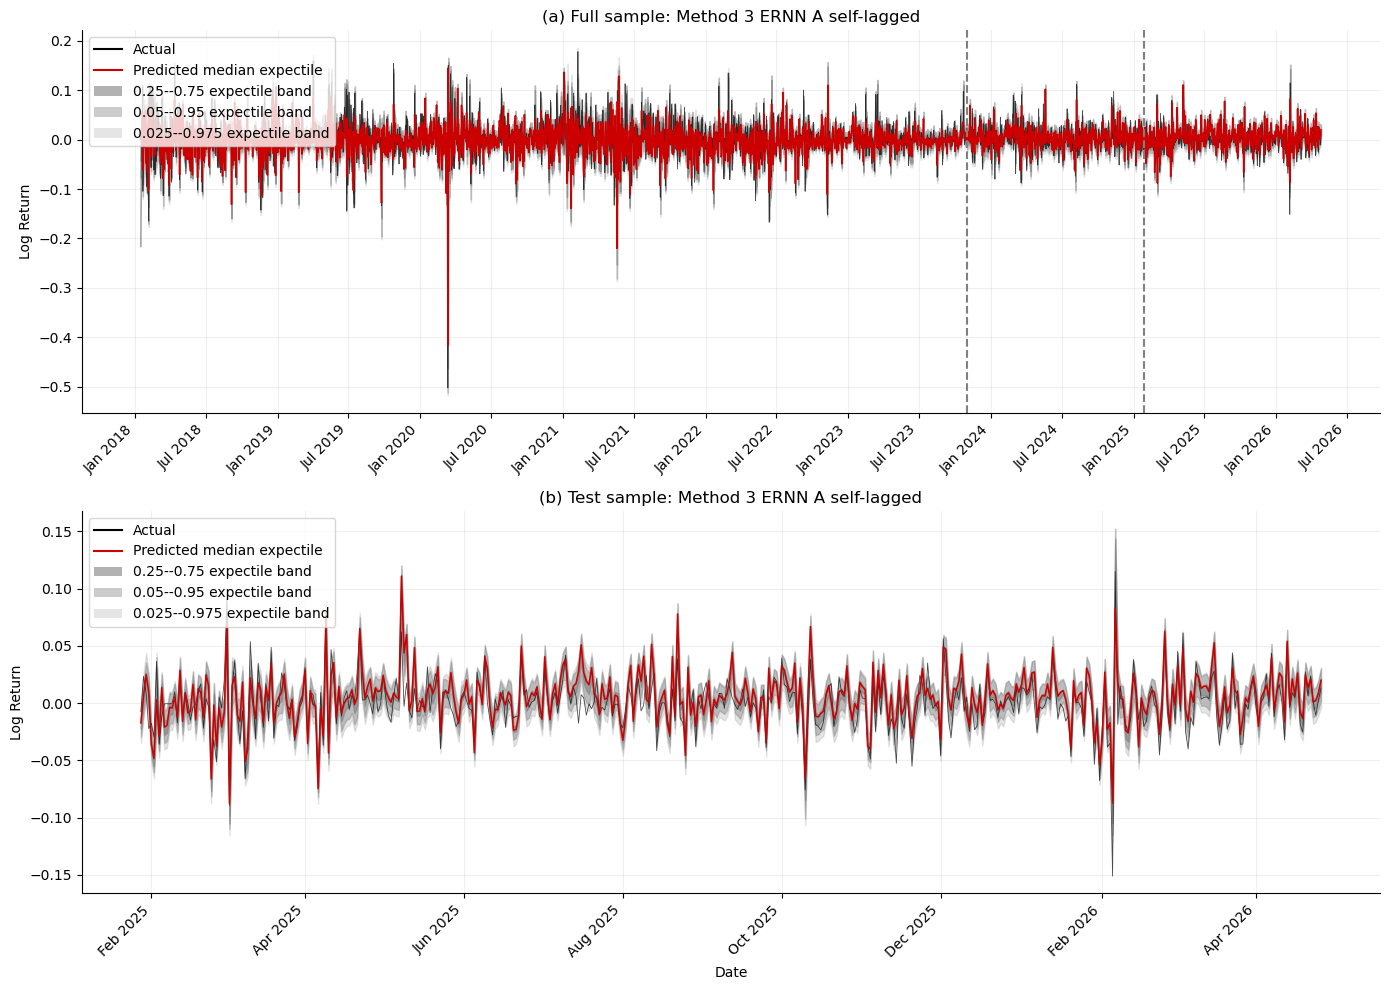


METHOD 3 ERNN A SELF-LAGGED -- TEST RESULTS
               model  test_T  average_nll  average_ase  crossover  tail
Method 3 ERNN A Self     454    -2.759584     0.000049          0     0

Per-level results:
  tau       nll      ase    sigma
0.025 -2.692113 0.000019 0.007296
0.050 -2.681588 0.000033 0.010154
0.250 -2.791220 0.000081 0.015918
0.500 -2.689569 0.000103 0.021794
0.750 -2.841797 0.000068 0.015936
0.950 -2.815447 0.000026 0.008685
0.975 -2.805351 0.000015 0.006693

Learned-spacing diagnostics:
  tau  reference_tau direction  mean_delta  min_delta  max_delta     sd_delta  near_zero_count  near_zero_rate
0.025           0.05     lower    0.005749   0.005748   0.005749 2.917880e-07                0             0.0
0.050           0.25     lower    0.008670   0.004480   0.023185 1.947428e-03                0             0.0
0.250           0.50     lower    0.005585   0.000914   0.025122 2.838615e-03                0             0.0
0.750           0.50     upper    0.002692   

In [29]:
"""Plot and evaluate Method 3 ERNN A self-lagged on the test sample.

Run after the tuning/data-preparation code. Expected notebook objects:
df, train_df, val_df, test_df, feature_cols, X_train and Method3SpacingModel.
"""

from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


LEVELS = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
ORDER = [0.500, 0.750, 0.950, 0.975, 0.250, 0.050, 0.025]
REFERENCE = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050,
}
DIRECTION = {
    0.500: None,
    0.750: "upper",
    0.950: "upper",
    0.975: "upper",
    0.250: "lower",
    0.050: "lower",
    0.025: "lower",
}

RESULT_DIR = Path("method3_spacing_ernn_a_self_results")
MODEL_DIR = RESULT_DIR / "ernn_a_self"
CHECKPOINT_PATH = MODEL_DIR / "method3_spacing_ernn_a_self_best.pt"
PLOT_PATH = MODEL_DIR / "method3_spacing_ernn_a_self.png"
METRICS_PATH = MODEL_DIR / "method3_spacing_ernn_a_self_test_metrics.csv"
SUMMARY_PATH = MODEL_DIR / "method3_spacing_ernn_a_self_test_summary.csv"
DELTA_PATH = MODEL_DIR / "method3_spacing_ernn_a_self_delta_summary.csv"
PREDICTIONS_PATH = MODEL_DIR / "method3_spacing_ernn_a_self_test_predictions.csv"


required_objects = (
    "df", "train_df", "val_df", "test_df", "feature_cols", "X_train"
)
missing = [name for name in required_objects if name not in globals()]
if missing:
    raise NameError("Run the data-preparation cells first. Missing: " + ", ".join(missing))

if "Method3SpacingModel" not in globals():
    from method3_spacing_ernn_a_self_tuning import Method3SpacingModel

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Checkpoint not found: {CHECKPOINT_PATH}. Run the tuning code first."
    )


# ---------------------------------------------------------------------------
# Reload all seven selected level models
# ---------------------------------------------------------------------------

checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
if checkpoint.get("distribution") != "ernn":
    raise ValueError("The checkpoint is not an ERNN checkpoint.")
if checkpoint.get("form") != "a" or checkpoint.get("lag") != "self":
    raise ValueError("The checkpoint is not the ERNN A self-lagged model.")

models = {}
for level in ORDER:
    model = Method3SpacingModel(
        input_dim=X_train.shape[1],
        config=checkpoint["configs"][level],
        distribution="ernn",
        form="a",
        lag="self",
        direction=checkpoint["direction"][level],
    )
    model.load_state_dict(checkpoint["model_state_dicts"][level])
    model.eval()
    models[level] = model


# ---------------------------------------------------------------------------
# Generate full-sample forecasts sequentially from the median outwards
# ---------------------------------------------------------------------------

X_all = torch.tensor(df[feature_cols].values, dtype=torch.float32)
y_all = torch.tensor(df["log_return"].values, dtype=torch.float32)
predictions, deltas, sigmas = {}, {}, {}

for level in ORDER:
    reference_level = REFERENCE[level]
    reference = None if reference_level is None else predictions[reference_level]
    with torch.no_grad():
        prediction, _, _, delta, sigma = models[level](y_all, X_all, reference)
    predictions[level] = prediction.detach()
    deltas[level] = None if delta is None else delta.detach()
    sigmas[level] = sigma.detach()

test_start = len(train_df) + len(val_df)
y_test = y_all[test_start:]
test_dates = test_df.index

if len(y_test) != len(test_dates):
    raise ValueError("The calculated test slice does not match test_df.")


# ---------------------------------------------------------------------------
# Plot full sample and test sample
# ---------------------------------------------------------------------------

prediction_np = {level: predictions[level].cpu().numpy() for level in LEVELS}
actual_np = df["log_return"].to_numpy()


def draw_panel(axis, dates, actual, start=None):
    def values(level):
        series = prediction_np[level]
        return series if start is None else series[start:]

    axis.plot(dates, actual, color="#000000", linewidth=0.6, alpha=0.70)
    axis.plot(dates, values(0.500), color="#CC0000", linewidth=1.1)
    axis.fill_between(dates, values(0.025), values(0.975), color="#808080", alpha=0.20)
    axis.fill_between(dates, values(0.050), values(0.950), color="#808080", alpha=0.40)
    axis.fill_between(dates, values(0.250), values(0.750), color="#808080", alpha=0.60)
    axis.set_ylabel("Log Return")
    axis.grid(True, alpha=0.20)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)


figure, axes = plt.subplots(2, 1, figsize=(14, 10))
draw_panel(axes[0], df.index, actual_np)
axes[0].axvline(train_df.index[-1], color="gray", linestyle="--")
axes[0].axvline(val_df.index[-1], color="gray", linestyle="--")
axes[0].set_title("(a) Full sample: Method 3 ERNN A self-lagged")
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

draw_panel(axes[1], test_dates, test_df["log_return"].to_numpy(), start=test_start)
axes[1].set_title("(b) Test sample: Method 3 ERNN A self-lagged")
axes[1].set_xlabel("Date")
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

legend = [
    Line2D([0], [0], color="#000000", label="Actual"),
    Line2D([0], [0], color="#CC0000", label="Predicted median expectile"),
    Patch(facecolor="#808080", alpha=0.60, label="0.25--0.75 expectile band"),
    Patch(facecolor="#808080", alpha=0.40, label="0.05--0.95 expectile band"),
    Patch(facecolor="#808080", alpha=0.20, label="0.025--0.975 expectile band"),
]
for axis in axes:
    axis.legend(handles=legend, loc="upper left")
    plt.setp(axis.xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# ---------------------------------------------------------------------------
# Test AGD NLL and asymmetric squared error
# ---------------------------------------------------------------------------


def agd_nll(y, expectile, sigma, tau):
    residual = y - expectile
    tau_tensor = torch.tensor(tau, dtype=y.dtype, device=y.device)
    weight = torch.abs(tau_tensor - (residual < 0).to(y.dtype))
    constant = (
        torch.log(
            torch.sqrt(torch.pi / tau_tensor)
            + torch.sqrt(torch.pi / (1.0 - tau_tensor))
        )
        - np.log(2.0)
    )
    return (
        torch.log(sigma)
        + constant
        + weight * residual.square() / sigma.square()
    ).mean()


def asymmetric_squared_error(y, expectile, tau):
    residual = y - expectile
    weight = torch.where(
        residual >= 0,
        torch.full_like(residual, tau),
        torch.full_like(residual, 1.0 - tau),
    )
    return (weight * residual.square()).mean()


metric_rows = []
for level in LEVELS:
    prediction_test = predictions[level][test_start:]
    metric_rows.append({
        "tau": level,
        "nll": agd_nll(y_test, prediction_test, sigmas[level], level).item(),
        "ase": asymmetric_squared_error(y_test, prediction_test, level).item(),
        "sigma": sigmas[level].item(),
    })

metrics_df = pd.DataFrame(metric_rows)
metrics_df.to_csv(METRICS_PATH, index=False)


# ---------------------------------------------------------------------------
# Crossover and learned-spacing diagnostics
# ---------------------------------------------------------------------------

test_matrix = torch.stack(
    [predictions[level][test_start:] for level in LEVELS], dim=1
)
violations = test_matrix[:, :-1] > test_matrix[:, 1:]
pair_counts = violations.sum(dim=0)
total_crossover = int(violations.sum().item())
tail_crossover = int((pair_counts[0] + pair_counts[-1]).item())

delta_rows = []
for level in LEVELS:
    if deltas[level] is None:
        continue
    delta_test = deltas[level][test_start:]
    delta_rows.append({
        "tau": level,
        "reference_tau": REFERENCE[level],
        "direction": DIRECTION[level],
        "mean_delta": delta_test.mean().item(),
        "min_delta": delta_test.min().item(),
        "max_delta": delta_test.max().item(),
        "sd_delta": delta_test.std(unbiased=False).item(),
        "near_zero_count": int((delta_test < 1e-6).sum().item()),
        "near_zero_rate": (delta_test < 1e-6).float().mean().item(),
    })

delta_df = pd.DataFrame(delta_rows)
delta_df.to_csv(DELTA_PATH, index=False)

summary_df = pd.DataFrame([{
    "model": "Method 3 ERNN A Self",
    "test_T": len(y_test),
    "average_nll": metrics_df["nll"].mean(),
    "average_ase": metrics_df["ase"].mean(),
    "crossover": total_crossover,
    "tail": tail_crossover,
}])
summary_df.to_csv(SUMMARY_PATH, index=False)


# ---------------------------------------------------------------------------
# Detailed test predictions and adjacent gaps
# ---------------------------------------------------------------------------

prediction_table = pd.DataFrame({
    "date": test_dates,
    "actual": y_test.cpu().numpy(),
})
for level in LEVELS:
    prediction_table[f"e_{level:.3f}"] = predictions[level][test_start:].cpu().numpy()
for left, right in zip(LEVELS[:-1], LEVELS[1:]):
    prediction_table[f"gap_{left:.3f}_{right:.3f}"] = (
        predictions[right][test_start:] - predictions[left][test_start:]
    ).cpu().numpy()
prediction_table["min_adjacent_gap"] = prediction_table[
    [column for column in prediction_table if column.startswith("gap_")]
].min(axis=1)
prediction_table.to_csv(PREDICTIONS_PATH, index=False)


print("\nMETHOD 3 ERNN A SELF-LAGGED -- TEST RESULTS")
print(summary_df.to_string(index=False))
print("\nPer-level results:")
print(metrics_df.to_string(index=False))
print("\nLearned-spacing diagnostics:")
print(delta_df.to_string(index=False))
print(f"\nPlot saved to: {PLOT_PATH}")
print(f"Detailed predictions saved to: {PREDICTIONS_PATH}")

# Test on more trials - 200 trials to 500 trials for the best model

[I 2026-08-30 16:41:41,237] A new study created in RDB with name: method3_ernn_a_self_median_500



METHOD 3 ERNN A SELF — 500-TRIAL MEDIAN ROBUSTNESS CHECK
Existing stored trials: 0
Remaining trials: 500
Persistent study:
method3_500trial_robustness/ernn_a_self_median/median_500_trials.sqlite3


  0%|          | 0/500 [00:00<?, ?it/s]

[I 2026-08-30 16:42:05,803] Trial 0 finished with value: 0.8025408983230591 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 0.8025408983230591.
[I 2026-08-30 16:42:31,164] Trial 1 finished with value: -0.22750328481197357 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: -0.22750328481197357.
[I 2026-08-30 16:42:34,857] Trial 2 finished with value: 0.8977494239807129 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.37112272198735796, 'layernorm': Tru

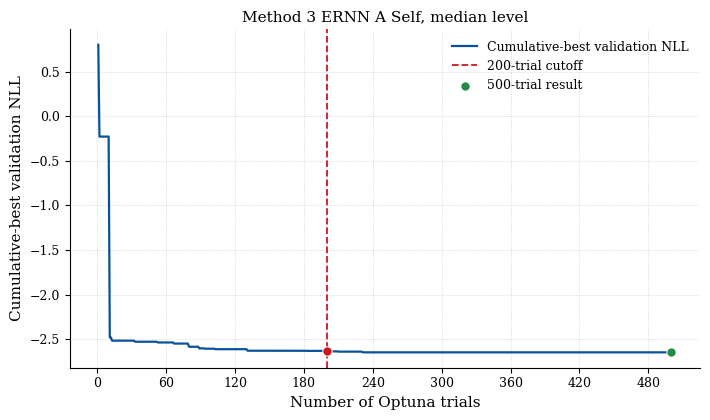


ROBUSTNESS COMPARISON COMPLETED
 budget  valid_trials  best_validation_nll  best_nll_trial  selected_joint_rank_trial  selected_trial_nll  selected_trial_ase  top10_mean_nll  top10_sd_nll  top10_mean_ase  top10_sd_ase  top10_overlap_with_500  runtime_hours  best_nll_improvement_from_200  top10_mean_nll_improvement_from_200
    200           200          -2.63024521             181                        163         -2.62890482          0.00013218     -2.62579648    0.00363126      0.00013405    0.00000100                       0     3.41405455                     0.00000000                           0.00000000
    500           500          -2.64677215             231                        231         -2.64677215          0.00013080     -2.64144039    0.00286474      0.00013174    0.00000053                      10     5.36621664                     0.01652694                           0.01564391

Top-10 overlap: 0/10

Best validation NLL at 200 trials: -2.63024521
Best validation NL

In [25]:
# ============================================================
# METHOD 3 ROBUSTNESS CHECK
# ERNN A SELF — MEDIAN LEVEL 0.500
# FIRST 200 TRIALS VERSUS ALL 500 TRIALS
# ============================================================

from pathlib import Path
import copy
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
from matplotlib.ticker import MaxNLocator
from optuna.samplers import TPESampler


# ------------------------------------------------------------
# 1. Load Method 3 definitions without running original tuning
# ------------------------------------------------------------

required_definitions = [
    "Method3SpacingModel",
    "suggest_config",
    "train_config",
    "evaluate",
    "predict_train_val",
]

missing_definitions = [
    name
    for name in required_definitions
    if name not in globals()
]

if missing_definitions:
    NOTEBOOK_PATH = Path(
        "2026_07_13 - ERNN Hybrid - Self A.ipynb"
    )

    if not NOTEBOOK_PATH.exists():
        raise FileNotFoundError(
            "The ERNN A-Self notebook was not found:\n"
            f"{NOTEBOOK_PATH.resolve()}"
        )

    with open(
        NOTEBOOK_PATH,
        "r",
        encoding="utf-8",
    ) as notebook_file:
        notebook_content = json.load(
            notebook_file
        )

    method3_source = None

    for cell in notebook_content["cells"]:
        source = "".join(
            cell.get("source", [])
        )

        if (
            "Method 3, Specification 1: "
            "Hybrid ERNN A self-lagged"
            in source
            and "class Method3SpacingModel"
            in source
            and "def train_config" in source
            and "def run_one_model" in source
        ):
            method3_source = source
            break

    if method3_source is None:
        raise RuntimeError(
            "The Method 3 ERNN A-Self definition "
            "cell could not be found."
        )

    # Remove only the call that starts the original full model.
    method3_source = method3_source.rsplit(
        'if __name__ == "__main__":',
        1,
    )[0]

    exec(
        method3_source,
        globals(),
    )

    print(
        "Method 3 definitions loaded. "
        "Original Optuna tuning was not run."
    )


# ------------------------------------------------------------
# 2. Verify prepared data
# ------------------------------------------------------------

required_data = [
    "y_train",
    "X_train",
    "y_val",
    "X_val",
]

missing_data = [
    name
    for name in required_data
    if name not in globals()
]

if missing_data:
    raise RuntimeError(
        "The following data objects are unavailable:\n"
        + ", ".join(missing_data)
        + "\nRun the notebook data-preparation cells first."
    )


# ------------------------------------------------------------
# 3. Experiment settings
# ------------------------------------------------------------

ROBUSTNESS_LEVEL = 0.500
ROBUSTNESS_DIRECTION = None
ROBUSTNESS_SPEC = (
    "ernn",
    "a",
    "self",
)

ROBUSTNESS_SEED = 2026
BUDGET_200 = 200
BUDGET_500 = 500

ROBUSTNESS_DIR = (
    Path("method3_500trial_robustness")
    / "ernn_a_self_median"
)

ROBUSTNESS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

STUDY_PATH = (
    ROBUSTNESS_DIR
    / "median_500_trials.sqlite3"
)

ALL_TRIALS_PATH = (
    ROBUSTNESS_DIR
    / "ranking_all_500_trials.csv"
)

TOP10_200_PATH = (
    ROBUSTNESS_DIR
    / "top10_first_200_trials.csv"
)

TOP10_500_PATH = (
    ROBUSTNESS_DIR
    / "top10_all_500_trials.csv"
)

COMPARISON_PATH = (
    ROBUSTNESS_DIR
    / "comparison_200_vs_500.csv"
)

PLOT_PATH = (
    ROBUSTNESS_DIR
    / "cumulative_best_validation_nll.png"
)

BEST_MODEL_PATH = (
    ROBUSTNESS_DIR
    / "best_500_trial_median.pt"
)

STUDY_NAME = (
    "method3_ernn_a_self_median_500"
)


# ------------------------------------------------------------
# 4. Create a persistent, resumable Optuna study
# ------------------------------------------------------------

storage_url = (
    f"sqlite:///{STUDY_PATH.resolve()}"
)

study = optuna.create_study(
    study_name=STUDY_NAME,
    direction="minimize",
    sampler=TPESampler(
        seed=ROBUSTNESS_SEED
    ),
    storage=storage_url,
    load_if_exists=True,
)

existing_trials = len(
    study.trials
)

remaining_trials = max(
    0,
    BUDGET_500 - existing_trials,
)

print("\n" + "=" * 72)

print(
    "METHOD 3 ERNN A SELF — "
    "500-TRIAL MEDIAN ROBUSTNESS CHECK"
)

print("=" * 72)

print(
    f"Existing stored trials: "
    f"{existing_trials}"
)

print(
    f"Remaining trials: "
    f"{remaining_trials}"
)

print(
    f"Persistent study:\n"
    f"{STUDY_PATH}"
)


# ------------------------------------------------------------
# 5. Define the median-level objective
# ------------------------------------------------------------

def robustness_objective(trial):
    config = suggest_config(
        trial
    )

    model = train_config(
        spec=ROBUSTNESS_SPEC,
        config=config,
        level=ROBUSTNESS_LEVEL,
        direction=ROBUSTNESS_DIRECTION,
        q_ref_train=None,
        q_ref_val=None,
        seed=ROBUSTNESS_SEED,
    )

    if model is None:
        return float("inf")

    trial_metrics = evaluate(
        model=model,
        level=ROBUSTNESS_LEVEL,
        direction=ROBUSTNESS_DIRECTION,
        q_ref_train=None,
        q_ref_val=None,
    )

    for name, value in (
        trial_metrics.items()
    ):
        if value is None:
            continue

        try:
            trial.set_user_attr(
                name,
                float(value),
            )
        except (TypeError, ValueError):
            trial.set_user_attr(
                name,
                value,
            )

    return float(
        trial_metrics["nll"]
    )


# ------------------------------------------------------------
# 6. Run only the missing trials
# ------------------------------------------------------------

if remaining_trials > 0:
    start_time = time.time()

    study.optimize(
        robustness_objective,
        n_trials=remaining_trials,
        show_progress_bar=True,
        gc_after_trial=True,
    )

    elapsed_seconds = (
        time.time() - start_time
    )

    print(
        f"\nNew trials completed in "
        f"{elapsed_seconds / 3600:.2f} hours."
    )

else:
    print(
        "\nThe persistent study already contains "
        "500 trials. No tuning was repeated."
    )


# ------------------------------------------------------------
# 7. Extract valid completed trials
# ------------------------------------------------------------

valid_trials = []

for trial in study.trials:
    is_complete = (
        trial.state
        == optuna.trial.TrialState.COMPLETE
    )

    has_finite_value = (
        trial.value is not None
        and np.isfinite(
            float(trial.value)
        )
    )

    has_metrics = (
        "nll" in trial.user_attrs
        and "calibration_penalty"
        in trial.user_attrs
        and "ase" in trial.user_attrs
    )

    if (
        is_complete
        and has_finite_value
        and has_metrics
    ):
        valid_trials.append(trial)

if not valid_trials:
    raise RuntimeError(
        "No valid completed trials were found."
    )

print(
    f"\nValid completed trials: "
    f"{len(valid_trials)}"
)


# ------------------------------------------------------------
# 8. Create rankings separately at each budget
# ------------------------------------------------------------

def build_budget_ranking(
    trials,
    budget,
):
    budget_trials = [
        trial
        for trial in trials
        if trial.number < budget
    ]

    if not budget_trials:
        raise RuntimeError(
            f"No valid trials found within "
            f"the first {budget} trials."
        )

    rank_nll = {
        trial.number: rank
        for rank, trial in enumerate(
            sorted(
                budget_trials,
                key=lambda item: (
                    float(
                        item.user_attrs["nll"]
                    ),
                    item.number,
                ),
            ),
            start=1,
        )
    }

    rank_calibration = {
        trial.number: rank
        for rank, trial in enumerate(
            sorted(
                budget_trials,
                key=lambda item: (
                    float(
                        item.user_attrs[
                            "calibration_penalty"
                        ]
                    ),
                    item.number,
                ),
            ),
            start=1,
        )
    }

    records = []

    for trial in budget_trials:
        duration_seconds = np.nan

        if (
            trial.datetime_start is not None
            and trial.datetime_complete
            is not None
        ):
            duration_seconds = (
                trial.datetime_complete
                - trial.datetime_start
            ).total_seconds()

        record = {
            "budget": budget,
            "trial": trial.number,
            "objective_value": float(
                trial.value
            ),
            "nll": float(
                trial.user_attrs["nll"]
            ),
            "ase": float(
                trial.user_attrs["ase"]
            ),
            "calibration_penalty": float(
                trial.user_attrs[
                    "calibration_penalty"
                ]
            ),
            "rank_nll": rank_nll[
                trial.number
            ],
            "rank_calibration": (
                rank_calibration[
                    trial.number
                ]
            ),
            "sum_rank": (
                rank_nll[trial.number]
                + rank_calibration[
                    trial.number
                ]
            ),
            "duration_seconds": (
                duration_seconds
            ),
        }

        # Retain evaluation attributes
        for name, value in (
            trial.user_attrs.items()
        ):
            if name not in record:
                record[name] = value

        # Retain all architecture parameters
        for name, value in (
            trial.params.items()
        ):
            record[name] = value

        records.append(record)

    ranking = pd.DataFrame(
        records
    )

    ranking = (
        ranking
        .sort_values(
            [
                "sum_rank",
                "nll",
                "calibration_penalty",
                "trial",
            ]
        )
        .reset_index(drop=True)
    )

    return ranking


ranking_200 = build_budget_ranking(
    valid_trials,
    BUDGET_200,
)

ranking_500 = build_budget_ranking(
    valid_trials,
    BUDGET_500,
)

top10_200 = ranking_200.head(
    10
).copy()

top10_500 = ranking_500.head(
    10
).copy()

top10_200.to_csv(
    TOP10_200_PATH,
    index=False,
)

top10_500.to_csv(
    TOP10_500_PATH,
    index=False,
)

ranking_500.to_csv(
    ALL_TRIALS_PATH,
    index=False,
)


# ------------------------------------------------------------
# 9. Compare the 200- and 500-trial results
# ------------------------------------------------------------

top10_200_trials = set(
    top10_200["trial"].astype(int)
)

top10_500_trials = set(
    top10_500["trial"].astype(int)
)

top10_overlap = len(
    top10_200_trials.intersection(
        top10_500_trials
    )
)

best_nll_200_row = ranking_200.loc[
    ranking_200["nll"].idxmin()
]

best_nll_500_row = ranking_500.loc[
    ranking_500["nll"].idxmin()
]

selected_200 = ranking_200.iloc[0]
selected_500 = ranking_500.iloc[0]


def total_runtime_hours(ranking):
    durations = pd.to_numeric(
        ranking["duration_seconds"],
        errors="coerce",
    )

    return float(
        durations.sum(skipna=True)
        / 3600
    )


comparison_df = pd.DataFrame(
    [
        {
            "budget": 200,
            "valid_trials": len(
                ranking_200
            ),
            "best_validation_nll": float(
                best_nll_200_row["nll"]
            ),
            "best_nll_trial": int(
                best_nll_200_row["trial"]
            ),
            "selected_joint_rank_trial": int(
                selected_200["trial"]
            ),
            "selected_trial_nll": float(
                selected_200["nll"]
            ),
            "selected_trial_ase": float(
                selected_200["ase"]
            ),
            "top10_mean_nll": float(
                top10_200["nll"].mean()
            ),
            "top10_sd_nll": float(
                top10_200["nll"].std()
            ),
            "top10_mean_ase": float(
                top10_200["ase"].mean()
            ),
            "top10_sd_ase": float(
                top10_200["ase"].std()
            ),
            "top10_overlap_with_500": (
                top10_overlap
            ),
            "runtime_hours": (
                total_runtime_hours(
                    ranking_200
                )
            ),
        },
        {
            "budget": 500,
            "valid_trials": len(
                ranking_500
            ),
            "best_validation_nll": float(
                best_nll_500_row["nll"]
            ),
            "best_nll_trial": int(
                best_nll_500_row["trial"]
            ),
            "selected_joint_rank_trial": int(
                selected_500["trial"]
            ),
            "selected_trial_nll": float(
                selected_500["nll"]
            ),
            "selected_trial_ase": float(
                selected_500["ase"]
            ),
            "top10_mean_nll": float(
                top10_500["nll"].mean()
            ),
            "top10_sd_nll": float(
                top10_500["nll"].std()
            ),
            "top10_mean_ase": float(
                top10_500["ase"].mean()
            ),
            "top10_sd_ase": float(
                top10_500["ase"].std()
            ),
            "top10_overlap_with_500": (
                10
            ),
            "runtime_hours": (
                total_runtime_hours(
                    ranking_500
                )
            ),
        },
    ]
)

comparison_df[
    "best_nll_improvement_from_200"
] = (
    comparison_df.loc[
        comparison_df["budget"] == 200,
        "best_validation_nll",
    ].iloc[0]
    - comparison_df[
        "best_validation_nll"
    ]
)

comparison_df[
    "top10_mean_nll_improvement_from_200"
] = (
    comparison_df.loc[
        comparison_df["budget"] == 200,
        "top10_mean_nll",
    ].iloc[0]
    - comparison_df[
        "top10_mean_nll"
    ]
)

comparison_df.to_csv(
    COMPARISON_PATH,
    index=False,
)


# ------------------------------------------------------------
# 10. Cumulative-best validation NLL curve
# ------------------------------------------------------------

trial_history = []

for trial in valid_trials:
    if trial.number >= BUDGET_500:
        continue

    trial_history.append(
        {
            "trial": int(
                trial.number
            ),
            "nll": float(
                trial.user_attrs["nll"]
            ),
        }
    )

history_df = (
    pd.DataFrame(trial_history)
    .sort_values("trial")
    .reset_index(drop=True)
)

history_df[
    "cumulative_best_nll"
] = history_df[
    "nll"
].cummin()

plt.rcParams.update(
    {
        "font.family": "serif",
        "mathtext.fontset": "stix",
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 11,
        "legend.fontsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 0.8,
    }
)

figure, axis = plt.subplots(
    figsize=(7.2, 4.3)
)

axis.plot(
    history_df["trial"] + 1,
    history_df[
        "cumulative_best_nll"
    ],
    color="#08519C",
    linewidth=1.6,
    label="Cumulative-best validation NLL",
)

axis.axvline(
    BUDGET_200,
    color="#CB181D",
    linestyle="--",
    linewidth=1.3,
    label="200-trial cutoff",
)

axis.scatter(
    BUDGET_200,
    float(
        best_nll_200_row["nll"]
    ),
    color="#CB181D",
    edgecolor="white",
    linewidth=0.7,
    s=45,
    zorder=5,
)

axis.scatter(
    BUDGET_500,
    float(
        best_nll_500_row["nll"]
    ),
    color="#238B45",
    edgecolor="white",
    linewidth=0.7,
    s=45,
    zorder=5,
    label="500-trial result",
)

axis.set_xlabel(
    "Number of Optuna trials"
)

axis.set_ylabel(
    "Cumulative-best validation NLL"
)

axis.set_title(
    "Method 3 ERNN A Self, median level"
)

axis.xaxis.set_major_locator(
    MaxNLocator(integer=True)
)

axis.spines["top"].set_visible(False)
axis.spines["right"].set_visible(False)

axis.grid(
    linestyle=":",
    linewidth=0.6,
    alpha=0.6,
)

axis.legend(
    frameon=False,
    loc="best",
)

figure.tight_layout()

figure.savefig(
    PLOT_PATH,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()
plt.close(figure)


# ------------------------------------------------------------
# 11. Refit and save the selected 500-trial model
# ------------------------------------------------------------

selected_trial_number = int(
    selected_500["trial"]
)

trial_lookup = {
    trial.number: trial
    for trial in valid_trials
}

selected_trial_object = (
    trial_lookup[
        selected_trial_number
    ]
)

selected_config = (
    selected_trial_object.params.copy()
)

selected_model = train_config(
    spec=ROBUSTNESS_SPEC,
    config=selected_config,
    level=ROBUSTNESS_LEVEL,
    direction=None,
    q_ref_train=None,
    q_ref_val=None,
    seed=ROBUSTNESS_SEED,
)

if selected_model is None:
    raise RuntimeError(
        "The selected 500-trial median model "
        "failed during final refitting."
    )

selected_metrics = evaluate(
    model=selected_model,
    level=ROBUSTNESS_LEVEL,
    direction=None,
    q_ref_train=None,
    q_ref_val=None,
)

torch.save(
    {
        "model": (
            "Method 3 ERNN A Self median"
        ),
        "level": ROBUSTNESS_LEVEL,
        "budget": BUDGET_500,
        "seed": ROBUSTNESS_SEED,
        "selected_trial": (
            selected_trial_number
        ),
        "config": selected_config,
        "metrics": selected_metrics,
        "model_state_dict": (
            copy.deepcopy(
                selected_model.state_dict()
            )
        ),
    },
    BEST_MODEL_PATH,
)


# ------------------------------------------------------------
# 12. Final report
# ------------------------------------------------------------

print("\n" + "=" * 72)

print(
    "ROBUSTNESS COMPARISON COMPLETED"
)

print("=" * 72)

print(
    comparison_df.to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.8f}"
        ),
    )
)

print(
    f"\nTop-10 overlap: "
    f"{top10_overlap}/10"
)

print(
    f"\nBest validation NLL at 200 trials: "
    f"{float(best_nll_200_row['nll']):.8f}"
)

print(
    f"Best validation NLL at 500 trials: "
    f"{float(best_nll_500_row['nll']):.8f}"
)

print(
    f"\nSelected 500-trial model: "
    f"trial #{selected_trial_number}"
)

print(
    f"\nResults saved under:\n"
    f"{ROBUSTNESS_DIR}"
)

print(
    f"\nComparison table:\n"
    f"{COMPARISON_PATH}"
)

print(
    f"\nCumulative-best plot:\n"
    f"{PLOT_PATH}"
)

print(
    f"\nSelected model:\n"
    f"{BEST_MODEL_PATH}"
)

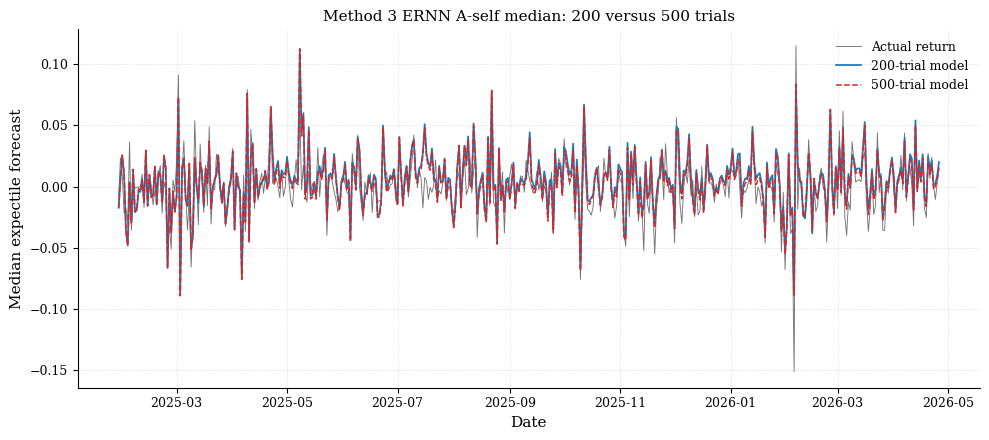


METHOD 3 ERNN A-SELF MEDIAN
TEST COMPARISON: 200 VS 500 TRIALS
 budget  selected_trial    test_nll   test_ase      sigma  nll_improvement_vs_200  ase_improvement_vs_200
    200             163 -2.68956947 0.00010336 0.02179392              0.00000000              0.00000000
    500             231 -2.73790526 0.00009043 0.02104726              0.04833579              0.00001293

Forecast similarity diagnostics:
Mean absolute forecast difference: 0.00206988
Maximum absolute forecast difference: 0.00603657
Forecast correlation: 0.997620

Comparison saved to:
method3_500trial_robustness/ernn_a_self_median/test_comparison_200_vs_500.csv

Predictions saved to:
method3_500trial_robustness/ernn_a_self_median/test_predictions_200_vs_500.csv

Plot saved to:
method3_500trial_robustness/ernn_a_self_median/test_forecast_comparison_200_vs_500.png


In [27]:
# ============================================================
# METHOD 3 ERNN A-SELF
# TEST COMPARISON: 200 TRIALS VS 500 TRIALS
# MEDIAN LEVEL tau = 0.500
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch


# ------------------------------------------------------------
# 1. Check required notebook objects
# ------------------------------------------------------------

required_objects = [
    "df",
    "train_df",
    "val_df",
    "test_df",
    "feature_cols",
    "X_train",
    "Method3SpacingModel",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Missing notebook objects:\n"
        + ", ".join(missing_objects)
        + "\nRun the data-preparation and Method 3 "
          "definition cells first."
    )


# ------------------------------------------------------------
# 2. Settings and saved checkpoints
# ------------------------------------------------------------

TAU = 0.500

CHECKPOINT_200_PATH = Path(
    "method3_spacing_ernn_a_self_results"
) / "ernn_a_self" / (
    "method3_spacing_ernn_a_self_best.pt"
)

CHECKPOINT_500_PATH = Path(
    "method3_500trial_robustness"
) / "ernn_a_self_median" / (
    "best_500_trial_median.pt"
)

OUTPUT_DIR = (
    Path("method3_500trial_robustness")
    / "ernn_a_self_median"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

COMPARISON_PATH = (
    OUTPUT_DIR
    / "test_comparison_200_vs_500.csv"
)

PREDICTIONS_PATH = (
    OUTPUT_DIR
    / "test_predictions_200_vs_500.csv"
)

PLOT_PATH = (
    OUTPUT_DIR
    / "test_forecast_comparison_200_vs_500.png"
)

for checkpoint_path in [
    CHECKPOINT_200_PATH,
    CHECKPOINT_500_PATH,
]:
    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"Checkpoint not found:\n{checkpoint_path.resolve()}"
        )


# ------------------------------------------------------------
# 3. Load the 200-trial median model
# ------------------------------------------------------------

checkpoint_200 = torch.load(
    CHECKPOINT_200_PATH,
    map_location="cpu",
    weights_only=False,
)

# Allow either float or string level keys
if TAU in checkpoint_200["configs"]:
    median_key = TAU
elif str(TAU) in checkpoint_200["configs"]:
    median_key = str(TAU)
else:
    raise KeyError(
        "The median level was not found in the "
        "original Method 3 checkpoint."
    )

direction_200 = checkpoint_200[
    "direction"
][median_key]

model_200 = Method3SpacingModel(
    input_dim=X_train.shape[1],
    config=checkpoint_200[
        "configs"
    ][median_key],
    distribution="ernn",
    form="a",
    lag="self",
    direction=direction_200,
)

model_200.load_state_dict(
    checkpoint_200[
        "model_state_dicts"
    ][median_key]
)

model_200.eval()


# ------------------------------------------------------------
# 4. Load the 500-trial median model
# ------------------------------------------------------------

checkpoint_500 = torch.load(
    CHECKPOINT_500_PATH,
    map_location="cpu",
    weights_only=False,
)

model_500 = Method3SpacingModel(
    input_dim=X_train.shape[1],
    config=checkpoint_500["config"],
    distribution="ernn",
    form="a",
    lag="self",
    direction=None,
)

model_500.load_state_dict(
    checkpoint_500["model_state_dict"]
)

model_500.eval()


# ------------------------------------------------------------
# 5. Generate full-sample one-step-ahead forecasts
# ------------------------------------------------------------

X_all = torch.tensor(
    df[feature_cols].values,
    dtype=torch.float32,
)

y_all = torch.tensor(
    df["log_return"].values,
    dtype=torch.float32,
)

with torch.no_grad():
    (
        prediction_200,
        _,
        _,
        _,
        sigma_200,
    ) = model_200(
        y_all,
        X_all,
        None,
    )

    (
        prediction_500,
        _,
        _,
        _,
        sigma_500,
    ) = model_500(
        y_all,
        X_all,
        None,
    )

test_start = (
    len(train_df)
    + len(val_df)
)

y_test = y_all[test_start:]

prediction_200_test = (
    prediction_200[test_start:]
)

prediction_500_test = (
    prediction_500[test_start:]
)

test_dates = test_df.index

if not (
    len(y_test)
    == len(prediction_200_test)
    == len(prediction_500_test)
    == len(test_dates)
):
    raise ValueError(
        "The test-sample lengths do not match."
    )


# ------------------------------------------------------------
# 6. Metric functions
# ------------------------------------------------------------

def agd_nll(
    actual,
    expectile,
    sigma,
    tau,
):
    residual = actual - expectile

    tau_tensor = torch.tensor(
        tau,
        dtype=actual.dtype,
        device=actual.device,
    )

    weight = torch.abs(
        tau_tensor
        - (residual < 0).to(actual.dtype)
    )

    constant = (
        torch.log(
            torch.sqrt(
                torch.pi / tau_tensor
            )
            + torch.sqrt(
                torch.pi
                / (1.0 - tau_tensor)
            )
        )
        - np.log(2.0)
    )

    return (
        torch.log(sigma)
        + constant
        + weight
        * residual.square()
        / sigma.square()
    ).mean()


def asymmetric_squared_error(
    actual,
    expectile,
    tau,
):
    residual = actual - expectile

    weight = torch.where(
        residual >= 0,
        torch.full_like(
            residual,
            tau,
        ),
        torch.full_like(
            residual,
            1.0 - tau,
        ),
    )

    return (
        weight
        * residual.square()
    ).mean()


# ------------------------------------------------------------
# 7. Calculate test results
# ------------------------------------------------------------

nll_200 = agd_nll(
    y_test,
    prediction_200_test,
    sigma_200,
    TAU,
).item()

nll_500 = agd_nll(
    y_test,
    prediction_500_test,
    sigma_500,
    TAU,
).item()

ase_200 = asymmetric_squared_error(
    y_test,
    prediction_200_test,
    TAU,
).item()

ase_500 = asymmetric_squared_error(
    y_test,
    prediction_500_test,
    TAU,
).item()

forecast_difference = (
    prediction_500_test
    - prediction_200_test
)

mean_absolute_forecast_difference = (
    forecast_difference
    .abs()
    .mean()
    .item()
)

maximum_absolute_forecast_difference = (
    forecast_difference
    .abs()
    .max()
    .item()
)

forecast_correlation = np.corrcoef(
    prediction_200_test.cpu().numpy(),
    prediction_500_test.cpu().numpy(),
)[0, 1]


comparison_df = pd.DataFrame([
    {
        "budget": 200,
        "selected_trial": 163,
        "test_nll": nll_200,
        "test_ase": ase_200,
        "sigma": sigma_200.item(),
    },
    {
        "budget": 500,
        "selected_trial": int(
            checkpoint_500[
                "selected_trial"
            ]
        ),
        "test_nll": nll_500,
        "test_ase": ase_500,
        "sigma": sigma_500.item(),
    },
])

comparison_df[
    "nll_improvement_vs_200"
] = (
    nll_200
    - comparison_df["test_nll"]
)

comparison_df[
    "ase_improvement_vs_200"
] = (
    ase_200
    - comparison_df["test_ase"]
)

comparison_df.to_csv(
    COMPARISON_PATH,
    index=False,
)


# ------------------------------------------------------------
# 8. Save detailed forecasts
# ------------------------------------------------------------

prediction_df = pd.DataFrame({
    "date": test_dates,
    "actual": y_test.cpu().numpy(),
    "expectile_200_trials": (
        prediction_200_test
        .cpu()
        .numpy()
    ),
    "expectile_500_trials": (
        prediction_500_test
        .cpu()
        .numpy()
    ),
    "forecast_difference_500_minus_200": (
        forecast_difference
        .cpu()
        .numpy()
    ),
})

prediction_df.to_csv(
    PREDICTIONS_PATH,
    index=False,
)


# ------------------------------------------------------------
# 9. Plot the two test forecasts
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 4.5)
)

ax.plot(
    test_dates,
    y_test.cpu().numpy(),
    color="black",
    linewidth=0.65,
    alpha=0.55,
    label="Actual return",
)

ax.plot(
    test_dates,
    prediction_200_test.cpu().numpy(),
    color="#1f77b4",
    linewidth=1.25,
    label="200-trial model",
)

ax.plot(
    test_dates,
    prediction_500_test.cpu().numpy(),
    color="#d62728",
    linewidth=1.1,
    linestyle="--",
    label="500-trial model",
)

ax.set_title(
    "Method 3 ERNN A-self median: "
    "200 versus 500 trials"
)

ax.set_xlabel("Date")
ax.set_ylabel("Median expectile forecast")

ax.grid(
    True,
    linestyle=":",
    linewidth=0.6,
    alpha=0.5,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    fontsize=9,
)

fig.tight_layout()

fig.savefig(
    PLOT_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)


# ------------------------------------------------------------
# 10. Report
# ------------------------------------------------------------

print(
    "\nMETHOD 3 ERNN A-SELF MEDIAN"
    "\nTEST COMPARISON: 200 VS 500 TRIALS"
)

print("=" * 68)

print(
    comparison_df.to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.8f}"
        ),
    )
)

print(
    "\nForecast similarity diagnostics:"
)

print(
    "Mean absolute forecast difference: "
    f"{mean_absolute_forecast_difference:.8f}"
)

print(
    "Maximum absolute forecast difference: "
    f"{maximum_absolute_forecast_difference:.8f}"
)

print(
    "Forecast correlation: "
    f"{forecast_correlation:.6f}"
)

print(
    f"\nComparison saved to:\n"
    f"{COMPARISON_PATH}"
)

print(
    f"\nPredictions saved to:\n"
    f"{PREDICTIONS_PATH}"
)

print(
    f"\nPlot saved to:\n"
    f"{PLOT_PATH}"
)

# Conversion - method3

All Method 3 definitions and data objects are ready.

Top 10 retained configurations:
 trial  sum_rank       nll  calibration_penalty
   167         8 -2.523085             0.000028
   134         9 -2.523497             0.000028
   118        11 -2.522621             0.000028
   138        16 -2.523242             0.000028
   195        20 -2.522793             0.000028
   116        20 -2.522269             0.000028
   121        20 -2.522226             0.000028
    55        23 -2.522478             0.000028
   192        26 -2.521152             0.000028
   137        27 -2.522445             0.000028

Fixed Method 3 reference reconstructed: level=0.050

METHOD 3 ERNN A SELF CONVERSION
Target quantile alpha: 0.025
Candidate tau interval: [0.001, 0.050]
Tau points: 100
Architectures: 10
Total required fits: 1000

Tau 1/100: 0.001000
  Trial 167: coverage=0.015453
  Saved progress: 1/1000
  Trial 134: coverage=0.008830
  Saved progress: 2/1000
  Trial 118: coverage=0.006623
  Saved 

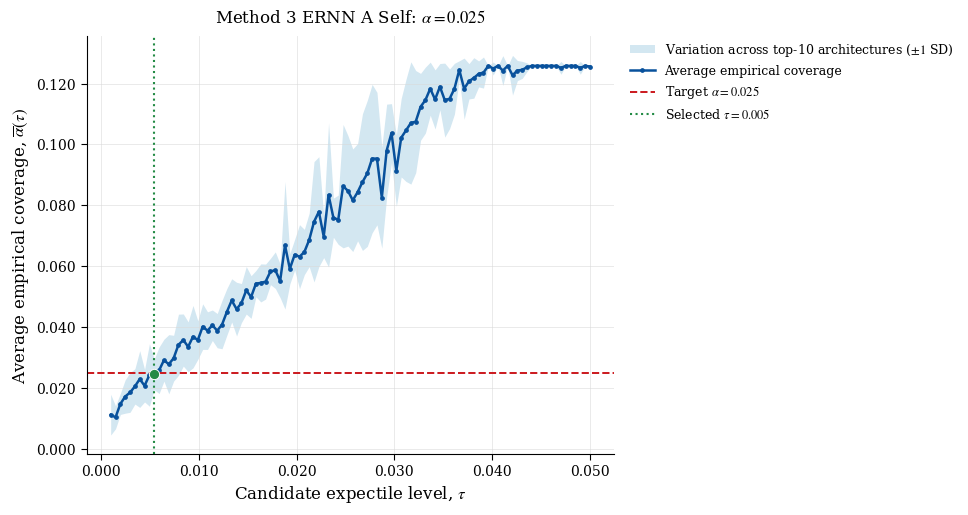


METHOD 3 ERNN A SELF CONVERSION COMPLETED
Target quantile alpha: 0.025
Selected expectile tau: 0.00545455
Average coverage: 0.02450331
Absolute coverage error: 0.00049669
Across-architecture SD: 0.00503926

Plot saved to:
method3_spacing_ernn_a_self_results/ernn_a_self/conversion/conversion_alpha_0.025_100points_paper.png

Summary saved to:
method3_spacing_ernn_a_self_results/ernn_a_self/conversion/conversion_alpha_0.025_100points_summary.csv

Estimated tau saved to:
method3_spacing_ernn_a_self_results/ernn_a_self/conversion/conversion_alpha_0.025_100points_estimated_tau.csv


In [24]:
# ============================================================
# METHOD 3 ERNN A SELF
# EXPECTILE-TO-QUANTILE CONVERSION: TARGET alpha = 0.025
# 100 tau values x top 10 architectures
# ============================================================

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.ticker import FormatStrFormatter


# ------------------------------------------------------------
# 1. Load Method 3 definitions without rerunning Optuna
# ------------------------------------------------------------

required_definitions = [
    "Method3SpacingModel",
    "train_config",
    "predict_train_val",
    "single_level_nll",
    "ernn_calibration",
    "ESTIMATION_ORDER",
    "REFERENCE_LEVEL",
    "DIRECTION",
]

missing_definitions = [
    name
    for name in required_definitions
    if name not in globals()
]

if missing_definitions:
    NOTEBOOK_PATH = Path(
        "2026_07_13 - ERNN Hybrid - Self A.ipynb"
    )

    if not NOTEBOOK_PATH.exists():
        raise FileNotFoundError(
            "The A-Self notebook could not be found:\n"
            f"{NOTEBOOK_PATH.resolve()}"
        )

    with open(
        NOTEBOOK_PATH,
        "r",
        encoding="utf-8",
    ) as notebook_file:
        notebook_content = json.load(
            notebook_file
        )

    method3_source = None

    for cell in notebook_content["cells"]:
        source = "".join(
            cell.get("source", [])
        )

        if (
            "Method 3, Specification 1: "
            "Hybrid ERNN A self-lagged"
            in source
            and "class Method3SpacingModel"
            in source
            and "def train_config" in source
            and "def run_one_model" in source
        ):
            method3_source = source
            break

    if method3_source is None:
        raise RuntimeError(
            "The Method 3 ERNN A-Self definition "
            "cell could not be located."
        )

    # Remove only the command that launches Optuna.
    method3_source = method3_source.rsplit(
        'if __name__ == "__main__":',
        1,
    )[0]

    exec(
        method3_source,
        globals(),
    )

    print(
        "Method 3 ERNN A-Self definitions loaded. "
        "Optuna was not rerun."
    )


# ------------------------------------------------------------
# 2. Verify data-preparation objects
# ------------------------------------------------------------

required_data = [
    "y_train",
    "X_train",
    "y_val",
    "X_val",
]

missing_data = [
    name
    for name in required_data
    if name not in globals()
]

if missing_data:
    raise RuntimeError(
        "The following data objects are unavailable:\n"
        + ", ".join(missing_data)
        + "\nRun the data-preparation cells first."
    )

still_missing = [
    name
    for name in required_definitions
    if name not in globals()
]

if still_missing:
    raise RuntimeError(
        "Definitions remain unavailable:\n"
        + ", ".join(still_missing)
    )

print(
    "All Method 3 definitions and data objects "
    "are ready."
)


# ------------------------------------------------------------
# 3. Conversion settings
# ------------------------------------------------------------

TARGET_ALPHA = 0.025
TARGET_LEVEL = 0.025
TARGET_DIRECTION = "lower"
REFERENCE_LEVEL_FOR_TARGET = 0.050

TAU_LOWER = 0.001
TAU_UPPER = 0.050
N_TAU_POINTS = 100
N_ARCHITECTURES = 10
CONVERSION_SEED = 2032

TAU_GRID = np.round(
    np.linspace(
        TAU_LOWER,
        TAU_UPPER,
        N_TAU_POINTS,
    ),
    12,
)


# ------------------------------------------------------------
# 4. Output paths
# ------------------------------------------------------------

MODEL_DIR = (
    Path("method3_spacing_ernn_a_self_results")
    / "ernn_a_self"
)

CHECKPOINT_PATH = (
    MODEL_DIR
    / "method3_spacing_ernn_a_self_best.pt"
)

RANKING_PATH = (
    MODEL_DIR
    / f"ranking_level_{TARGET_LEVEL:.3f}.csv"
)

CONVERSION_DIR = MODEL_DIR / "conversion"

CONVERSION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

LEVEL_TAG = f"{TARGET_ALPHA:.3f}"

RAW_RESULTS_PATH = (
    CONVERSION_DIR
    / (
        f"conversion_alpha_{LEVEL_TAG}_"
        f"100points_raw.csv"
    )
)

SUMMARY_PATH = (
    CONVERSION_DIR
    / (
        f"conversion_alpha_{LEVEL_TAG}_"
        f"100points_summary.csv"
    )
)

ESTIMATE_PATH = (
    CONVERSION_DIR
    / (
        f"conversion_alpha_{LEVEL_TAG}_"
        f"100points_estimated_tau.csv"
    )
)

PLOT_PATH = (
    CONVERSION_DIR
    / (
        f"conversion_alpha_{LEVEL_TAG}_"
        f"100points_paper.png"
    )
)

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Checkpoint not found:\n"
        f"{CHECKPOINT_PATH}"
    )

if not RANKING_PATH.exists():
    raise FileNotFoundError(
        f"Ranking CSV not found:\n"
        f"{RANKING_PATH}"
    )


# ------------------------------------------------------------
# 5. Retrieve the top 10 architectures
# ------------------------------------------------------------

ranking_df = pd.read_csv(
    RANKING_PATH
)

ranking_df = (
    ranking_df
    .sort_values(
        [
            "sum_rank",
            "nll",
            "calibration_penalty",
        ]
    )
    .reset_index(drop=True)
)

top_df = ranking_df.head(
    N_ARCHITECTURES
).copy()


def csv_boolean(value):
    if isinstance(
        value,
        (bool, np.bool_),
    ):
        return bool(value)

    return str(value).strip().lower() in {
        "true",
        "1",
        "yes",
    }


def extract_config(row):
    n_hidden_layers = int(
        row["n_hidden_layers"]
    )

    config = {
        "n_hidden_layers": n_hidden_layers,
        "activation": str(
            row["activation"]
        ),
        "dropout": float(
            row["dropout"]
        ),
        "layernorm": csv_boolean(
            row["layernorm"]
        ),
        "weight_init": str(
            row["weight_init"]
        ),
        "lr": float(
            row["lr"]
        ),
        "optimizer": str(
            row["optimizer"]
        ),
        "weight_decay": float(
            row["weight_decay"]
        ),
        "gradient_clip": float(
            row["gradient_clip"]
        ),
        "patience": int(
            row["patience"]
        ),
    }

    for layer_index in range(
        n_hidden_layers
    ):
        config[
            f"hidden_dim_{layer_index}"
        ] = int(
            row[
                f"hidden_dim_{layer_index}"
            ]
        )

    return config


architectures = []

for architecture_index, row in (
    top_df.iterrows()
):
    architectures.append(
        {
            "architecture": (
                architecture_index + 1
            ),
            "trial": int(
                row["trial"]
            ),
            "sum_rank": float(
                row["sum_rank"]
            ),
            "config": extract_config(
                row
            ),
        }
    )

print("\nTop 10 retained configurations:")

print(
    top_df[
        [
            "trial",
            "sum_rank",
            "nll",
            "calibration_penalty",
        ]
    ].to_string(index=False)
)


# ------------------------------------------------------------
# 6. Reconstruct the fixed alpha=0.050 reference
# ------------------------------------------------------------

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)

if checkpoint.get("distribution") != "ernn":
    raise ValueError(
        "The checkpoint is not an ERNN model."
    )

if (
    checkpoint.get("form") != "a"
    or checkpoint.get("lag") != "self"
):
    raise ValueError(
        "The checkpoint is not the Method 3 "
        "ERNN A self-lagged model."
    )

saved_train_predictions = {}
saved_val_predictions = {}

for level in ESTIMATION_ORDER:
    adjacent_level = REFERENCE_LEVEL[level]
    saved_direction = DIRECTION[level]

    adjacent_train = (
        None
        if adjacent_level is None
        else saved_train_predictions[
            adjacent_level
        ]
    )

    adjacent_val = (
        None
        if adjacent_level is None
        else saved_val_predictions[
            adjacent_level
        ]
    )

    saved_model = Method3SpacingModel(
        input_dim=X_train.shape[1],
        config=checkpoint[
            "configs"
        ][level],
        distribution="ernn",
        form="a",
        lag="self",
        direction=saved_direction,
    )

    saved_model.load_state_dict(
        checkpoint[
            "model_state_dicts"
        ][level]
    )

    saved_model.eval()

    (
        prediction_train,
        prediction_val,
        _,
        _,
        _,
    ) = predict_train_val(
        saved_model,
        saved_direction,
        adjacent_train,
        adjacent_val,
    )

    saved_train_predictions[level] = (
        prediction_train.detach()
    )

    saved_val_predictions[level] = (
        prediction_val.detach()
    )

reference_train = (
    saved_train_predictions[
        REFERENCE_LEVEL_FOR_TARGET
    ]
)

reference_val = (
    saved_val_predictions[
        REFERENCE_LEVEL_FOR_TARGET
    ]
)

print(
    "\nFixed Method 3 reference reconstructed: "
    f"level={REFERENCE_LEVEL_FOR_TARGET:.3f}"
)


# ------------------------------------------------------------
# 7. Load previously completed conversion fits
# ------------------------------------------------------------

if RAW_RESULTS_PATH.exists():
    conversion_results = pd.read_csv(
        RAW_RESULTS_PATH
    )

    conversion_results["tau"] = (
        conversion_results["tau"]
        .astype(float)
        .round(12)
    )

    print(
        f"Loaded {len(conversion_results)} "
        "previously completed fits."
    )

else:
    conversion_results = pd.DataFrame()


def result_exists(
    tau_value,
    trial_number,
):
    if conversion_results.empty:
        return False

    same_tau = (
        conversion_results["tau"]
        .to_numpy(dtype=float)
        == round(float(tau_value), 12)
    )

    same_trial = (
        conversion_results["trial"]
        .to_numpy(dtype=int)
        == int(trial_number)
    )

    return bool(
        np.any(
            same_tau & same_trial
        )
    )


# ------------------------------------------------------------
# 8. Run 100 tau values x top 10 architectures
# ------------------------------------------------------------

MODEL_SPECIFICATION = (
    "ernn",
    "a",
    "self",
)

TOTAL_REQUIRED = (
    N_TAU_POINTS
    * N_ARCHITECTURES
)

print("\n" + "=" * 72)
print(
    "METHOD 3 ERNN A SELF CONVERSION"
)
print("=" * 72)

print(
    f"Target quantile alpha: "
    f"{TARGET_ALPHA:.3f}"
)

print(
    f"Candidate tau interval: "
    f"[{TAU_LOWER:.3f}, "
    f"{TAU_UPPER:.3f}]"
)

print(
    f"Tau points: {N_TAU_POINTS}"
)

print(
    f"Architectures: "
    f"{N_ARCHITECTURES}"
)

print(
    f"Total required fits: "
    f"{TOTAL_REQUIRED}"
)

for tau_index, candidate_tau in enumerate(
    TAU_GRID,
    start=1,
):
    candidate_tau = round(
        float(candidate_tau),
        12,
    )

    print(
        f"\nTau {tau_index}/"
        f"{N_TAU_POINTS}: "
        f"{candidate_tau:.6f}"
    )

    for architecture in architectures:
        trial_number = (
            architecture["trial"]
        )

        if result_exists(
            candidate_tau,
            trial_number,
        ):
            print(
                f"  Trial {trial_number}: "
                "already completed"
            )
            continue

        fitted_model = train_config(
            spec=MODEL_SPECIFICATION,
            config=architecture[
                "config"
            ],
            level=candidate_tau,
            direction=TARGET_DIRECTION,
            q_ref_train=reference_train,
            q_ref_val=reference_val,
            seed=CONVERSION_SEED,
        )

        if fitted_model is None:
            print(
                f"  Trial {trial_number}: "
                "training failed"
            )
            continue

        (
            _,
            prediction_val,
            _,
            delta_val,
            sigma_val,
        ) = predict_train_val(
            fitted_model,
            TARGET_DIRECTION,
            reference_train,
            reference_val,
        )

        empirical_alpha = (
            (y_val <= prediction_val)
            .float()
            .mean()
            .item()
        )

        validation_nll = (
            single_level_nll(
                y_val,
                prediction_val,
                sigma_val,
                candidate_tau,
                "ernn",
            ).item()
        )

        validation_ase = (
            ernn_calibration(
                y_val,
                prediction_val,
                candidate_tau,
            )["ase"]
        )

        mean_delta = (
            np.nan
            if delta_val is None
            else delta_val.mean().item()
        )

        result_row = pd.DataFrame(
            [
                {
                    "target_alpha": (
                        TARGET_ALPHA
                    ),
                    "tau": candidate_tau,
                    "architecture": (
                        architecture[
                            "architecture"
                        ]
                    ),
                    "trial": trial_number,
                    "sum_rank": (
                        architecture[
                            "sum_rank"
                        ]
                    ),
                    "empirical_alpha": (
                        empirical_alpha
                    ),
                    "validation_nll": (
                        validation_nll
                    ),
                    "validation_ase": (
                        validation_ase
                    ),
                    "mean_delta": (
                        mean_delta
                    ),
                }
            ]
        )

        conversion_results = pd.concat(
            [
                conversion_results,
                result_row,
            ],
            ignore_index=True,
        )

        conversion_results["tau"] = (
            conversion_results["tau"]
            .astype(float)
            .round(12)
        )

        conversion_results.to_csv(
            RAW_RESULTS_PATH,
            index=False,
        )

        print(
            f"  Trial {trial_number}: "
            f"coverage="
            f"{empirical_alpha:.6f}"
        )

        print(
            f"  Saved progress: "
            f"{len(conversion_results)}/"
            f"{TOTAL_REQUIRED}"
        )


# ------------------------------------------------------------
# 9. Verify completion
# ------------------------------------------------------------

completed_pairs = set(
    zip(
        conversion_results["tau"]
        .astype(float)
        .round(12),
        conversion_results["trial"]
        .astype(int),
    )
)

incomplete_pairs = []

for candidate_tau in TAU_GRID:
    candidate_tau = round(
        float(candidate_tau),
        12,
    )

    for architecture in architectures:
        pair = (
            candidate_tau,
            int(architecture["trial"]),
        )

        if pair not in completed_pairs:
            incomplete_pairs.append(pair)

if incomplete_pairs:
    print(
        f"\nIncomplete fits: "
        f"{len(incomplete_pairs)}"
    )

    for tau_value, trial_number in (
        incomplete_pairs[:20]
    ):
        print(
            f"tau={tau_value:.6f}, "
            f"trial={trial_number}"
        )

    raise RuntimeError(
        "Some conversion fits remain incomplete. "
        "Rerun this cell to retry only those fits."
    )


# ------------------------------------------------------------
# 10. Average the 10 coverage estimates
# ------------------------------------------------------------

conversion_summary = (
    conversion_results
    .groupby(
        "tau",
        as_index=False,
    )
    .agg(
        mean_empirical_alpha=(
            "empirical_alpha",
            "mean",
        ),
        sd_empirical_alpha=(
            "empirical_alpha",
            "std",
        ),
        minimum_empirical_alpha=(
            "empirical_alpha",
            "min",
        ),
        maximum_empirical_alpha=(
            "empirical_alpha",
            "max",
        ),
        mean_validation_nll=(
            "validation_nll",
            "mean",
        ),
        mean_validation_ase=(
            "validation_ase",
            "mean",
        ),
        mean_delta=(
            "mean_delta",
            "mean",
        ),
        number_of_architectures=(
            "trial",
            "nunique",
        ),
    )
    .sort_values("tau")
    .reset_index(drop=True)
)

conversion_summary[
    "lower_one_sd"
] = np.clip(
    conversion_summary[
        "mean_empirical_alpha"
    ]
    - conversion_summary[
        "sd_empirical_alpha"
    ],
    0.0,
    1.0,
)

conversion_summary[
    "upper_one_sd"
] = np.clip(
    conversion_summary[
        "mean_empirical_alpha"
    ]
    + conversion_summary[
        "sd_empirical_alpha"
    ],
    0.0,
    1.0,
)

conversion_summary[
    "absolute_coverage_error"
] = np.abs(
    conversion_summary[
        "mean_empirical_alpha"
    ]
    - TARGET_ALPHA
)

conversion_summary.to_csv(
    SUMMARY_PATH,
    index=False,
)


# ------------------------------------------------------------
# 11. Select the estimated tau
# ------------------------------------------------------------

selected_index = (
    conversion_summary[
        "absolute_coverage_error"
    ].idxmin()
)

selected_row = conversion_summary.loc[
    selected_index
]

estimated_tau = float(
    selected_row["tau"]
)

estimated_coverage = float(
    selected_row[
        "mean_empirical_alpha"
    ]
)

coverage_error = float(
    selected_row[
        "absolute_coverage_error"
    ]
)

coverage_sd = float(
    selected_row[
        "sd_empirical_alpha"
    ]
)

estimated_result = pd.DataFrame(
    [
        {
            "target_alpha": (
                TARGET_ALPHA
            ),
            "estimated_tau": (
                estimated_tau
            ),
            "estimated_mean_coverage": (
                estimated_coverage
            ),
            "absolute_coverage_error": (
                coverage_error
            ),
            "across_configuration_sd": (
                coverage_sd
            ),
            "tau_lower": TAU_LOWER,
            "tau_upper": TAU_UPPER,
            "number_of_tau_points": (
                N_TAU_POINTS
            ),
            "number_of_architectures": (
                N_ARCHITECTURES
            ),
            "conversion_sample": (
                "validation"
            ),
            "model": (
                "Method 3 ERNN A Self"
            ),
            "selection_method": (
                "minimum absolute "
                "coverage error"
            ),
        }
    ]
)

estimated_result.to_csv(
    ESTIMATE_PATH,
    index=False,
)


# ------------------------------------------------------------
# 12. Paper-style plot
# ------------------------------------------------------------

plt.rcParams.update(
    {
        "font.family": "serif",
        "mathtext.fontset": "stix",
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 12,
        "legend.fontsize": 9,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.linewidth": 0.8,
    }
)

tau_values = (
    conversion_summary["tau"]
    .to_numpy(dtype=float)
)

mean_coverage = (
    conversion_summary[
        "mean_empirical_alpha"
    ].to_numpy(dtype=float)
)

lower_band = (
    conversion_summary[
        "lower_one_sd"
    ].to_numpy(dtype=float)
)

upper_band = (
    conversion_summary[
        "upper_one_sd"
    ].to_numpy(dtype=float)
)

figure, axis = plt.subplots(
    figsize=(9.5, 5.8)
)

axis.fill_between(
    tau_values,
    lower_band,
    upper_band,
    color="#9ECAE1",
    alpha=0.45,
    linewidth=0,
    label=(
        "Variation across top-10 "
        r"architectures ($\pm1$ SD)"
    ),
)

axis.plot(
    tau_values,
    mean_coverage,
    color="#08519C",
    linewidth=1.8,
    marker="o",
    markersize=2.4,
    label="Average empirical coverage",
)

axis.axhline(
    TARGET_ALPHA,
    color="#CB181D",
    linestyle="--",
    linewidth=1.4,
    label=(
        rf"Target $\alpha="
        rf"{TARGET_ALPHA:.3f}$"
    ),
)

axis.axvline(
    estimated_tau,
    color="#238B45",
    linestyle=":",
    linewidth=1.5,
    label=(
        rf"Selected $\tau="
        rf"{estimated_tau:.3f}$"
    ),
)

axis.scatter(
    estimated_tau,
    estimated_coverage,
    color="#238B45",
    edgecolor="white",
    linewidth=0.7,
    s=55,
    zorder=5,
)

axis.set_xlabel(
    r"Candidate expectile level, $\tau$"
)

axis.set_ylabel(
    r"Average empirical coverage, "
    r"$\overline{\alpha}(\tau)$"
)

axis.set_title(
    r"Method 3 ERNN A Self: "
    rf"$\alpha={TARGET_ALPHA:.3f}$",
    pad=10,
)

axis.xaxis.set_major_formatter(
    FormatStrFormatter("%.3f")
)

axis.yaxis.set_major_formatter(
    FormatStrFormatter("%.3f")
)

axis.spines["top"].set_visible(False)
axis.spines["right"].set_visible(False)

axis.tick_params(
    direction="out",
    length=4,
    width=0.8,
)

axis.grid(
    color="#D9D9D9",
    linewidth=0.6,
    alpha=0.65,
)

axis.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    borderaxespad=0.0,
    frameon=False,
)

figure.subplots_adjust(
    right=0.68,
    bottom=0.16,
)

plt.savefig(
    PLOT_PATH,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()
plt.close(figure)


# ------------------------------------------------------------
# 13. Final report
# ------------------------------------------------------------

print("\n" + "=" * 72)

print(
    "METHOD 3 ERNN A SELF "
    "CONVERSION COMPLETED"
)

print("=" * 72)

print(
    f"Target quantile alpha: "
    f"{TARGET_ALPHA:.3f}"
)

print(
    f"Selected expectile tau: "
    f"{estimated_tau:.8f}"
)

print(
    f"Average coverage: "
    f"{estimated_coverage:.8f}"
)

print(
    f"Absolute coverage error: "
    f"{coverage_error:.8f}"
)

print(
    f"Across-architecture SD: "
    f"{coverage_sd:.8f}"
)

print(
    f"\nPlot saved to:\n"
    f"{PLOT_PATH}"
)

print(
    f"\nSummary saved to:\n"
    f"{SUMMARY_PATH}"
)

print(
    f"\nEstimated tau saved to:\n"
    f"{ESTIMATE_PATH}"
)


Top 10 retained configurations:
 trial  sum_rank       nll  calibration_penalty
   162         3 -2.581885             0.000044
   137         3 -2.580664             0.000043
   191         7 -2.576477             0.000044
    93         9 -2.576111             0.000044
   167        11 -2.576727             0.000044
   146        12 -2.575757             0.000044
   195        12 -2.575313             0.000044
   171        18 -2.574190             0.000045
    80        19 -2.573333             0.000044
   135        20 -2.574057             0.000045

Fixed adjacent reference reconstructed: level=0.250

METHOD 3 ERNN A SELF CONVERSION
TARGET alpha=0.050
Tau interval: [0.001, 0.100]
Total required fits: 1000

Tau 1/100: 0.001000
  Trial 162: coverage=0.013245
  Saved progress: 1/1000
  Trial 137: coverage=0.013245
  Saved progress: 2/1000
  Trial 191: coverage=0.013245
  Saved progress: 3/1000
  Trial 93: coverage=0.017660
  Saved progress: 4/1000
  Trial 167: coverage=0.013245
  Sa

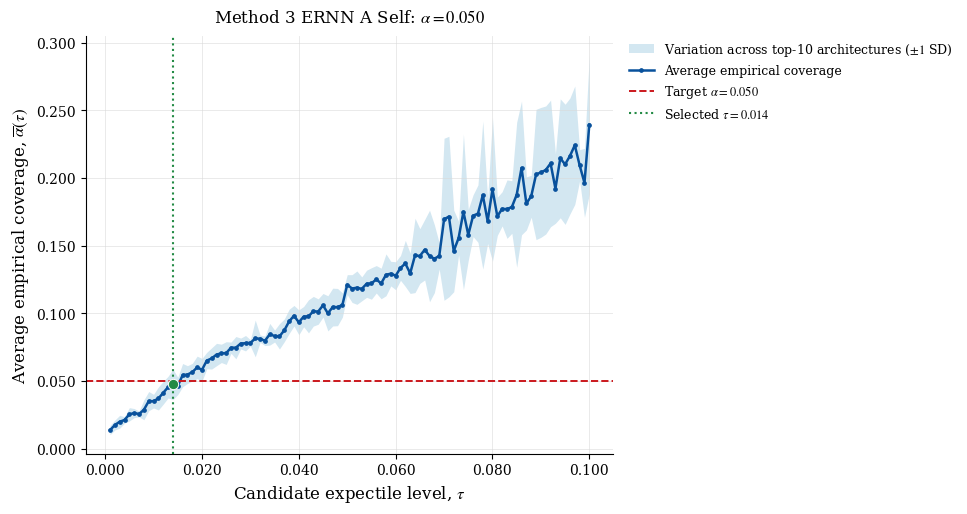


METHOD 3 ERNN A SELF CONVERSION COMPLETED
Target quantile alpha: 0.050
Selected expectile tau: 0.01400000
Average coverage: 0.04746137
Absolute coverage error: 0.00253863
Across-architecture SD: 0.01121998

Plot saved to:
method3_spacing_ernn_a_self_results/ernn_a_self/conversion/conversion_alpha_0.050_100points_paper.png

Summary saved to:
method3_spacing_ernn_a_self_results/ernn_a_self/conversion/conversion_alpha_0.050_100points_summary.csv

Estimated tau saved to:
method3_spacing_ernn_a_self_results/ernn_a_self/conversion/conversion_alpha_0.050_100points_estimated_tau.csv


In [28]:
# ============================================================
# METHOD 3 ERNN A SELF CONVERSION
# TARGET QUANTILE LEVEL: alpha = 0.050
# 100 candidate tau values x top 10 architectures
# ============================================================

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.ticker import FormatStrFormatter


# ------------------------------------------------------------
# 1. Load Method 3 definitions without rerunning Optuna
# ------------------------------------------------------------

required_definitions = [
    "Method3SpacingModel",
    "train_config",
    "predict_train_val",
    "single_level_nll",
    "ernn_calibration",
    "ESTIMATION_ORDER",
    "REFERENCE_LEVEL",
    "DIRECTION",
]

missing_definitions = [
    name
    for name in required_definitions
    if name not in globals()
]

if missing_definitions:
    NOTEBOOK_PATH = Path(
        "2026_07_13 - ERNN Hybrid - Self A.ipynb"
    )

    if not NOTEBOOK_PATH.exists():
        raise FileNotFoundError(
            "The A-Self notebook could not be found:\n"
            f"{NOTEBOOK_PATH.resolve()}"
        )

    with open(
        NOTEBOOK_PATH,
        "r",
        encoding="utf-8",
    ) as notebook_file:
        notebook_content = json.load(
            notebook_file
        )

    method3_source = None

    for cell in notebook_content["cells"]:
        source = "".join(
            cell.get("source", [])
        )

        if (
            "Method 3, Specification 1: "
            "Hybrid ERNN A self-lagged"
            in source
            and "class Method3SpacingModel"
            in source
            and "def train_config" in source
            and "def run_one_model" in source
        ):
            method3_source = source
            break

    if method3_source is None:
        raise RuntimeError(
            "The Method 3 ERNN A-Self "
            "definition cell could not be found."
        )

    # Remove only the call that launches Optuna.
    method3_source = method3_source.rsplit(
        'if __name__ == "__main__":',
        1,
    )[0]

    exec(
        method3_source,
        globals(),
    )

    print(
        "Method 3 ERNN A-Self definitions loaded. "
        "Optuna was not rerun."
    )


# ------------------------------------------------------------
# 2. Check data objects
# ------------------------------------------------------------

required_data = [
    "y_train",
    "X_train",
    "y_val",
    "X_val",
]

missing_data = [
    name
    for name in required_data
    if name not in globals()
]

if missing_data:
    raise RuntimeError(
        "The following data objects are missing:\n"
        + ", ".join(missing_data)
        + "\nRun the data-preparation cells first."
    )


# ------------------------------------------------------------
# 3. Conversion settings
# ------------------------------------------------------------

TARGET_ALPHA = 0.050
TARGET_LEVEL = 0.050
TARGET_DIRECTION = "lower"
REFERENCE_LEVEL_FOR_TARGET = 0.250

TAU_LOWER = 0.001
TAU_UPPER = 0.100
N_TAU_POINTS = 100
N_ARCHITECTURES = 10
CONVERSION_SEED = 2031

TAU_GRID = np.round(
    np.linspace(
        TAU_LOWER,
        TAU_UPPER,
        N_TAU_POINTS,
    ),
    12,
)


# ------------------------------------------------------------
# 4. Paths
# ------------------------------------------------------------

MODEL_DIR = (
    Path("method3_spacing_ernn_a_self_results")
    / "ernn_a_self"
)

CHECKPOINT_PATH = (
    MODEL_DIR
    / "method3_spacing_ernn_a_self_best.pt"
)

RANKING_PATH = (
    MODEL_DIR
    / f"ranking_level_{TARGET_LEVEL:.3f}.csv"
)

CONVERSION_DIR = MODEL_DIR / "conversion"

CONVERSION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

LEVEL_TAG = f"{TARGET_ALPHA:.3f}"

RAW_RESULTS_PATH = (
    CONVERSION_DIR
    / (
        f"conversion_alpha_{LEVEL_TAG}_"
        f"100points_raw.csv"
    )
)

SUMMARY_PATH = (
    CONVERSION_DIR
    / (
        f"conversion_alpha_{LEVEL_TAG}_"
        f"100points_summary.csv"
    )
)

ESTIMATE_PATH = (
    CONVERSION_DIR
    / (
        f"conversion_alpha_{LEVEL_TAG}_"
        f"100points_estimated_tau.csv"
    )
)

PLOT_PATH = (
    CONVERSION_DIR
    / (
        f"conversion_alpha_{LEVEL_TAG}_"
        f"100points_paper.png"
    )
)

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Checkpoint not found:\n"
        f"{CHECKPOINT_PATH}"
    )

if not RANKING_PATH.exists():
    raise FileNotFoundError(
        f"Ranking CSV not found:\n"
        f"{RANKING_PATH}"
    )


# ------------------------------------------------------------
# 5. Load the top 10 configurations
# ------------------------------------------------------------

ranking_df = pd.read_csv(
    RANKING_PATH
)

ranking_df = (
    ranking_df
    .sort_values(
        [
            "sum_rank",
            "nll",
            "calibration_penalty",
        ]
    )
    .reset_index(drop=True)
)

top_df = ranking_df.head(
    N_ARCHITECTURES
).copy()


def csv_boolean(value):
    if isinstance(
        value,
        (bool, np.bool_),
    ):
        return bool(value)

    return str(value).strip().lower() in {
        "true",
        "1",
        "yes",
    }


def extract_config(row):
    n_hidden_layers = int(
        row["n_hidden_layers"]
    )

    config = {
        "n_hidden_layers": n_hidden_layers,
        "activation": str(
            row["activation"]
        ),
        "dropout": float(
            row["dropout"]
        ),
        "layernorm": csv_boolean(
            row["layernorm"]
        ),
        "weight_init": str(
            row["weight_init"]
        ),
        "lr": float(
            row["lr"]
        ),
        "optimizer": str(
            row["optimizer"]
        ),
        "weight_decay": float(
            row["weight_decay"]
        ),
        "gradient_clip": float(
            row["gradient_clip"]
        ),
        "patience": int(
            row["patience"]
        ),
    }

    for layer_index in range(
        n_hidden_layers
    ):
        config[
            f"hidden_dim_{layer_index}"
        ] = int(
            row[
                f"hidden_dim_{layer_index}"
            ]
        )

    return config


architectures = []

for architecture_index, row in (
    top_df.iterrows()
):
    architectures.append(
        {
            "architecture": (
                architecture_index + 1
            ),
            "trial": int(
                row["trial"]
            ),
            "sum_rank": float(
                row["sum_rank"]
            ),
            "config": extract_config(
                row
            ),
        }
    )

print("\nTop 10 retained configurations:")

print(
    top_df[
        [
            "trial",
            "sum_rank",
            "nll",
            "calibration_penalty",
        ]
    ].to_string(index=False)
)


# ------------------------------------------------------------
# 6. Reconstruct the fixed alpha=0.250 reference
# ------------------------------------------------------------

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)

if checkpoint.get("distribution") != "ernn":
    raise ValueError(
        "The checkpoint is not an ERNN model."
    )

if (
    checkpoint.get("form") != "a"
    or checkpoint.get("lag") != "self"
):
    raise ValueError(
        "The checkpoint is not the Method 3 "
        "ERNN A self-lagged model."
    )

saved_train_predictions = {}
saved_val_predictions = {}

for level in ESTIMATION_ORDER:
    adjacent_level = REFERENCE_LEVEL[level]
    saved_direction = DIRECTION[level]

    adjacent_train = (
        None
        if adjacent_level is None
        else saved_train_predictions[
            adjacent_level
        ]
    )

    adjacent_val = (
        None
        if adjacent_level is None
        else saved_val_predictions[
            adjacent_level
        ]
    )

    saved_model = Method3SpacingModel(
        input_dim=X_train.shape[1],
        config=checkpoint[
            "configs"
        ][level],
        distribution="ernn",
        form="a",
        lag="self",
        direction=saved_direction,
    )

    saved_model.load_state_dict(
        checkpoint[
            "model_state_dicts"
        ][level]
    )

    saved_model.eval()

    (
        prediction_train,
        prediction_val,
        _,
        _,
        _,
    ) = predict_train_val(
        saved_model,
        saved_direction,
        adjacent_train,
        adjacent_val,
    )

    saved_train_predictions[level] = (
        prediction_train.detach()
    )

    saved_val_predictions[level] = (
        prediction_val.detach()
    )

reference_train = (
    saved_train_predictions[
        REFERENCE_LEVEL_FOR_TARGET
    ]
)

reference_val = (
    saved_val_predictions[
        REFERENCE_LEVEL_FOR_TARGET
    ]
)

print(
    "\nFixed adjacent reference reconstructed: "
    f"level={REFERENCE_LEVEL_FOR_TARGET:.3f}"
)


# ------------------------------------------------------------
# 7. Load any previously completed fits
# ------------------------------------------------------------

if RAW_RESULTS_PATH.exists():
    conversion_results = pd.read_csv(
        RAW_RESULTS_PATH
    )

    conversion_results["tau"] = (
        conversion_results["tau"]
        .astype(float)
        .round(12)
    )

    print(
        f"Loaded {len(conversion_results)} "
        "previously completed fits."
    )

else:
    conversion_results = pd.DataFrame()


def result_exists(
    tau_value,
    trial_number,
):
    if conversion_results.empty:
        return False

    same_tau = (
        conversion_results["tau"]
        .to_numpy(dtype=float)
        == round(float(tau_value), 12)
    )

    same_trial = (
        conversion_results["trial"]
        .to_numpy(dtype=int)
        == int(trial_number)
    )

    return bool(
        np.any(
            same_tau & same_trial
        )
    )


# ------------------------------------------------------------
# 8. Run the conversion fits
# ------------------------------------------------------------

MODEL_SPECIFICATION = (
    "ernn",
    "a",
    "self",
)

TOTAL_REQUIRED = (
    N_TAU_POINTS
    * N_ARCHITECTURES
)

print("\n" + "=" * 72)

print(
    "METHOD 3 ERNN A SELF CONVERSION"
)

print(
    f"TARGET alpha={TARGET_ALPHA:.3f}"
)

print("=" * 72)

print(
    f"Tau interval: "
    f"[{TAU_LOWER:.3f}, "
    f"{TAU_UPPER:.3f}]"
)

print(
    f"Total required fits: "
    f"{TOTAL_REQUIRED}"
)

for tau_index, candidate_tau in enumerate(
    TAU_GRID,
    start=1,
):
    candidate_tau = round(
        float(candidate_tau),
        12,
    )

    print(
        f"\nTau {tau_index}/"
        f"{N_TAU_POINTS}: "
        f"{candidate_tau:.6f}"
    )

    for architecture in architectures:
        trial_number = (
            architecture["trial"]
        )

        if result_exists(
            candidate_tau,
            trial_number,
        ):
            print(
                f"  Trial {trial_number}: "
                "already completed"
            )
            continue

        fitted_model = train_config(
            spec=MODEL_SPECIFICATION,
            config=architecture[
                "config"
            ],
            level=candidate_tau,
            direction=TARGET_DIRECTION,
            q_ref_train=reference_train,
            q_ref_val=reference_val,
            seed=CONVERSION_SEED,
        )

        if fitted_model is None:
            print(
                f"  Trial {trial_number}: "
                "training failed"
            )
            continue

        (
            _,
            prediction_val,
            _,
            delta_val,
            sigma_val,
        ) = predict_train_val(
            fitted_model,
            TARGET_DIRECTION,
            reference_train,
            reference_val,
        )

        empirical_alpha = (
            (y_val <= prediction_val)
            .float()
            .mean()
            .item()
        )

        validation_nll = (
            single_level_nll(
                y_val,
                prediction_val,
                sigma_val,
                candidate_tau,
                "ernn",
            ).item()
        )

        validation_ase = (
            ernn_calibration(
                y_val,
                prediction_val,
                candidate_tau,
            )["ase"]
        )

        mean_delta = (
            np.nan
            if delta_val is None
            else delta_val.mean().item()
        )

        result_row = pd.DataFrame(
            [
                {
                    "target_alpha": (
                        TARGET_ALPHA
                    ),
                    "tau": candidate_tau,
                    "architecture": (
                        architecture[
                            "architecture"
                        ]
                    ),
                    "trial": trial_number,
                    "sum_rank": (
                        architecture[
                            "sum_rank"
                        ]
                    ),
                    "empirical_alpha": (
                        empirical_alpha
                    ),
                    "validation_nll": (
                        validation_nll
                    ),
                    "validation_ase": (
                        validation_ase
                    ),
                    "mean_delta": (
                        mean_delta
                    ),
                }
            ]
        )

        conversion_results = pd.concat(
            [
                conversion_results,
                result_row,
            ],
            ignore_index=True,
        )

        conversion_results["tau"] = (
            conversion_results["tau"]
            .astype(float)
            .round(12)
        )

        conversion_results.to_csv(
            RAW_RESULTS_PATH,
            index=False,
        )

        print(
            f"  Trial {trial_number}: "
            f"coverage="
            f"{empirical_alpha:.6f}"
        )

        print(
            f"  Saved progress: "
            f"{len(conversion_results)}/"
            f"{TOTAL_REQUIRED}"
        )


# ------------------------------------------------------------
# 9. Verify completion
# ------------------------------------------------------------

completed_pairs = set(
    zip(
        conversion_results["tau"]
        .astype(float)
        .round(12),
        conversion_results["trial"]
        .astype(int),
    )
)

incomplete_pairs = []

for candidate_tau in TAU_GRID:
    candidate_tau = round(
        float(candidate_tau),
        12,
    )

    for architecture in architectures:
        pair = (
            candidate_tau,
            int(architecture["trial"]),
        )

        if pair not in completed_pairs:
            incomplete_pairs.append(pair)

if incomplete_pairs:
    print(
        f"\nIncomplete fits: "
        f"{len(incomplete_pairs)}"
    )

    for tau_value, trial_number in (
        incomplete_pairs[:20]
    ):
        print(
            f"tau={tau_value:.6f}, "
            f"trial={trial_number}"
        )

    raise RuntimeError(
        "Some conversion fits remain incomplete. "
        "Rerun this cell to retry only those fits."
    )


# ------------------------------------------------------------
# 10. Average coverage across architectures
# ------------------------------------------------------------

conversion_summary = (
    conversion_results
    .groupby(
        "tau",
        as_index=False,
    )
    .agg(
        mean_empirical_alpha=(
            "empirical_alpha",
            "mean",
        ),
        sd_empirical_alpha=(
            "empirical_alpha",
            "std",
        ),
        minimum_empirical_alpha=(
            "empirical_alpha",
            "min",
        ),
        maximum_empirical_alpha=(
            "empirical_alpha",
            "max",
        ),
        mean_validation_nll=(
            "validation_nll",
            "mean",
        ),
        mean_validation_ase=(
            "validation_ase",
            "mean",
        ),
        mean_delta=(
            "mean_delta",
            "mean",
        ),
        number_of_architectures=(
            "trial",
            "nunique",
        ),
    )
    .sort_values("tau")
    .reset_index(drop=True)
)

conversion_summary[
    "lower_one_sd"
] = np.clip(
    conversion_summary[
        "mean_empirical_alpha"
    ]
    - conversion_summary[
        "sd_empirical_alpha"
    ],
    0.0,
    1.0,
)

conversion_summary[
    "upper_one_sd"
] = np.clip(
    conversion_summary[
        "mean_empirical_alpha"
    ]
    + conversion_summary[
        "sd_empirical_alpha"
    ],
    0.0,
    1.0,
)

conversion_summary[
    "absolute_coverage_error"
] = np.abs(
    conversion_summary[
        "mean_empirical_alpha"
    ]
    - TARGET_ALPHA
)

conversion_summary.to_csv(
    SUMMARY_PATH,
    index=False,
)


# ------------------------------------------------------------
# 11. Select the closest tau
# ------------------------------------------------------------

selected_index = (
    conversion_summary[
        "absolute_coverage_error"
    ].idxmin()
)

selected_row = conversion_summary.loc[
    selected_index
]

estimated_tau = float(
    selected_row["tau"]
)

estimated_coverage = float(
    selected_row[
        "mean_empirical_alpha"
    ]
)

coverage_error = float(
    selected_row[
        "absolute_coverage_error"
    ]
)

coverage_sd = float(
    selected_row[
        "sd_empirical_alpha"
    ]
)

estimated_result = pd.DataFrame(
    [
        {
            "target_alpha": (
                TARGET_ALPHA
            ),
            "estimated_tau": (
                estimated_tau
            ),
            "estimated_mean_coverage": (
                estimated_coverage
            ),
            "absolute_coverage_error": (
                coverage_error
            ),
            "across_configuration_sd": (
                coverage_sd
            ),
            "tau_lower": TAU_LOWER,
            "tau_upper": TAU_UPPER,
            "number_of_tau_points": (
                N_TAU_POINTS
            ),
            "number_of_architectures": (
                N_ARCHITECTURES
            ),
            "conversion_sample": (
                "validation"
            ),
            "model": (
                "Method 3 ERNN A Self"
            ),
        }
    ]
)

estimated_result.to_csv(
    ESTIMATE_PATH,
    index=False,
)


# ------------------------------------------------------------
# 12. Paper-style plot
# ------------------------------------------------------------

plt.rcParams.update(
    {
        "font.family": "serif",
        "mathtext.fontset": "stix",
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 12,
        "legend.fontsize": 9,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.linewidth": 0.8,
    }
)

tau_values = (
    conversion_summary["tau"]
    .to_numpy(dtype=float)
)

mean_coverage = (
    conversion_summary[
        "mean_empirical_alpha"
    ].to_numpy(dtype=float)
)

lower_band = (
    conversion_summary[
        "lower_one_sd"
    ].to_numpy(dtype=float)
)

upper_band = (
    conversion_summary[
        "upper_one_sd"
    ].to_numpy(dtype=float)
)

figure, axis = plt.subplots(
    figsize=(9.5, 5.8)
)

axis.fill_between(
    tau_values,
    lower_band,
    upper_band,
    color="#9ECAE1",
    alpha=0.45,
    linewidth=0,
    label=(
        "Variation across top-10 "
        r"architectures ($\pm1$ SD)"
    ),
)

axis.plot(
    tau_values,
    mean_coverage,
    color="#08519C",
    linewidth=1.8,
    marker="o",
    markersize=2.4,
    label="Average empirical coverage",
)

axis.axhline(
    TARGET_ALPHA,
    color="#CB181D",
    linestyle="--",
    linewidth=1.4,
    label=(
        rf"Target $\alpha="
        rf"{TARGET_ALPHA:.3f}$"
    ),
)

axis.axvline(
    estimated_tau,
    color="#238B45",
    linestyle=":",
    linewidth=1.5,
    label=(
        rf"Selected $\tau="
        rf"{estimated_tau:.3f}$"
    ),
)

axis.scatter(
    estimated_tau,
    estimated_coverage,
    color="#238B45",
    edgecolor="white",
    linewidth=0.7,
    s=55,
    zorder=5,
)

axis.set_xlabel(
    r"Candidate expectile level, $\tau$"
)

axis.set_ylabel(
    r"Average empirical coverage, "
    r"$\overline{\alpha}(\tau)$"
)

axis.set_title(
    r"Method 3 ERNN A Self: "
    rf"$\alpha={TARGET_ALPHA:.3f}$",
    pad=10,
)

axis.xaxis.set_major_formatter(
    FormatStrFormatter("%.3f")
)

axis.yaxis.set_major_formatter(
    FormatStrFormatter("%.3f")
)

axis.spines["top"].set_visible(False)
axis.spines["right"].set_visible(False)

axis.grid(
    color="#D9D9D9",
    linewidth=0.6,
    alpha=0.65,
)

axis.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    borderaxespad=0.0,
    frameon=False,
)

figure.subplots_adjust(
    right=0.68,
    bottom=0.16,
)

plt.savefig(
    PLOT_PATH,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()
plt.close(figure)


# ------------------------------------------------------------
# 13. Final report
# ------------------------------------------------------------

print("\n" + "=" * 72)

print(
    "METHOD 3 ERNN A SELF "
    "CONVERSION COMPLETED"
)

print("=" * 72)

print(
    f"Target quantile alpha: "
    f"{TARGET_ALPHA:.3f}"
)

print(
    f"Selected expectile tau: "
    f"{estimated_tau:.8f}"
)

print(
    f"Average coverage: "
    f"{estimated_coverage:.8f}"
)

print(
    f"Absolute coverage error: "
    f"{coverage_error:.8f}"
)

print(
    f"Across-architecture SD: "
    f"{coverage_sd:.8f}"
)

print(
    f"\nPlot saved to:\n"
    f"{PLOT_PATH}"
)

print(
    f"\nSummary saved to:\n"
    f"{SUMMARY_PATH}"
)

print(
    f"\nEstimated tau saved to:\n"
    f"{ESTIMATE_PATH}"
)


Top retained configurations:
 trial  sum_rank       nll  calibration_penalty
   184         2 -2.698547             0.000105
   152         9 -2.685802             0.000108
   182         9 -2.685561             0.000107
   177        11 -2.680007             0.000106
   180        12 -2.685721             0.000109
   133        12 -2.681044             0.000107
   183        19 -2.685107             0.000109
   196        19 -2.683667             0.000109
   124        20 -2.677150             0.000108
   181        22 -2.682035             0.000109

Fixed adjacent reference reconstructed: level=0.500

METHOD 3 ERNN A SELF CONVERSION
TARGET alpha=0.250
Candidate tau interval: [0.010, 0.400]
Total required fits: 1000

Tau 1/100: 0.010000
  Trial 184: coverage=0.064018
  Saved progress: 1/1000
  Trial 152: coverage=0.048565
  Saved progress: 2/1000
  Trial 182: coverage=0.070640
  Saved progress: 3/1000
  Trial 177: coverage=0.086093
  Saved progress: 4/1000
  Trial 180: coverage=0.044

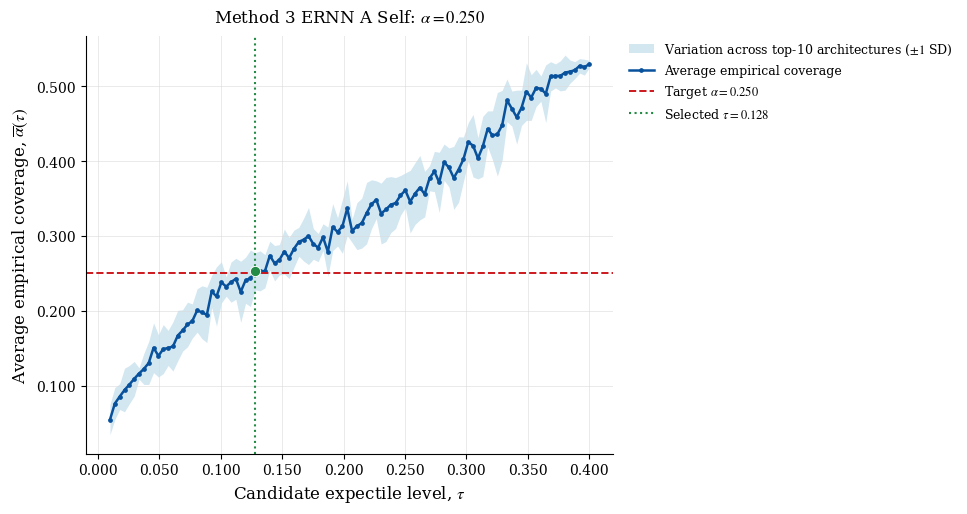


METHOD 3 ERNN A SELF CONVERSION COMPLETED
Target quantile alpha: 0.250
Selected expectile tau: 0.12818182
Average coverage: 0.25275938
Absolute coverage error: 0.00275938
Across-architecture SD: 0.02487188

Plot saved to:
method3_spacing_ernn_a_self_results/ernn_a_self/conversion/conversion_alpha_0.250_100points_paper.png

Summary saved to:
method3_spacing_ernn_a_self_results/ernn_a_self/conversion/conversion_alpha_0.250_100points_summary.csv


In [30]:
# ============================================================
# REUSABLE METHOD 3 ERNN A-SELF CONVERSION
# CURRENT TARGET: alpha = 0.250
# ============================================================

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.ticker import FormatStrFormatter


# ------------------------------------------------------------
# 1. Load Method 3 definitions without rerunning Optuna
# ------------------------------------------------------------

required_definitions = [
    "Method3SpacingModel",
    "train_config",
    "predict_train_val",
    "single_level_nll",
    "ernn_calibration",
    "ESTIMATION_ORDER",
    "REFERENCE_LEVEL",
    "DIRECTION",
]

missing_definitions = [
    name
    for name in required_definitions
    if name not in globals()
]

if missing_definitions:
    NOTEBOOK_PATH = Path(
        "2026_07_13 - ERNN Hybrid - Self A.ipynb"
    )

    if not NOTEBOOK_PATH.exists():
        raise FileNotFoundError(
            "The A-Self notebook could not be found:\n"
            f"{NOTEBOOK_PATH.resolve()}"
        )

    with open(
        NOTEBOOK_PATH,
        "r",
        encoding="utf-8",
    ) as notebook_file:
        notebook_content = json.load(
            notebook_file
        )

    method3_source = None

    for cell in notebook_content["cells"]:
        source = "".join(
            cell.get("source", [])
        )

        if (
            "Method 3, Specification 1: "
            "Hybrid ERNN A self-lagged"
            in source
            and "class Method3SpacingModel"
            in source
            and "def train_config" in source
            and "def run_one_model" in source
        ):
            method3_source = source
            break

    if method3_source is None:
        raise RuntimeError(
            "The Method 3 ERNN A-Self "
            "definition cell could not be found."
        )

    method3_source = method3_source.rsplit(
        'if __name__ == "__main__":',
        1,
    )[0]

    exec(
        method3_source,
        globals(),
    )

    print(
        "Method 3 ERNN A-Self definitions loaded. "
        "Optuna was not rerun."
    )


# ------------------------------------------------------------
# 2. Check the prepared data
# ------------------------------------------------------------

required_data = [
    "y_train",
    "X_train",
    "y_val",
    "X_val",
]

missing_data = [
    name
    for name in required_data
    if name not in globals()
]

if missing_data:
    raise RuntimeError(
        "The following data objects are missing:\n"
        + ", ".join(missing_data)
        + "\nRun the data-preparation cells first."
    )


# ------------------------------------------------------------
# 3. Reusable conversion function
# ------------------------------------------------------------

def run_method3_ernn_a_self_conversion(
    target_alpha,
    reference_level,
    direction,
    tau_lower,
    tau_upper,
    conversion_seed,
    number_of_tau_points=100,
    number_of_architectures=10,
):
    target_level = float(target_alpha)

    tau_grid = np.round(
        np.linspace(
            tau_lower,
            tau_upper,
            number_of_tau_points,
        ),
        12,
    )

    model_dir = (
        Path("method3_spacing_ernn_a_self_results")
        / "ernn_a_self"
    )

    checkpoint_path = (
        model_dir
        / "method3_spacing_ernn_a_self_best.pt"
    )

    ranking_path = (
        model_dir
        / f"ranking_level_{target_level:.3f}.csv"
    )

    conversion_dir = model_dir / "conversion"

    conversion_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    level_tag = f"{target_alpha:.3f}"
    grid_tag = f"{number_of_tau_points}points"

    raw_results_path = (
        conversion_dir
        / (
            f"conversion_alpha_{level_tag}_"
            f"{grid_tag}_raw.csv"
        )
    )

    summary_path = (
        conversion_dir
        / (
            f"conversion_alpha_{level_tag}_"
            f"{grid_tag}_summary.csv"
        )
    )

    estimate_path = (
        conversion_dir
        / (
            f"conversion_alpha_{level_tag}_"
            f"{grid_tag}_estimated_tau.csv"
        )
    )

    plot_path = (
        conversion_dir
        / (
            f"conversion_alpha_{level_tag}_"
            f"{grid_tag}_paper.png"
        )
    )

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"Checkpoint not found:\n"
            f"{checkpoint_path}"
        )

    if not ranking_path.exists():
        raise FileNotFoundError(
            f"Ranking CSV not found:\n"
            f"{ranking_path}"
        )

    # --------------------------------------------------------
    # Retrieve the top-ranked architectures
    # --------------------------------------------------------

    ranking_df = pd.read_csv(
        ranking_path
    )

    ranking_df = (
        ranking_df
        .sort_values(
            [
                "sum_rank",
                "nll",
                "calibration_penalty",
            ]
        )
        .reset_index(drop=True)
    )

    top_df = ranking_df.head(
        number_of_architectures
    ).copy()

    def csv_boolean(value):
        if isinstance(
            value,
            (bool, np.bool_),
        ):
            return bool(value)

        return str(value).strip().lower() in {
            "true",
            "1",
            "yes",
        }

    def extract_config(row):
        n_hidden_layers = int(
            row["n_hidden_layers"]
        )

        config = {
            "n_hidden_layers": (
                n_hidden_layers
            ),
            "activation": str(
                row["activation"]
            ),
            "dropout": float(
                row["dropout"]
            ),
            "layernorm": csv_boolean(
                row["layernorm"]
            ),
            "weight_init": str(
                row["weight_init"]
            ),
            "lr": float(
                row["lr"]
            ),
            "optimizer": str(
                row["optimizer"]
            ),
            "weight_decay": float(
                row["weight_decay"]
            ),
            "gradient_clip": float(
                row["gradient_clip"]
            ),
            "patience": int(
                row["patience"]
            ),
        }

        for layer_index in range(
            n_hidden_layers
        ):
            config[
                f"hidden_dim_{layer_index}"
            ] = int(
                row[
                    f"hidden_dim_{layer_index}"
                ]
            )

        return config

    architectures = []

    for architecture_index, row in (
        top_df.iterrows()
    ):
        architectures.append(
            {
                "architecture": (
                    architecture_index + 1
                ),
                "trial": int(
                    row["trial"]
                ),
                "sum_rank": float(
                    row["sum_rank"]
                ),
                "config": extract_config(
                    row
                ),
            }
        )

    print("\nTop retained configurations:")

    print(
        top_df[
            [
                "trial",
                "sum_rank",
                "nll",
                "calibration_penalty",
            ]
        ].to_string(index=False)
    )

    # --------------------------------------------------------
    # Reconstruct the fixed adjacent reference
    # --------------------------------------------------------

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )

    if checkpoint.get("distribution") != "ernn":
        raise ValueError(
            "The checkpoint is not an ERNN model."
        )

    if (
        checkpoint.get("form") != "a"
        or checkpoint.get("lag") != "self"
    ):
        raise ValueError(
            "The checkpoint is not the Method 3 "
            "ERNN A self-lagged model."
        )

    if reference_level is None:
        reference_train = None
        reference_val = None

    else:
        saved_train_predictions = {}
        saved_val_predictions = {}

        for level in ESTIMATION_ORDER:
            adjacent_level = (
                REFERENCE_LEVEL[level]
            )

            saved_direction = (
                DIRECTION[level]
            )

            adjacent_train = (
                None
                if adjacent_level is None
                else saved_train_predictions[
                    adjacent_level
                ]
            )

            adjacent_val = (
                None
                if adjacent_level is None
                else saved_val_predictions[
                    adjacent_level
                ]
            )

            saved_model = Method3SpacingModel(
                input_dim=X_train.shape[1],
                config=checkpoint[
                    "configs"
                ][level],
                distribution="ernn",
                form="a",
                lag="self",
                direction=saved_direction,
            )

            saved_model.load_state_dict(
                checkpoint[
                    "model_state_dicts"
                ][level]
            )

            saved_model.eval()

            (
                prediction_train,
                prediction_val,
                _,
                _,
                _,
            ) = predict_train_val(
                saved_model,
                saved_direction,
                adjacent_train,
                adjacent_val,
            )

            saved_train_predictions[level] = (
                prediction_train.detach()
            )

            saved_val_predictions[level] = (
                prediction_val.detach()
            )

        reference_train = (
            saved_train_predictions[
                reference_level
            ]
        )

        reference_val = (
            saved_val_predictions[
                reference_level
            ]
        )

        print(
            "\nFixed adjacent reference reconstructed: "
            f"level={reference_level:.3f}"
        )

    # --------------------------------------------------------
    # Load previously completed fits
    # --------------------------------------------------------

    if raw_results_path.exists():
        conversion_results = pd.read_csv(
            raw_results_path
        )

        conversion_results["tau"] = (
            conversion_results["tau"]
            .astype(float)
            .round(12)
        )

        print(
            f"Loaded {len(conversion_results)} "
            "previously completed fits."
        )

    else:
        conversion_results = pd.DataFrame()

    def result_exists(
        tau_value,
        trial_number,
    ):
        if conversion_results.empty:
            return False

        same_tau = (
            conversion_results["tau"]
            .to_numpy(dtype=float)
            == round(float(tau_value), 12)
        )

        same_trial = (
            conversion_results["trial"]
            .to_numpy(dtype=int)
            == int(trial_number)
        )

        return bool(
            np.any(
                same_tau & same_trial
            )
        )

    # --------------------------------------------------------
    # Run conversion fits
    # --------------------------------------------------------

    model_specification = (
        "ernn",
        "a",
        "self",
    )

    total_required = (
        number_of_tau_points
        * number_of_architectures
    )

    print("\n" + "=" * 72)

    print(
        "METHOD 3 ERNN A SELF CONVERSION"
    )

    print(
        f"TARGET alpha={target_alpha:.3f}"
    )

    print("=" * 72)

    print(
        f"Candidate tau interval: "
        f"[{tau_lower:.3f}, "
        f"{tau_upper:.3f}]"
    )

    print(
        f"Total required fits: "
        f"{total_required}"
    )

    for tau_index, candidate_tau in enumerate(
        tau_grid,
        start=1,
    ):
        candidate_tau = round(
            float(candidate_tau),
            12,
        )

        print(
            f"\nTau {tau_index}/"
            f"{number_of_tau_points}: "
            f"{candidate_tau:.6f}"
        )

        for architecture in architectures:
            trial_number = (
                architecture["trial"]
            )

            if result_exists(
                candidate_tau,
                trial_number,
            ):
                print(
                    f"  Trial {trial_number}: "
                    "already completed"
                )
                continue

            fitted_model = train_config(
                spec=model_specification,
                config=architecture[
                    "config"
                ],
                level=candidate_tau,
                direction=direction,
                q_ref_train=reference_train,
                q_ref_val=reference_val,
                seed=conversion_seed,
            )

            if fitted_model is None:
                print(
                    f"  Trial {trial_number}: "
                    "training failed"
                )
                continue

            (
                _,
                prediction_val,
                _,
                delta_val,
                sigma_val,
            ) = predict_train_val(
                fitted_model,
                direction,
                reference_train,
                reference_val,
            )

            empirical_alpha = (
                (y_val <= prediction_val)
                .float()
                .mean()
                .item()
            )

            validation_nll = (
                single_level_nll(
                    y_val,
                    prediction_val,
                    sigma_val,
                    candidate_tau,
                    "ernn",
                ).item()
            )

            validation_ase = (
                ernn_calibration(
                    y_val,
                    prediction_val,
                    candidate_tau,
                )["ase"]
            )

            mean_delta = (
                np.nan
                if delta_val is None
                else delta_val.mean().item()
            )

            result_row = pd.DataFrame(
                [
                    {
                        "target_alpha": (
                            target_alpha
                        ),
                        "tau": candidate_tau,
                        "architecture": (
                            architecture[
                                "architecture"
                            ]
                        ),
                        "trial": trial_number,
                        "sum_rank": (
                            architecture[
                                "sum_rank"
                            ]
                        ),
                        "empirical_alpha": (
                            empirical_alpha
                        ),
                        "validation_nll": (
                            validation_nll
                        ),
                        "validation_ase": (
                            validation_ase
                        ),
                        "mean_delta": (
                            mean_delta
                        ),
                    }
                ]
            )

            conversion_results = pd.concat(
                [
                    conversion_results,
                    result_row,
                ],
                ignore_index=True,
            )

            conversion_results["tau"] = (
                conversion_results["tau"]
                .astype(float)
                .round(12)
            )

            conversion_results.to_csv(
                raw_results_path,
                index=False,
            )

            print(
                f"  Trial {trial_number}: "
                f"coverage="
                f"{empirical_alpha:.6f}"
            )

            print(
                f"  Saved progress: "
                f"{len(conversion_results)}/"
                f"{total_required}"
            )

    # --------------------------------------------------------
    # Verify completion
    # --------------------------------------------------------

    completed_pairs = set(
        zip(
            conversion_results["tau"]
            .astype(float)
            .round(12),
            conversion_results["trial"]
            .astype(int),
        )
    )

    incomplete_pairs = []

    for candidate_tau in tau_grid:
        candidate_tau = round(
            float(candidate_tau),
            12,
        )

        for architecture in architectures:
            pair = (
                candidate_tau,
                int(architecture["trial"]),
            )

            if pair not in completed_pairs:
                incomplete_pairs.append(pair)

    if incomplete_pairs:
        print(
            f"\nIncomplete fits: "
            f"{len(incomplete_pairs)}"
        )

        for tau_value, trial_number in (
            incomplete_pairs[:20]
        ):
            print(
                f"tau={tau_value:.6f}, "
                f"trial={trial_number}"
            )

        raise RuntimeError(
            "Some conversion fits remain incomplete. "
            "Rerun this cell to retry only those fits."
        )

    # --------------------------------------------------------
    # Average coverage
    # --------------------------------------------------------

    conversion_summary = (
        conversion_results
        .groupby(
            "tau",
            as_index=False,
        )
        .agg(
            mean_empirical_alpha=(
                "empirical_alpha",
                "mean",
            ),
            sd_empirical_alpha=(
                "empirical_alpha",
                "std",
            ),
            minimum_empirical_alpha=(
                "empirical_alpha",
                "min",
            ),
            maximum_empirical_alpha=(
                "empirical_alpha",
                "max",
            ),
            mean_validation_nll=(
                "validation_nll",
                "mean",
            ),
            mean_validation_ase=(
                "validation_ase",
                "mean",
            ),
            mean_delta=(
                "mean_delta",
                "mean",
            ),
            number_of_architectures=(
                "trial",
                "nunique",
            ),
        )
        .sort_values("tau")
        .reset_index(drop=True)
    )

    conversion_summary[
        "lower_one_sd"
    ] = np.clip(
        conversion_summary[
            "mean_empirical_alpha"
        ]
        - conversion_summary[
            "sd_empirical_alpha"
        ],
        0.0,
        1.0,
    )

    conversion_summary[
        "upper_one_sd"
    ] = np.clip(
        conversion_summary[
            "mean_empirical_alpha"
        ]
        + conversion_summary[
            "sd_empirical_alpha"
        ],
        0.0,
        1.0,
    )

    conversion_summary[
        "absolute_coverage_error"
    ] = np.abs(
        conversion_summary[
            "mean_empirical_alpha"
        ]
        - target_alpha
    )

    conversion_summary.to_csv(
        summary_path,
        index=False,
    )

    # --------------------------------------------------------
    # Select converted tau
    # --------------------------------------------------------

    selected_index = (
        conversion_summary[
            "absolute_coverage_error"
        ].idxmin()
    )

    selected_row = (
        conversion_summary.loc[
            selected_index
        ]
    )

    estimated_tau = float(
        selected_row["tau"]
    )

    estimated_coverage = float(
        selected_row[
            "mean_empirical_alpha"
        ]
    )

    coverage_error = float(
        selected_row[
            "absolute_coverage_error"
        ]
    )

    coverage_sd = float(
        selected_row[
            "sd_empirical_alpha"
        ]
    )

    estimated_result = pd.DataFrame(
        [
            {
                "target_alpha": (
                    target_alpha
                ),
                "estimated_tau": (
                    estimated_tau
                ),
                "estimated_mean_coverage": (
                    estimated_coverage
                ),
                "absolute_coverage_error": (
                    coverage_error
                ),
                "across_configuration_sd": (
                    coverage_sd
                ),
                "tau_lower": tau_lower,
                "tau_upper": tau_upper,
                "number_of_tau_points": (
                    number_of_tau_points
                ),
                "number_of_architectures": (
                    number_of_architectures
                ),
                "conversion_sample": (
                    "validation"
                ),
                "model": (
                    "Method 3 ERNN A Self"
                ),
            }
        ]
    )

    estimated_result.to_csv(
        estimate_path,
        index=False,
    )

    # --------------------------------------------------------
    # Paper-style plot
    # --------------------------------------------------------

    plt.rcParams.update(
        {
            "font.family": "serif",
            "mathtext.fontset": "stix",
            "font.size": 11,
            "axes.labelsize": 12,
            "axes.titlesize": 12,
            "legend.fontsize": 9,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "axes.linewidth": 0.8,
        }
    )

    tau_values = (
        conversion_summary["tau"]
        .to_numpy(dtype=float)
    )

    mean_coverage = (
        conversion_summary[
            "mean_empirical_alpha"
        ].to_numpy(dtype=float)
    )

    lower_band = (
        conversion_summary[
            "lower_one_sd"
        ].to_numpy(dtype=float)
    )

    upper_band = (
        conversion_summary[
            "upper_one_sd"
        ].to_numpy(dtype=float)
    )

    figure, axis = plt.subplots(
        figsize=(9.5, 5.8)
    )

    axis.fill_between(
        tau_values,
        lower_band,
        upper_band,
        color="#9ECAE1",
        alpha=0.45,
        linewidth=0,
        label=(
            "Variation across top-10 "
            r"architectures ($\pm1$ SD)"
        ),
    )

    axis.plot(
        tau_values,
        mean_coverage,
        color="#08519C",
        linewidth=1.8,
        marker="o",
        markersize=2.4,
        label="Average empirical coverage",
    )

    axis.axhline(
        target_alpha,
        color="#CB181D",
        linestyle="--",
        linewidth=1.4,
        label=(
            rf"Target $\alpha="
            rf"{target_alpha:.3f}$"
        ),
    )

    axis.axvline(
        estimated_tau,
        color="#238B45",
        linestyle=":",
        linewidth=1.5,
        label=(
            rf"Selected $\tau="
            rf"{estimated_tau:.3f}$"
        ),
    )

    axis.scatter(
        estimated_tau,
        estimated_coverage,
        color="#238B45",
        edgecolor="white",
        linewidth=0.7,
        s=55,
        zorder=5,
    )

    axis.set_xlabel(
        r"Candidate expectile level, $\tau$"
    )

    axis.set_ylabel(
        r"Average empirical coverage, "
        r"$\overline{\alpha}(\tau)$"
    )

    axis.set_title(
        r"Method 3 ERNN A Self: "
        rf"$\alpha={target_alpha:.3f}$",
        pad=10,
    )

    axis.xaxis.set_major_formatter(
        FormatStrFormatter("%.3f")
    )

    axis.yaxis.set_major_formatter(
        FormatStrFormatter("%.3f")
    )

    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

    axis.grid(
        color="#D9D9D9",
        linewidth=0.6,
        alpha=0.65,
    )

    axis.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.00),
        borderaxespad=0.0,
        frameon=False,
    )

    figure.subplots_adjust(
        right=0.68,
        bottom=0.16,
    )

    plt.savefig(
        plot_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.show()
    plt.close(figure)

    # --------------------------------------------------------
    # Final report
    # --------------------------------------------------------

    print("\n" + "=" * 72)

    print(
        "METHOD 3 ERNN A SELF "
        "CONVERSION COMPLETED"
    )

    print("=" * 72)

    print(
        f"Target quantile alpha: "
        f"{target_alpha:.3f}"
    )

    print(
        f"Selected expectile tau: "
        f"{estimated_tau:.8f}"
    )

    print(
        f"Average coverage: "
        f"{estimated_coverage:.8f}"
    )

    print(
        f"Absolute coverage error: "
        f"{coverage_error:.8f}"
    )

    print(
        f"Across-architecture SD: "
        f"{coverage_sd:.8f}"
    )

    print(
        f"\nPlot saved to:\n"
        f"{plot_path}"
    )

    print(
        f"\nSummary saved to:\n"
        f"{summary_path}"
    )

    return {
        "target_alpha": target_alpha,
        "estimated_tau": estimated_tau,
        "estimated_coverage": (
            estimated_coverage
        ),
        "coverage_error": coverage_error,
        "coverage_sd": coverage_sd,
        "summary": conversion_summary,
        "plot_path": plot_path,
    }


# ------------------------------------------------------------
# 4. Run conversion for alpha = 0.250
# ------------------------------------------------------------

conversion_a_self_0250 = (
    run_method3_ernn_a_self_conversion(
        target_alpha=0.250,
        reference_level=0.500,
        direction="lower",
        tau_lower=0.010,
        tau_upper=0.400,
        conversion_seed=2030,
        number_of_tau_points=100,
        number_of_architectures=10,
    )
)


Top retained configurations:
 trial  sum_rank       nll  calibration_penalty
   163         4 -2.628905             0.000132
   181         6 -2.630245             0.000134
   141        10 -2.626512             0.000133
   169        13 -2.629221             0.000135
   165        13 -2.626709             0.000134
   168        17 -2.622251             0.000134
   162        20 -2.628449             0.000135
   182        23 -2.622579             0.000135
   193        27 -2.623789             0.000135
   199        27 -2.619304             0.000134

METHOD 3 ERNN A SELF CONVERSION
TARGET alpha=0.500
Candidate tau interval: [0.100, 0.900]
Total required fits: 1000

Tau 1/100: 0.100000
  Trial 163: coverage=0.203091
  Saved progress: 1/1000
  Trial 181: coverage=0.267108
  Saved progress: 2/1000
  Trial 141: coverage=0.165563
  Saved progress: 3/1000
  Trial 169: coverage=0.251656
  Saved progress: 4/1000
  Trial 165: coverage=0.178808
  Saved progress: 5/1000
  Trial 168: coverage=0.

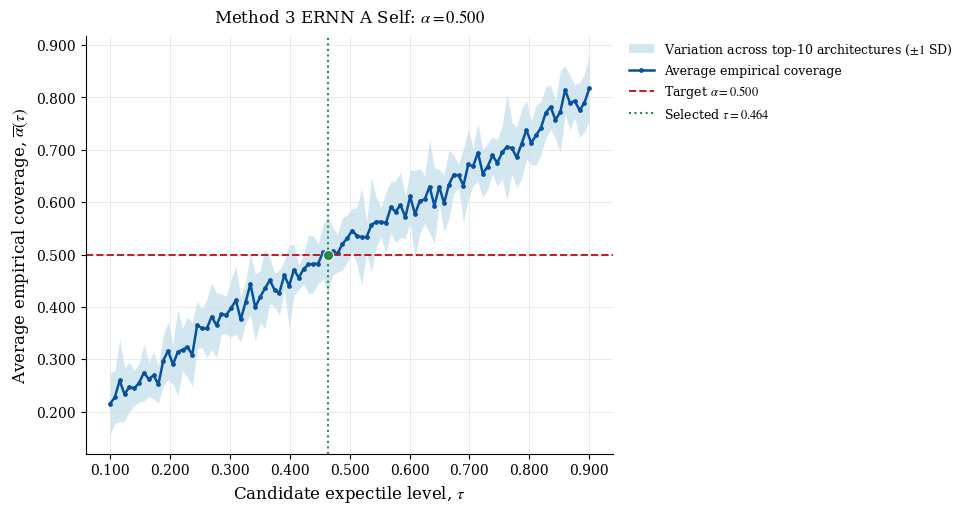


METHOD 3 ERNN A SELF CONVERSION COMPLETED
Target quantile alpha: 0.500
Selected expectile tau: 0.46363636
Average coverage: 0.50000000
Absolute coverage error: 0.00000000
Across-architecture SD: 0.07232366

Plot saved to:
method3_spacing_ernn_a_self_results/ernn_a_self/conversion/conversion_alpha_0.500_100points_paper.png

Summary saved to:
method3_spacing_ernn_a_self_results/ernn_a_self/conversion/conversion_alpha_0.500_100points_summary.csv


In [32]:
# ============================================================
# METHOD 3 ERNN A-SELF CONVERSION
# TARGET QUANTILE LEVEL: alpha = 0.500
# ============================================================

if (
    "run_method3_ernn_a_self_conversion"
    not in globals()
):
    raise RuntimeError(
        "The reusable A-Self conversion function "
        "is unavailable. Run the previous alpha=0.250 "
        "conversion cell first."
    )

conversion_a_self_0500 = (
    run_method3_ernn_a_self_conversion(
        target_alpha=0.500,
        reference_level=None,
        direction=None,
        tau_lower=0.100,
        tau_upper=0.900,
        conversion_seed=2026,
        number_of_tau_points=100,
        number_of_architectures=10,
    )
)

Reusable Method 3 ERNN A-Self conversion function reloaded.

Top retained configurations:
 trial  sum_rank       nll  calibration_penalty
    71         3 -2.746608             0.000093
    15         7 -2.745244             0.000094
   193         8 -2.746897             0.000095
   182        10 -2.744528             0.000095
   108        16 -2.743685             0.000096
   123        18 -2.731889             0.000096
   138        18 -2.727619             0.000094
   188        19 -2.734050             0.000097
    86        21 -2.735212             0.000098
   101        23 -2.731902             0.000098

Fixed adjacent reference reconstructed: level=0.500

METHOD 3 ERNN A SELF CONVERSION
TARGET alpha=0.750
Candidate tau interval: [0.600, 0.990]
Total required fits: 1000

Tau 1/100: 0.600000
  Trial 71: coverage=0.589404
  Saved progress: 1/1000
  Trial 15: coverage=0.532009
  Saved progress: 2/1000
  Trial 193: coverage=0.582781
  Saved progress: 3/1000
  Trial 182: coverage=0.6

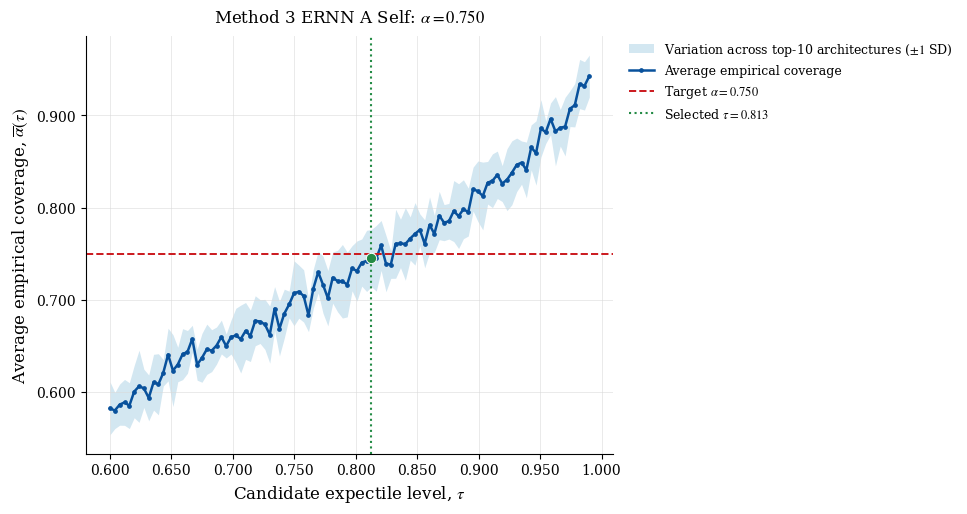


METHOD 3 ERNN A SELF CONVERSION COMPLETED
Target quantile alpha: 0.750
Selected expectile tau: 0.81272727
Average coverage: 0.74525387
Absolute coverage error: 0.00474613
Across-architecture SD: 0.03104842

Plot saved to:
method3_spacing_ernn_a_self_results/ernn_a_self/conversion/conversion_alpha_0.750_100points_paper.png

Summary saved to:
method3_spacing_ernn_a_self_results/ernn_a_self/conversion/conversion_alpha_0.750_100points_summary.csv


In [16]:
# ============================================================
# RELOAD THE SAVED A-SELF CONVERSION FUNCTION
# THEN RUN TARGET alpha = 0.750
# ============================================================

from pathlib import Path
import json


# ------------------------------------------------------------
# 1. Reload the reusable function from this notebook
# ------------------------------------------------------------

if (
    "run_method3_ernn_a_self_conversion"
    not in globals()
):
    NOTEBOOK_PATH = Path(
        "2026_07_13 - ERNN Hybrid - Self A.ipynb"
    )

    if not NOTEBOOK_PATH.exists():
        raise FileNotFoundError(
            "The A-Self notebook could not be found:\n"
            f"{NOTEBOOK_PATH.resolve()}"
        )

    with open(
        NOTEBOOK_PATH,
        "r",
        encoding="utf-8",
    ) as notebook_file:
        notebook_content = json.load(
            notebook_file
        )

    conversion_source = None

    for cell in notebook_content["cells"]:
        source = "".join(
            cell.get("source", [])
        )

        if (
            "def run_method3_ernn_a_self_conversion"
            in source
        ):
            conversion_source = source
            break

    if conversion_source is None:
        raise RuntimeError(
            "The reusable A-Self conversion "
            "function could not be found."
        )

    # Remove the alpha=0.250 call at the end.
    # Only definitions and supporting code are executed.
    conversion_source = conversion_source.split(
        "# ------------------------------------------------------------\n"
        "# 4. Run conversion for alpha = 0.250",
        1,
    )[0]

    exec(
        conversion_source,
        globals(),
    )

    print(
        "Reusable Method 3 ERNN A-Self "
        "conversion function reloaded."
    )


# ------------------------------------------------------------
# 2. Confirm the function is available
# ------------------------------------------------------------

if (
    "run_method3_ernn_a_self_conversion"
    not in globals()
):
    raise RuntimeError(
        "The conversion function remains unavailable."
    )


# ------------------------------------------------------------
# 3. Run conversion for alpha = 0.750
# ------------------------------------------------------------

conversion_a_self_0750 = (
    run_method3_ernn_a_self_conversion(
        target_alpha=0.750,
        reference_level=0.500,
        direction="upper",
        tau_lower=0.600,
        tau_upper=0.990,
        conversion_seed=2027,
        number_of_tau_points=100,
        number_of_architectures=10,
    )
)


Top retained configurations:
 trial  sum_rank       nll  calibration_penalty
   182         8 -2.704674             0.000035
   121        13 -2.703753             0.000035
   186        17 -2.703315             0.000035
   167        21 -2.702965             0.000035
   175        23 -2.703183             0.000035
   124        24 -2.701867             0.000035
    41        27 -2.701566             0.000035
   165        28 -2.703634             0.000035
   170        31 -2.703585             0.000035
   133        34 -2.702626             0.000035

Fixed adjacent reference reconstructed: level=0.750

METHOD 3 ERNN A SELF CONVERSION
TARGET alpha=0.950
Candidate tau interval: [0.900, 0.999]
Total required fits: 1000

Tau 1/100: 0.900000
  Trial 182: coverage=0.785872
  Saved progress: 1/1000
  Trial 121: coverage=0.799117
  Saved progress: 2/1000
  Trial 186: coverage=0.801324
  Saved progress: 3/1000
  Trial 167: coverage=0.768212
  Saved progress: 4/1000
  Trial 175: coverage=0.766

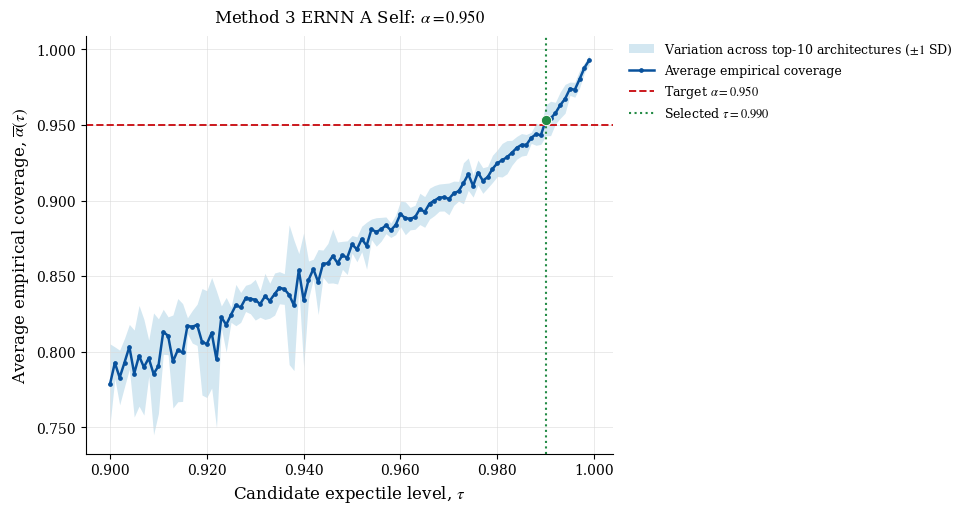


METHOD 3 ERNN A SELF CONVERSION COMPLETED
Target quantile alpha: 0.950
Selected expectile tau: 0.99000000
Average coverage: 0.95298012
Absolute coverage error: 0.00298012
Across-architecture SD: 0.01019869

Plot saved to:
method3_spacing_ernn_a_self_results/ernn_a_self/conversion/conversion_alpha_0.950_100points_paper.png

Summary saved to:
method3_spacing_ernn_a_self_results/ernn_a_self/conversion/conversion_alpha_0.950_100points_summary.csv


In [18]:
# ============================================================
# METHOD 3 ERNN A-SELF CONVERSION
# TARGET QUANTILE LEVEL: alpha = 0.950
# ============================================================

if (
    "run_method3_ernn_a_self_conversion"
    not in globals()
):
    raise RuntimeError(
        "The reusable conversion function is unavailable. "
        "Run the previous function-loader cell first."
    )

conversion_a_self_0950 = (
    run_method3_ernn_a_self_conversion(
        target_alpha=0.950,
        reference_level=0.750,
        direction="upper",
        tau_lower=0.900,
        tau_upper=0.999,
        conversion_seed=2028,
        number_of_tau_points=100,
        number_of_architectures=10,
    )
)


Top retained configurations:
 trial  sum_rank       nll  calibration_penalty
   155         3 -2.683665             0.000020
   195         7 -2.683222             0.000020
   181         7 -2.679913             0.000020
   120        10 -2.677459             0.000020
   138        10 -2.674161             0.000020
   133        11 -2.671863             0.000020
   171        13 -2.675876             0.000020
   193        15 -2.675034             0.000021
   134        15 -2.673280             0.000020
   187        19 -2.673278             0.000021

Fixed adjacent reference reconstructed: level=0.950

METHOD 3 ERNN A SELF CONVERSION
TARGET alpha=0.975
Candidate tau interval: [0.950, 0.999]
Total required fits: 1000

Tau 1/100: 0.950000
  Trial 155: coverage=0.876380
  Saved progress: 1/1000
  Trial 195: coverage=0.876380
  Saved progress: 2/1000
  Trial 181: coverage=0.880795
  Saved progress: 3/1000
  Trial 120: coverage=0.876380
  Saved progress: 4/1000
  Trial 138: coverage=0.876

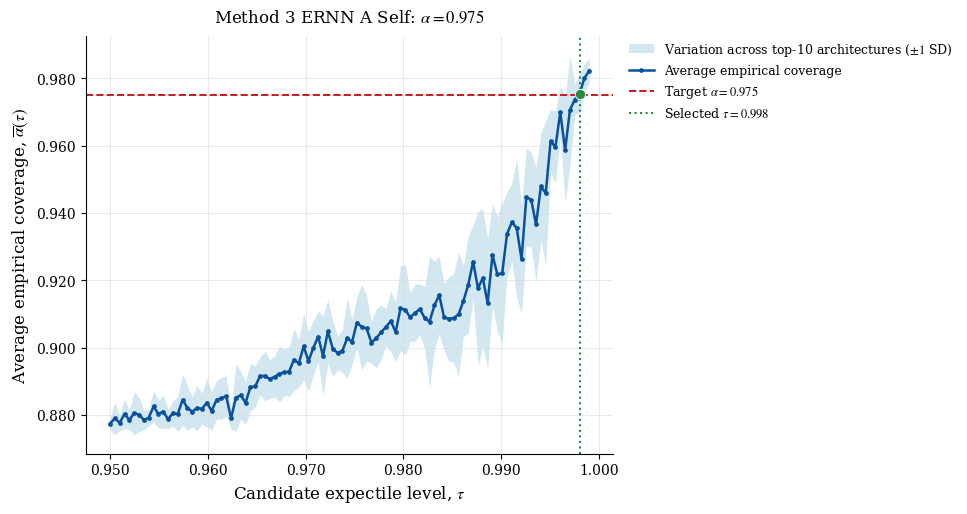


METHOD 3 ERNN A SELF CONVERSION COMPLETED
Target quantile alpha: 0.975
Selected expectile tau: 0.99801010
Average coverage: 0.97549669
Absolute coverage error: 0.00049669
Across-architecture SD: 0.00564726

Plot saved to:
method3_spacing_ernn_a_self_results/ernn_a_self/conversion/conversion_alpha_0.975_100points_paper.png

Summary saved to:
method3_spacing_ernn_a_self_results/ernn_a_self/conversion/conversion_alpha_0.975_100points_summary.csv


In [20]:
# ============================================================
# METHOD 3 ERNN A-SELF CONVERSION
# TARGET QUANTILE LEVEL: alpha = 0.975
# ============================================================

if (
    "run_method3_ernn_a_self_conversion"
    not in globals()
):
    raise RuntimeError(
        "The reusable conversion function is unavailable. "
        "Run the function-loader cell first."
    )

conversion_a_self_0975 = (
    run_method3_ernn_a_self_conversion(
        target_alpha=0.975,
        reference_level=0.950,
        direction="upper",
        tau_lower=0.950,
        tau_upper=0.999,
        conversion_seed=2029,
        number_of_tau_points=100,
        number_of_architectures=10,
    )
)

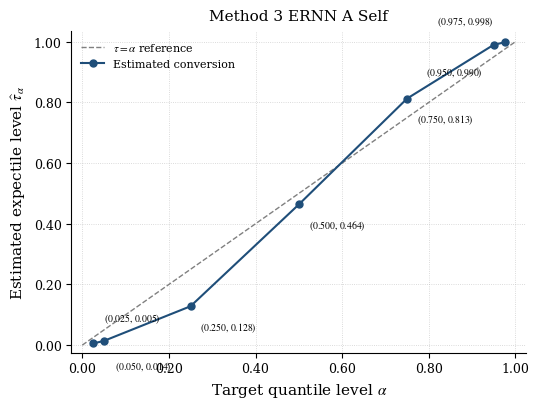


Combined conversion results:
     alpha    tau_hat  mean_coverage  absolute_coverage_error  coverage_sd
0.02500000 0.00545455     0.02450331               0.00049669   0.00503926
0.05000000 0.01400000     0.04746137               0.00253863   0.01121998
0.25000000 0.12818182     0.25275938               0.00275938   0.02487188
0.50000000 0.46363636     0.50000000               0.00000000   0.07232366
0.75000000 0.81272727     0.74525387               0.00474613   0.03104842
0.95000000 0.99000000     0.95298012               0.00298012   0.01019869
0.97500000 0.99801010     0.97549669               0.00049669   0.00564726

Plot saved to:
method3_spacing_ernn_a_self_results/ernn_a_self/conversion/method3_ernn_a_self_conversion_summary.png

Summary table saved to:
method3_spacing_ernn_a_self_results/ernn_a_self/conversion/method3_ernn_a_self_conversion_summary.csv


In [22]:
# ============================================================
# COMBINED CONVERSION PLOT
# METHOD 3 ERNN A SELF
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FormatStrFormatter


# ------------------------------------------------------------
# 1. Paths and target levels
# ------------------------------------------------------------

CONVERSION_DIR = (
    Path("method3_spacing_ernn_a_self_results")
    / "ernn_a_self"
    / "conversion"
)

TARGET_LEVELS = [
    0.025,
    0.050,
    0.250,
    0.500,
    0.750,
    0.950,
    0.975,
]

OUTPUT_PATH = (
    CONVERSION_DIR
    / "method3_ernn_a_self_conversion_summary.png"
)

TABLE_PATH = (
    CONVERSION_DIR
    / "method3_ernn_a_self_conversion_summary.csv"
)


# ------------------------------------------------------------
# 2. Read the seven estimated conversion results
# ------------------------------------------------------------

conversion_rows = []

for target_alpha in TARGET_LEVELS:
    level_tag = f"{target_alpha:.3f}"

    estimate_path = (
        CONVERSION_DIR
        / (
            f"conversion_alpha_{level_tag}_"
            f"100points_estimated_tau.csv"
        )
    )

    if not estimate_path.exists():
        raise FileNotFoundError(
            "Conversion result not found:\n"
            f"{estimate_path}"
        )

    estimate_df = pd.read_csv(
        estimate_path
    )

    if estimate_df.empty:
        raise RuntimeError(
            "Conversion result is empty:\n"
            f"{estimate_path}"
        )

    row = estimate_df.iloc[0]

    conversion_rows.append(
        {
            "alpha": float(
                row["target_alpha"]
            ),
            "tau_hat": float(
                row["estimated_tau"]
            ),
            "mean_coverage": float(
                row[
                    "estimated_mean_coverage"
                ]
            ),
            "absolute_coverage_error": float(
                row[
                    "absolute_coverage_error"
                ]
            ),
            "coverage_sd": float(
                row.get(
                    "across_configuration_sd",
                    np.nan,
                )
            ),
        }
    )

conversion_df = (
    pd.DataFrame(conversion_rows)
    .sort_values("alpha")
    .reset_index(drop=True)
)

conversion_df.to_csv(
    TABLE_PATH,
    index=False,
)

alpha = conversion_df[
    "alpha"
].to_numpy(dtype=float)

tau_hat = conversion_df[
    "tau_hat"
].to_numpy(dtype=float)


# ------------------------------------------------------------
# 3. Paper-style formatting
# ------------------------------------------------------------

plt.rcParams.update(
    {
        "font.family": "serif",
        "mathtext.fontset": "stix",
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 11,
        "legend.fontsize": 8,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 0.8,
    }
)

fig, ax = plt.subplots(
    figsize=(5.5, 4.2)
)


# ------------------------------------------------------------
# 4. Reference and estimated conversion lines
# ------------------------------------------------------------

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.0,
    color="grey",
    label=r"$\tau=\alpha$ reference",
)

ax.plot(
    alpha,
    tau_hat,
    marker="o",
    markersize=5,
    linewidth=1.5,
    color="#1f4e79",
    label="Estimated conversion",
)


# ------------------------------------------------------------
# 5. Annotation positions
# ------------------------------------------------------------

annotation_settings = {
    0.025: {
        "offset": (8, 13),
        "ha": "left",
        "va": "bottom",
    },
    0.050: {
        "offset": (8, -13),
        "ha": "left",
        "va": "top",
    },
    0.250: {
        "offset": (7, -10),
        "ha": "left",
        "va": "top",
    },
    0.500: {
        "offset": (7, -10),
        "ha": "left",
        "va": "top",
    },
    0.750: {
        "offset": (7, -10),
        "ha": "left",
        "va": "top",
    },
    0.950: {
        "offset": (-8, -15),
        "ha": "right",
        "va": "top",
    },
    0.975: {
        "offset": (-8, 10),
        "ha": "right",
        "va": "bottom",
    },
}

for target_alpha, estimated_tau in zip(
    alpha,
    tau_hat,
):
    rounded_alpha = round(
        float(target_alpha),
        3,
    )

    settings = annotation_settings[
        rounded_alpha
    ]

    ax.annotate(
        (
            rf"$({target_alpha:.3f},"
            rf"\,{estimated_tau:.3f})$"
        ),
        xy=(
            target_alpha,
            estimated_tau,
        ),
        xytext=settings["offset"],
        textcoords="offset points",
        horizontalalignment=settings["ha"],
        verticalalignment=settings["va"],
        fontsize=7,
    )


# ------------------------------------------------------------
# 6. Axes and legend
# ------------------------------------------------------------

ax.set_xlabel(
    r"Target quantile level $\alpha$"
)

ax.set_ylabel(
    r"Estimated expectile level "
    r"$\widehat{\tau}_{\alpha}$"
)

ax.set_title(
    "Method 3 ERNN A Self",
    pad=8,
)

ax.set_xlim(
    -0.025,
    1.025,
)

ax.set_ylim(
    -0.025,
    1.035,
)

ax.xaxis.set_major_formatter(
    FormatStrFormatter("%.2f")
)

ax.yaxis.set_major_formatter(
    FormatStrFormatter("%.2f")
)

ax.grid(
    True,
    linestyle=":",
    linewidth=0.6,
    alpha=0.6,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    fontsize=8,
    loc="upper left",
)

fig.tight_layout()


# ------------------------------------------------------------
# 7. Save and display
# ------------------------------------------------------------

fig.savefig(
    OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()
plt.close(fig)

print("\nCombined conversion results:")
print(
    conversion_df.to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.8f}"
        ),
    )
)

print(
    f"\nPlot saved to:\n{OUTPUT_PATH}"
)

print(
    f"\nSummary table saved to:\n{TABLE_PATH}"
)

# Conversion - method1b

In [ ]:
# ============================================================
# METHOD 1B ERNN A-SELF — COORDINATE-WISE CONVERSION
# TARGET QUANTILE LEVEL: alpha = 0.025
#
# Vary tau_1 only.
# Keep the remaining six tau levels fixed.
# Retain the complete positive-spacing constraint.
# Use the top 10 validation-ranked architectures.
# ============================================================

from pathlib import Path
import copy
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn


# ------------------------------------------------------------
# 1. Settings
# ------------------------------------------------------------

TARGET_ALPHA = 0.025
TARGET_INDEX = 0

FIXED_TAU_LEVELS = [
    0.025,
    0.050,
    0.250,
    0.500,
    0.750,
    0.950,
    0.975,
]

# Must remain below the fixed neighbouring level 0.050.
TAU_GRID = np.linspace(
    0.001,
    0.049,
    100,
)

NUMBER_OF_ARCHITECTURES = 10
CONVERSION_SEED = 2026
MAX_EPOCHS = 800

RANKING_PATH = Path(
    "method1b_joint_ernn_a_self_ranking.csv"
)

OUTPUT_DIR = (
    Path("method1b_joint_ernn_a_self_conversion")
    / "alpha_0.025"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

RAW_RESULTS_PATH = (
    OUTPUT_DIR
    / "method1b_ernn_a_self_alpha_0.025_raw.csv"
)

SUMMARY_PATH = (
    OUTPUT_DIR
    / "method1b_ernn_a_self_alpha_0.025_summary.csv"
)

ESTIMATED_TAU_PATH = (
    OUTPUT_DIR
    / "method1b_ernn_a_self_alpha_0.025_estimated_tau.csv"
)

PLOT_PATH = (
    OUTPUT_DIR
    / "method1b_ernn_a_self_alpha_0.025_conversion.png"
)


# ------------------------------------------------------------
# 2. Load Method 1b definitions without rerunning Optuna
# ------------------------------------------------------------

required_definitions = [
    "HybridERNN_A_Joint_Method1B",
    "compute_median_hybrid_location_self_a",
]

missing_definitions = [
    name
    for name in required_definitions
    if name not in globals()
]

if missing_definitions:
    NOTEBOOK_PATH = Path(
        "2026_07_13 - ERNN Hybrid - Self A.ipynb"
    )

    if not NOTEBOOK_PATH.exists():
        raise FileNotFoundError(
            "The ERNN A-self notebook was not found:\n"
            f"{NOTEBOOK_PATH.resolve()}"
        )

    with open(
        NOTEBOOK_PATH,
        "r",
        encoding="utf-8",
    ) as notebook_file:
        notebook_content = json.load(
            notebook_file
        )

    method1b_source = None

    for cell in notebook_content["cells"]:
        source = "".join(
            cell.get("source", [])
        )

        if (
            "class HybridERNN_A_Joint_Method1B"
            in source
            and "def fit_joint_ernn_model"
            in source
            and "def hybrid_ernn_joint_loss"
            in source
        ):
            method1b_source = source
            break

    if method1b_source is None:
        raise RuntimeError(
            "The Method 1b definition cell could not "
            "be found in the notebook."
        )

    # Remove the section that starts Optuna.
    split_markers = [
        "# Run the joint study",
        "# RUN METHOD 1B",
        "study.optimize(",
    ]

    definition_source = method1b_source

    for marker in split_markers:
        marker_position = definition_source.find(
            marker
        )

        if marker_position >= 0:
            definition_source = (
                definition_source[
                    :marker_position
                ]
            )
            break

    exec(
        definition_source,
        globals(),
    )

    print(
        "Method 1b definitions loaded. "
        "The original Optuna tuning was not rerun."
    )


# ------------------------------------------------------------
# 3. Check prepared data
# ------------------------------------------------------------

required_data = [
    "y_train",
    "X_train",
    "y_val",
    "X_val",
]

missing_data = [
    name
    for name in required_data
    if name not in globals()
]

if missing_data:
    raise RuntimeError(
        "Missing prepared data objects:\n"
        + ", ".join(missing_data)
        + "\nRun the notebook data-preparation cells first."
    )

if not RANKING_PATH.exists():
    raise FileNotFoundError(
        "Method 1b ranking file not found:\n"
        f"{RANKING_PATH.resolve()}"
    )


# ------------------------------------------------------------
# 4. Candidate-level joint AGD loss
# ------------------------------------------------------------

def conversion_joint_agd_loss(
    actual,
    forecasts,
    sigma,
    candidate_tau_levels,
):
    """
    Joint AGD NLL evaluated at the current candidate
    vector of seven expectile levels.
    """

    tau = forecasts.new_tensor(
        candidate_tau_levels
    )

    residual = (
        actual.unsqueeze(1)
        - forecasts
    )

    weight = torch.abs(
        tau.unsqueeze(0)
        - (residual < 0).to(
            forecasts.dtype
        )
    )

    constant = (
        torch.log(
            torch.sqrt(
                torch.pi / tau
            )
            + torch.sqrt(
                torch.pi
                / (1.0 - tau)
            )
        )
        - np.log(2.0)
    )

    nll = (
        torch.log(sigma).unsqueeze(0)
        + constant.unsqueeze(0)
        + weight
        * residual.square()
        / sigma.square().unsqueeze(0)
    )

    return nll.mean()


# ------------------------------------------------------------
# 5. Fit one fixed architecture at one candidate tau
# ------------------------------------------------------------

def fit_method1b_conversion_model(
    config,
    candidate_tau_levels,
    seed,
    max_epochs=800,
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = HybridERNN_A_Joint_Method1B(
        input_dim=X_train.shape[1],
        config=config,
    )

    optimizer_class = (
        torch.optim.Adam
        if config["optimizer"] == "adam"
        else torch.optim.AdamW
    )

    optimizer = optimizer_class(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            patience=10,
            factor=0.5,
            min_lr=1e-6,
        )
    )

    best_validation_loss = float("inf")
    best_model_state = None
    patience_counter = 0

    for _ in range(max_epochs):
        # -------------------------
        # Training
        # -------------------------

        model.train()
        optimizer.zero_grad()

        (
            forecasts_train,
            sigma_train,
            _,
            _,
            _,
        ) = model(
            y_train,
            X_train,
        )

        # First training observation is the
        # recursion-initialisation row.
        training_loss = (
            conversion_joint_agd_loss(
                actual=y_train[1:],
                forecasts=forecasts_train[1:],
                sigma=sigma_train,
                candidate_tau_levels=(
                    candidate_tau_levels
                ),
            )
        )

        if not torch.isfinite(
            training_loss
        ):
            return None

        training_loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            config["gradient_clip"],
        )

        optimizer.step()

        # -------------------------
        # Validation
        # -------------------------

        model.eval()

        with torch.no_grad():
            (
                _,
                _,
                final_train_care,
                _,
                _,
            ) = model(
                y_train,
                X_train,
            )

            (
                forecasts_validation,
                sigma_validation,
                _,
                _,
                _,
            ) = model(
                y_val,
                X_val,
                initial_care=(
                    final_train_care[-1]
                ),
                initial_y=y_train[-1],
            )

            validation_loss = (
                conversion_joint_agd_loss(
                    actual=y_val,
                    forecasts=(
                        forecasts_validation
                    ),
                    sigma=sigma_validation,
                    candidate_tau_levels=(
                        candidate_tau_levels
                    ),
                )
            )

        if not torch.isfinite(
            validation_loss
        ):
            return None

        validation_value = (
            validation_loss.item()
        )

        scheduler.step(
            validation_value
        )

        if (
            validation_value
            < best_validation_loss
        ):
            best_validation_loss = (
                validation_value
            )

            best_model_state = (
                copy.deepcopy(
                    model.state_dict()
                )
            )

            patience_counter = 0

        else:
            patience_counter += 1

            if (
                patience_counter
                >= config["patience"]
            ):
                break

    if best_model_state is None:
        return None

    model.load_state_dict(
        best_model_state
    )

    return model


# ------------------------------------------------------------
# 6. Evaluate target-output coverage
# ------------------------------------------------------------

def evaluate_conversion_coverage(
    model,
    target_index,
):
    model.eval()

    with torch.no_grad():
        (
            _,
            _,
            final_train_care,
            _,
            _,
        ) = model(
            y_train,
            X_train,
        )

        (
            forecasts_validation,
            sigma_validation,
            _,
            _,
            delta_validation,
        ) = model(
            y_val,
            X_val,
            initial_care=(
                final_train_care[-1]
            ),
            initial_y=y_train[-1],
        )

    target_forecast = (
        forecasts_validation[
            :,
            target_index
        ]
    )

    # Empirical quantile probability associated
    # with the candidate expectile level.
    coverage = (
        y_val
        < target_forecast
    ).float().mean().item()

    return {
        "coverage": coverage,
        "mean_forecast": (
            target_forecast.mean().item()
        ),
        "forecast_sd": (
            target_forecast.std(
                unbiased=False
            ).item()
        ),
        "sigma": (
            sigma_validation[
                target_index
            ].item()
        ),
        "minimum_spacing": (
            delta_validation
            .min()
            .item()
        ),
    }


# ------------------------------------------------------------
# 7. Reconstruct architecture configurations
# ------------------------------------------------------------

def parse_boolean(value):
    if isinstance(
        value,
        (bool, np.bool_),
    ):
        return bool(value)

    return (
        str(value)
        .strip()
        .lower()
        in {
            "true",
            "1",
            "yes",
        }
    )


def configuration_from_row(row):
    number_of_layers = int(
        row["n_hidden_layers"]
    )

    config = {
        "n_hidden_layers": (
            number_of_layers
        ),
        "activation": str(
            row["activation"]
        ),
        "dropout": float(
            row["dropout"]
        ),
        "layernorm": parse_boolean(
            row["layernorm"]
        ),
        "weight_init": str(
            row["weight_init"]
        ),
        "lr": float(
            row["lr"]
        ),
        "optimizer": str(
            row["optimizer"]
        ),
        "weight_decay": float(
            row["weight_decay"]
        ),
        "gradient_clip": float(
            row["gradient_clip"]
        ),
        "patience": int(
            row["patience"]
        ),
    }

    for layer_index in range(
        number_of_layers
    ):
        column = (
            f"hidden_dim_"
            f"{layer_index}"
        )

        config[column] = int(
            row[column]
        )

    return config


ranking_df = pd.read_csv(
    RANKING_PATH
)

ranking_df = ranking_df.sort_values(
    [
        "sum_rank",
        "mean_nll",
        "mean_ase",
        "trial",
    ]
).reset_index(drop=True)

top_architectures = (
    ranking_df
    .head(
        NUMBER_OF_ARCHITECTURES
    )
    .copy()
)

architecture_configs = {
    architecture_rank: (
        configuration_from_row(row)
    )
    for architecture_rank, (_, row)
    in enumerate(
        top_architectures.iterrows(),
        start=1,
    )
}

architecture_trials = {
    architecture_rank: int(
        row["trial"]
    )
    for architecture_rank, (_, row)
    in enumerate(
        top_architectures.iterrows(),
        start=1,
    )
}

print(
    "Top Method 1b architecture trials:"
)

print(
    list(
        architecture_trials.values()
    )
)


# ------------------------------------------------------------
# 8. Load existing progress
# ------------------------------------------------------------

result_columns = [
    "target_alpha",
    "candidate_tau",
    "architecture_rank",
    "original_trial",
    "coverage",
    "mean_forecast",
    "forecast_sd",
    "sigma",
    "minimum_spacing",
]

if RAW_RESULTS_PATH.exists():
    conversion_results = (
        pd.read_csv(
            RAW_RESULTS_PATH
        )
    )

    print(
        f"Loaded "
        f"{len(conversion_results)} "
        f"previously completed fits."
    )

else:
    conversion_results = pd.DataFrame(
        columns=result_columns
    )


def fit_already_completed(
    candidate_tau,
    architecture_rank,
):
    if conversion_results.empty:
        return False

    tau_match = np.isclose(
        conversion_results[
            "candidate_tau"
        ].astype(float),
        float(candidate_tau),
        atol=1e-12,
    )

    architecture_match = (
        conversion_results[
            "architecture_rank"
        ].astype(int)
        == int(architecture_rank)
    )

    return bool(
        (
            tau_match
            & architecture_match
        ).any()
    )


# ------------------------------------------------------------
# 9. Run the coordinate-wise conversion
# ------------------------------------------------------------

total_required_fits = (
    len(TAU_GRID)
    * NUMBER_OF_ARCHITECTURES
)

completed_before_run = len(
    conversion_results
)

print(
    "\n" + "=" * 72
)

print(
    "METHOD 1B ERNN A-SELF CONVERSION"
)

print(
    "Target alpha = "
    f"{TARGET_ALPHA:.3f}"
)

print(
    "Coordinate varied: tau_1"
)

print(
    "Other six tau levels remain fixed."
)

print(
    "Total required fits: "
    f"{total_required_fits}"
)

print(
    "Previously completed fits: "
    f"{completed_before_run}"
)

print(
    "=" * 72
)


for tau_position, candidate_tau in enumerate(
    TAU_GRID,
    start=1,
):
    candidate_levels = (
        FIXED_TAU_LEVELS.copy()
    )

    candidate_levels[
        TARGET_INDEX
    ] = float(candidate_tau)

    print(
        f"\nTau point "
        f"{tau_position}/"
        f"{len(TAU_GRID)}: "
        f"{candidate_tau:.6f}"
    )

    for architecture_rank in range(
        1,
        NUMBER_OF_ARCHITECTURES + 1,
    ):
        if fit_already_completed(
            candidate_tau,
            architecture_rank,
        ):
            continue

        config = (
            architecture_configs[
                architecture_rank
            ]
        )

        original_trial = (
            architecture_trials[
                architecture_rank
            ]
        )

        fit_seed = (
            CONVERSION_SEED
            + architecture_rank
        )

        fitted_model = (
            fit_method1b_conversion_model(
                config=config,
                candidate_tau_levels=(
                    candidate_levels
                ),
                seed=fit_seed,
                max_epochs=MAX_EPOCHS,
            )
        )

        if fitted_model is None:
            print(
                "  Architecture "
                f"{architecture_rank}: "
                "fit failed."
            )

            continue

        metrics = (
            evaluate_conversion_coverage(
                model=fitted_model,
                target_index=TARGET_INDEX,
            )
        )

        new_row = {
            "target_alpha": (
                TARGET_ALPHA
            ),
            "candidate_tau": float(
                candidate_tau
            ),
            "architecture_rank": (
                architecture_rank
            ),
            "original_trial": (
                original_trial
            ),
            **metrics,
        }

        conversion_results = pd.concat(
            [
                conversion_results,
                pd.DataFrame(
                    [new_row]
                ),
            ],
            ignore_index=True,
        )

        conversion_results = (
            conversion_results
            .sort_values(
                [
                    "candidate_tau",
                    "architecture_rank",
                ]
            )
            .reset_index(drop=True)
        )

        # Save after every fit.
        conversion_results.to_csv(
            RAW_RESULTS_PATH,
            index=False,
        )

        print(
            "  Architecture "
            f"{architecture_rank}/"
            f"{NUMBER_OF_ARCHITECTURES}: "
            f"coverage="
            f"{metrics['coverage']:.4f}"
        )


# ------------------------------------------------------------
# 10. Check completion
# ------------------------------------------------------------

completed_counts = (
    conversion_results
    .groupby(
        "candidate_tau"
    )[
        "architecture_rank"
    ]
    .nunique()
)

incomplete_tau_points = []

for candidate_tau in TAU_GRID:
    matching_tau = [
        saved_tau
        for saved_tau
        in completed_counts.index
        if np.isclose(
            float(saved_tau),
            float(candidate_tau),
            atol=1e-12,
        )
    ]

    completed_count = (
        int(
            completed_counts.loc[
                matching_tau[0]
            ]
        )
        if matching_tau
        else 0
    )

    if (
        completed_count
        < NUMBER_OF_ARCHITECTURES
    ):
        incomplete_tau_points.append(
            (
                candidate_tau,
                completed_count,
            )
        )

if incomplete_tau_points:
    print(
        "\nIncomplete candidate points:"
    )

    for candidate_tau, count in (
        incomplete_tau_points
    ):
        print(
            f"tau={candidate_tau:.6f}: "
            f"{count}/"
            f"{NUMBER_OF_ARCHITECTURES}"
        )

    raise RuntimeError(
        "Some conversion fits remain incomplete. "
        "Rerun this cell to retry only the "
        "incomplete fits."
    )


# ------------------------------------------------------------
# 11. Average the ten coverage estimates
# ------------------------------------------------------------

conversion_summary = (
    conversion_results
    .groupby(
        "candidate_tau",
        as_index=False,
    )
    .agg(
        mean_coverage=(
            "coverage",
            "mean",
        ),
        sd_coverage=(
            "coverage",
            "std",
        ),
        minimum_coverage=(
            "coverage",
            "min",
        ),
        maximum_coverage=(
            "coverage",
            "max",
        ),
        mean_forecast=(
            "mean_forecast",
            "mean",
        ),
        minimum_spacing=(
            "minimum_spacing",
            "min",
        ),
        completed_architectures=(
            "architecture_rank",
            "nunique",
        ),
    )
    .sort_values(
        "candidate_tau"
    )
    .reset_index(drop=True)
)

conversion_summary[
    "absolute_coverage_error"
] = np.abs(
    conversion_summary[
        "mean_coverage"
    ]
    - TARGET_ALPHA
)

selected_row = (
    conversion_summary
    .sort_values(
        [
            "absolute_coverage_error",
            "candidate_tau",
        ]
    )
    .iloc[0]
)

estimated_tau = float(
    selected_row[
        "candidate_tau"
    ]
)

estimated_coverage = float(
    selected_row[
        "mean_coverage"
    ]
)

conversion_summary.to_csv(
    SUMMARY_PATH,
    index=False,
)

estimated_tau_df = pd.DataFrame([
    {
        "target_alpha": (
            TARGET_ALPHA
        ),
        "estimated_tau": (
            estimated_tau
        ),
        "estimated_coverage": (
            estimated_coverage
        ),
        "absolute_coverage_error": (
            abs(
                estimated_coverage
                - TARGET_ALPHA
            )
        ),
        "number_of_tau_points": (
            len(TAU_GRID)
        ),
        "number_of_architectures": (
            NUMBER_OF_ARCHITECTURES
        ),
        "conversion_method": (
            "Method 1b coordinate-wise"
        ),
    }
])

estimated_tau_df.to_csv(
    ESTIMATED_TAU_PATH,
    index=False,
)


# ------------------------------------------------------------
# 12. Plot
# ------------------------------------------------------------

tau_values_plot = (
    conversion_summary[
        "candidate_tau"
    ].to_numpy()
)

coverage_values_plot = (
    conversion_summary[
        "mean_coverage"
    ].to_numpy()
)

coverage_sd_plot = (
    conversion_summary[
        "sd_coverage"
    ]
    .fillna(0.0)
    .to_numpy()
)

fig, ax = plt.subplots(
    figsize=(6.6, 4.4)
)

ax.fill_between(
    tau_values_plot,
    coverage_values_plot
    - coverage_sd_plot,
    coverage_values_plot
    + coverage_sd_plot,
    color="#4C78A8",
    alpha=0.18,
    label=(
        "Variation across top-10 "
        "architectures ($\\pm1$ SD)"
    ),
)

ax.plot(
    tau_values_plot,
    coverage_values_plot,
    color="#1f4e79",
    linewidth=1.5,
    marker="o",
    markersize=2.5,
    label="Mean empirical conversion curve",
)

ax.axhline(
    TARGET_ALPHA,
    color="#C44E52",
    linestyle="--",
    linewidth=1.1,
    label=(
        rf"Target $\alpha="
        rf"{TARGET_ALPHA:.3f}$"
    ),
)

ax.axvline(
    estimated_tau,
    color="#55A868",
    linestyle=":",
    linewidth=1.2,
    label=(
        rf"Estimated "
        rf"$\widehat{{\tau}}="
        rf"{estimated_tau:.3f}$"
    ),
)

ax.scatter(
    [estimated_tau],
    [estimated_coverage],
    color="#55A868",
    edgecolor="white",
    linewidth=0.6,
    s=42,
    zorder=5,
)

ax.set_xlabel(
    r"Candidate expectile level $\tau$"
)

ax.set_ylabel(
    r"Empirical quantile coverage "
    r"$\widehat{\alpha}(\tau)$"
)

ax.set_title(
    "Method 1b Hybrid ERNN A-self conversion\n"
    r"Target $\alpha=0.025$"
)

ax.grid(
    True,
    linestyle=":",
    linewidth=0.6,
    alpha=0.55,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    fontsize=8,
    loc="upper left",
    bbox_to_anchor=(
        1.02,
        1.0,
    ),
)

fig.tight_layout()

fig.savefig(
    PLOT_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)


# ------------------------------------------------------------
# 13. Final report
# ------------------------------------------------------------

print(
    "\n" + "=" * 72
)

print(
    "METHOD 1B ERNN A-SELF "
    "CONVERSION COMPLETED"
)

print(
    "=" * 72
)

print(
    f"Target alpha: "
    f"{TARGET_ALPHA:.3f}"
)

print(
    f"Estimated tau: "
    f"{estimated_tau:.6f}"
)

print(
    f"Estimated coverage: "
    f"{estimated_coverage:.6f}"
)

print(
    f"Absolute coverage error: "
    f"{abs(estimated_coverage - TARGET_ALPHA):.6f}"
)

print(
    f"\nRaw results:\n"
    f"{RAW_RESULTS_PATH}"
)

print(
    f"\nSummary:\n"
    f"{SUMMARY_PATH}"
)

print(
    f"\nEstimated tau:\n"
    f"{ESTIMATED_TAU_PATH}"
)

print(
    f"\nPlot:\n"
    f"{PLOT_PATH}"
)

Method 1b definitions loaded. The original Optuna tuning was not rerun.
Top Method 1b architecture trials:
[507, 386, 445, 462, 611, 416, 742, 792, 369, 379]

METHOD 1B ERNN A-SELF CONVERSION
Target alpha = 0.025
Coordinate varied: tau_1
Other six tau levels remain fixed.
Total required fits: 1000
Previously completed fits: 0

Tau point 1/100: 0.001000


/var/folders/0k/3jhs8p2d2bdd3_fvs731s4cr0000gn/T/ipykernel_5085/667041677.py:854: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  conversion_results = pd.concat(


  Architecture 1/10: coverage=0.0044
  Architecture 2/10: coverage=0.0022
  Architecture 3/10: coverage=0.0022
  Architecture 4/10: coverage=0.0022
  Architecture 5/10: coverage=0.0022
  Architecture 6/10: coverage=0.0022
  Architecture 7/10: coverage=0.0088
  Architecture 8/10: coverage=0.0022
  Architecture 9/10: coverage=0.0044
  Architecture 10/10: coverage=0.0044

Tau point 2/100: 0.001485
  Architecture 1/10: coverage=0.0044
  Architecture 2/10: coverage=0.0044
  Architecture 3/10: coverage=0.0044
  Architecture 4/10: coverage=0.0110
  Architecture 5/10: coverage=0.0022
  Architecture 6/10: coverage=0.0022
  Architecture 7/10: coverage=0.0044
  Architecture 8/10: coverage=0.0088
  Architecture 9/10: coverage=0.0066
  Architecture 10/10: coverage=0.0044

Tau point 3/100: 0.001970
  Architecture 1/10: coverage=0.0110
  Architecture 2/10: coverage=0.0044
  Architecture 3/10: coverage=0.0132
  Architecture 4/10: coverage=0.0044
  Architecture 5/10: coverage=0.0044
  Architecture 6/10